<a href="https://colab.research.google.com/github/2023pet/my-projects/blob/Mc_Project/MSc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Vector-host model for malaria transmission**

1.   List item
2.   List item



*   List item
*   List item



Following the paper by Wang et al.: Dynamical behaviors of a stochastic malaria model: A case study for Yunnan, China. Physica A: Statistical Mechanics and its Applications 2019

> Add blockquote




\begin{align}
        dS_v & =  (\Lambda - \alpha S_v I_h- \mu S_v)dt + \sigma_1 S_v dB_1(t) \\
        dI_v & = (\alpha S_v I_h - \mu I_v)dt + \sigma_2 I_v dB_2(t) \\
        dS_h & =  (\lambda - \beta S_h I_v -\delta S_h + \gamma R_h)dt + \sigma_3 S_h dB_3(t) \\
        dI_h & = (\beta S_h I_v - (\delta + \rho + d)I_h)dt  + \sigma_4 I_h dB_4(t) \\
        dR_h & = (\rho I_h - (\delta + \gamma)R_h)dt + \sigma_5 R_h dB_5(t)
    \end{align}

Vector birth, mortality: $\Lambda, \mu$

Natural host birth, mortality: $\lambda, \delta$

Host recovery/treatment, virulence, immunity loss: $\rho,d,\gamma$
    

In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
library(tidyverse)
library(ggplot2)

# Simulation settings
TT <- 7        # total time, 1 time unit is year
dt <- 1/120      # time step
N <- TT / dt     # number of steps
time <- round(seq(0, TT, by = dt),TT)

# Set model parameters, yearly rates
##vector
Lambda <- 1.0182*10^7
alpha <- 1.3499*10^-3
#alpha<- 0.0017089
mu <- 9.125
k<-3
#k<-6
##host
lambda <- 5.9869*10^5
beta <- 4.761*10^-9
#beta<-4.299*10^-9
delta <- 0.00645
gamma <- 0.20064
rho <- 5
d <- 0.0336
##vector to host
M <- 10 ##vector to host ratio
Lambda <- M*mu*lambda/delta



sigma1 <- 0.32*1
sigma2 <- 0.23*1
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors




*   **Seasonality**: we assume that the emergence rate of female adult mosquitoes $\lambda$ is a function of the rainfall in the preceding month $f_{\text{period}}(t)$, this function is a periodic function obtained from monthly precipitation data averaged across several years

*   **Treatment**: we assume that treated individuals move from the infected compartment $I$ to the treated compartment $R$ with a rate $f_{\text{treat}}(t)$

* **Vector control**: we assume that the mosquitoes mortality rate $\mu$ increases instantaneously after application of vector control at times $T=[T_1,\dots, T_n]$ and is follwed by an exponential decay $\mu_{\text{vc}}(t)=\mu+\mu f_{\text{exp}}(t,T)$, where $f_{\text{exp}}(t,T)=\sum_{i=1}^n a e^{-k (t-T_i)}\mathbb{1}_{t>T_i}$ with instantaneous fold-change in mortality $a$ and decay $k$.



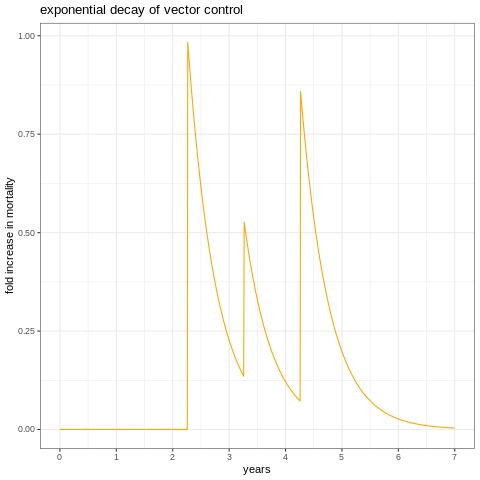

In [ ]:
%%R

# Vector control, impulse increase in vector mortality, then exponential decay
IRScampaigns=list("interv1"=c(t=2+30/120,a=1,k=2),"interv2"=c(t=3+30/120,a=0.4,k=2),"interv3"=c(t=4+30/120,a=0.8,k=2))

vc_exp_decay<-function(i,time,interv=IRScampaigns){

  if(i==0){
    result<-0
  }else{
    sapply(interv,
           function(x){
             x[2]*exp(-x[3]*pmax(0,time[i]-time[which(time==x[1])]))
           }) -> df
    df * (time[i]>sapply(interv,function(y)y[1])) -> df
    result<-sum(df)
  }
  return(result)
}

data.frame(time=time)%>%
  mutate(mu_vc=sapply(c(0:N),function(x)vc_exp_decay(x,time)))%>%
  ggplot()+
  geom_line(aes(x=time,y=mu_vc),color="orange")+
  scale_y_continuous(name="fold increase in mortality")+
  scale_x_continuous(name="years",breaks=c(0:7))+
  ggtitle("exponential decay of vector control")+
  theme_bw()

# VARYING THE EFFICACY RATE $a$

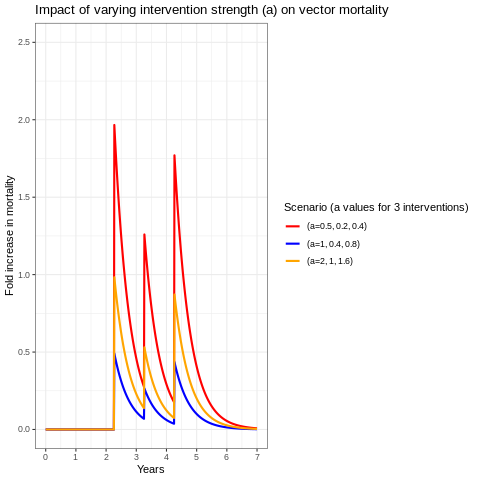

In [ ]:
%%R
library(ggplot2)
library(dplyr)
library(tidyr)

# Define time sequence
time <- seq(0, 7, length.out = 500)
N <- length(time) - 1

# Define interventions with different 'a' values
IRScampaigns_low <- list(
  "interv1" = c(t = 2.25, a = 0.5, k = 2),  # Low initial effect (50%)
  "interv2" = c(t = 3.25, a = 0.2, k = 2),  # Low initial effect (20%)
  "interv3" = c(t = 4.25, a = 0.4, k = 2)   # Low initial effect (40%)
)

IRScampaigns_medium <- list(
  "interv1" = c(t = 2.25, a = 1, k = 2),    # Medium effect (100%)
  "interv2" = c(t = 3.25, a = 0.4, k = 2),  # Medium effect (40%)
  "interv3" = c(t = 4.25, a = 0.8, k = 2)   # Medium effect (80%)
)

IRScampaigns_high <- list(
  "interv1" = c(t = 2.25, a = 2, k = 2),    # High effect (200%)
  "interv2" = c(t = 3.25, a = 1, k = 2),    # High effect (100%)
  "interv3" = c(t = 4.25, a = 1.6, k = 2)   # High effect (160%)
)

# Function to calculate mortality
vc_exp_decay <- function(i, time, interv) {
  if (i == 0) return(0)
  df <- sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - x[1]))
  })
  df * (time[i] > sapply(interv, function(y) y[1])) -> df
  sum(df)
}

# Calculate mortality for all scenarios
df_plot <- data.frame(time = time) %>%
  mutate(
    low = sapply(0:N, function(x) vc_exp_decay(x, time, IRScampaigns_low)),
    medium = sapply(0:N, function(x) vc_exp_decay(x, time, IRScampaigns_medium)),
    high = sapply(0:N, function(x) vc_exp_decay(x, time, IRScampaigns_high))
  ) %>%
  pivot_longer(cols = c(low, medium, high),
               names_to = "scenario",
               values_to = "mu_vc")

# Plot comparison with ACCURATE legend labels
# Only the scale_color_manual() section needs adjustment:
ggplot(df_plot, aes(x = time, y = mu_vc, color = scenario)) +
  geom_line(linewidth = 1) +
  scale_color_manual(
    values = c("low" = "blue", "medium" = "orange", "high" = "red"),
    labels = c(
      "(a=0.5, 0.2, 0.4)",
      "(a=1, 0.4, 0.8)",
      "(a=2, 1, 1.6)"
    )
  ) +
  scale_y_continuous(name = "Fold increase in mortality", limits = c(0, 2.5)) +
  scale_x_continuous(name = "Years", breaks = 0:7) +
  ggtitle("Impact of varying intervention strength (a) on vector mortality") +
  theme_bw() +
  labs(color = "Scenario (a values for 3 interventions)")
  #theme(legend.text = element_text(family = "mono"))  # Use monospaced font for alignment

# VARYING THE RATE OF DECAY $k$

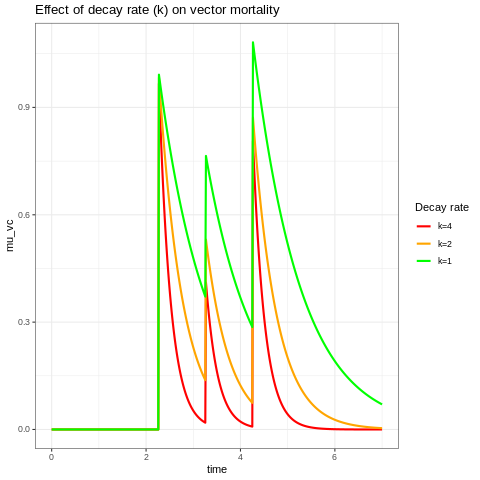

In [ ]:
%%R
# Define interventions with varying 'k'
IRScampaigns_fast <- list(
  "interv1" = c(t = 2.25, a = 1, k = 4),  # Fast decay
  "interv2" = c(t = 3.25, a = 0.4, k = 4),
  "interv3" = c(t = 4.25, a = 0.8, k = 4)
)

IRScampaigns_medium <- list(
  "interv1" = c(t = 2.25, a = 1, k = 2),  # Medium decay (original)
  "interv2" = c(t = 3.25, a = 0.4, k = 2),
  "interv3" = c(t = 4.25, a = 0.8, k = 2)
)

IRScampaigns_slow <- list(
  "interv1" = c(t = 2.25, a = 1, k = 1),  # Slow decay
  "interv2" = c(t = 3.25, a = 0.4, k = 1),
  "interv3" = c(t = 4.25, a = 0.8, k = 1)
)

# Calculate mortality for all decay rates
df_k <- data.frame(time = time) %>%
  mutate(
    fast = sapply(0:N, function(x) vc_exp_decay(x, time, IRScampaigns_fast)),
    medium = sapply(0:N, function(x) vc_exp_decay(x, time, IRScampaigns_medium)),
    slow = sapply(0:N, function(x) vc_exp_decay(x, time, IRScampaigns_slow))
  ) %>%
  tidyr::pivot_longer(cols = c(fast, medium, slow), names_to = "scenario", values_to = "mu_vc")

# Plot
ggplot(df_k, aes(x = time, y = mu_vc, color = scenario)) +
  geom_line(linewidth = 1) +
  scale_color_manual(
    values = c("fast" = "red", "medium" = "orange", "slow" = "green"),
    labels = c("k=4", "k=2", "k=1")
  ) +
  labs(title = "Effect of decay rate (k) on vector mortality", color = "Decay rate") +
  theme_bw()

The ramified model reads

\begin{align}
        dS_v & =  (f_{\text{period}}(t)\Lambda - \alpha S_v I_h- \mu_{\text{vc}}(t) S_v)dt + \sigma_1 S_v dB_1(t) \\
        dI_v & = (\alpha S_v I_h - \mu_{\text{vc}}(t) I_v)dt + \sigma_2 I_v dB_2(t) \\
        dS_h & =  (\lambda - \beta S_h I_v -\delta S_h + \gamma R_h)dt + \sigma_3 S_h dB_3(t) \\
        dI_h & = (\beta S_h I_v - (\delta + \rho + d)I_h)dt - f_{\text{treat}}(t)I_h dt + \sigma_4 I_h dB_4(t) \\
        dR_h & = (\rho I_h - (\delta + \gamma)R_h)dt +  f_{\text{treat}}(t)I_h dt + \sigma_5 R_h dB_5(t)
    \end{align}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Joining with `by = join_by(time)`
Joining with `by = join_by(time)`


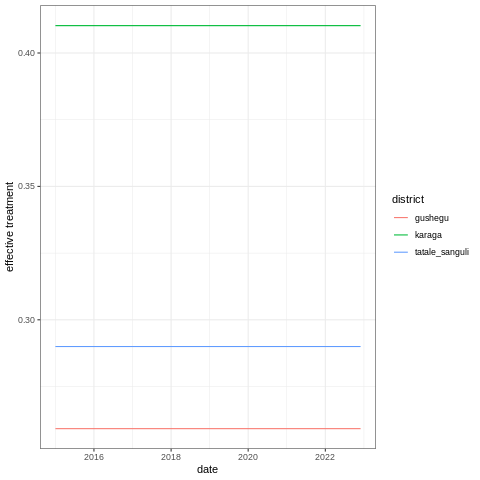

In [ ]:
%%R
##load and prepare prevalence and treatment coverage data
#read.csv("/content/drive/MyDrive/Peter_MSc_AIMS/GHA-NorthernRegionIRS-MAP_HBHI-2015_2022.csv")->map_data
read.csv("/content/drive/MyDrive/Peter_MSc_AIMS/data/GHA-NorthernRegionIRS-MAP_HBHI-2015_2022.csv")->map_data


map_data%>%
  filter(district=="gushegu")%>%
  mutate(date=as.Date(paste(YEAR,str_pad(MONTH, 2, pad = "0"),"01",sep ="-")))%>%
  select(district,date,prevalence_under5)->df_prev

df_prev%>%
  mutate(time=row_number()-1)%>%
  right_join(data.frame(time=seq(0,1-1/120,1/120)))%>%
  arrange(time)%>%
  fill(prevalence_under5)%>%
  select(time,prevalence_under5)->df_prev_filled

df_prev%>%
  mutate(time=seq(0,nrow(df_prev)-1)/12)->df_prev

map_data%>%
  filter(district=="gushegu")%>%
  mutate(date=as.Date(paste(YEAR,str_pad(MONTH, 2, pad = "0"),"01",sep ="-")))%>%
  select(district,date,proba_treatment_seekingALL_effective_treatment_under5)->df_treat

df_treat%>%
  mutate(time=(row_number()-1)/12)%>%
  right_join(data.frame(time=seq(0,7-1/120,1/120)))%>%
  arrange(time)%>%
  fill(proba_treatment_seekingALL_effective_treatment_under5)%>%
  select(time,proba_treatment_seekingALL_effective_treatment_under5)->df_treat_filled

##treatment access
f_treat<-function(i){
  df_treat_filled$proba_treatment_seekingALL_effective_treatment_under5[which(abs(df_treat_filled$time-time[i])<10^-5)]
}

map_data%>%
  mutate(date=as.Date(paste(YEAR,str_pad(MONTH, 2, pad = "0"),"01",sep ="-")))%>%
  select(district,date,proba_treatment_seekingDHIS2_effective_treatment_under5)%>%
  ggplot()+
  geom_line(aes(x=date,y=proba_treatment_seekingDHIS2_effective_treatment_under5,color=district))+
  scale_y_continuous(name="effective treatment")+
  theme_bw()



In [ ]:
%%R

#head(map_data)
#colnames(map_data)
dim(map_data)



[1] 288  10


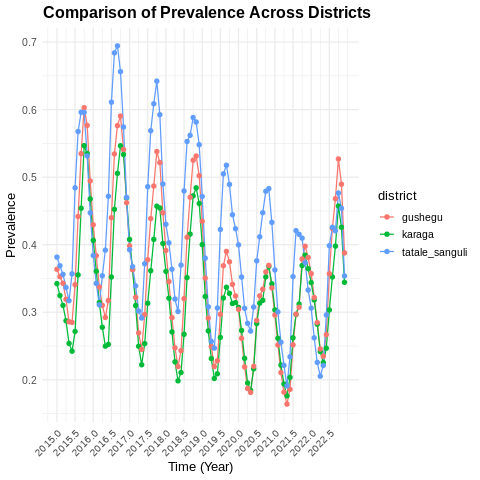

In [ ]:
%%R

library(ggplot2)
library(dplyr)

# Create a time_serial column (year + fractional month)
df_prev <- map_data %>%
  mutate(time_serial = YEAR + (MONTH - 1) / 12)

# Select districts to plot (exact names from df_prev)
districts_to_plot <- c("tatale_sanguli", "karaga", "gushegu")

# Filter and plot
plot_data <- df_prev %>%
  filter(district %in% districts_to_plot)

ggplot(plot_data, aes(x = time_serial, y = prevalence_under5,
                      color = district, group = district)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Comparison of Prevalence Across Districts",
    x = "Time (Year)",
    y = "Prevalence"
  ) +
  scale_x_continuous(
    breaks = unique(plot_data$time_serial)[seq(1, length(unique(plot_data$time_serial)), by = 6)]
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(size = 16, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )




In [ ]:
%%R
install.packages("ggpubr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘rbibutils’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘corrplot’, ‘car’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’

trying URL 'https://cran.rstudio.com/src/contrib/rbibutils_2.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/Deriv_4.2.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/microbenchmark_1.5.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/Rdpack_2.6.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/numDeriv_2016.8-1.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/doBy_4.7.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/SparseM_1.84-2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/MatrixModels_0.5-4.tar.gz'
t

**Effective treatment rate** in the cascade of care:

treatment seeking X testing X testing positive X receiving effective first-line treatment against malaria

Joining with `by = join_by(time)`


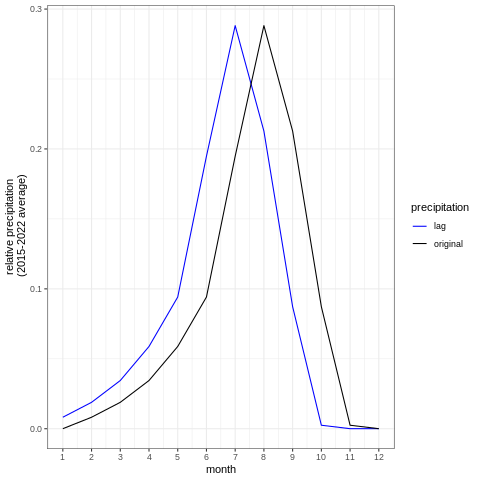

In [ ]:
%%R
## load and prepare rainfall data
#read.csv("/content/drive/MyDrive/Peter_MSc_AIMS/precipitation_northGhana_average_across_years.csv")->rain_data
read.csv("/content/drive/MyDrive/Peter_MSc_AIMS/data/precipitation_northGhana_average_across_years.csv")->rain_data


rain_data%>%
  filter(district=="gushegu"&month==1)%>%
  pull(relative_total_precipitation_mean_month)->precip_jan

rain_data%>%
  filter(district=="gushegu"&month<13)%>%
  mutate(relative_total_precipitation_mean_month_lag=lead(relative_total_precipitation_mean_month,default=precip_jan))%>%
  mutate(time=(month-1)/12)%>%
  right_join(data.frame(time=seq(0,1-1/120,1/120)))%>%
  arrange(time)%>%
  fill(relative_total_precipitation_mean_month_lag)%>%
  mutate(relative_total_precipitation_mean_month_lag=relative_total_precipitation_mean_month_lag/100)->df_period

##periodic force of infection
f_period<-function(i){
  df_period$relative_total_precipitation_mean_month_lag[which(abs(df_period$time-(time[i]%%1))<10^-5)]
}

rain_data%>%
  filter(district=="gushegu"&month<13)%>%
  select(district,month,relative_total_precipitation_mean_month)%>%
  rename(original=relative_total_precipitation_mean_month)%>%
  mutate(lag=lead(original,default=precip_jan))%>%
  pivot_longer(cols = -c(district,month))%>%
  ggplot()+
  geom_line(aes(x=month,y=value,color=name))+
  scale_x_continuous(breaks=c(1:12))+
  scale_color_manual(name="precipitation",values=c("blue","black"))+
  scale_y_continuous(name="relative precipitation\n (2015-2022 average)")+
  theme_bw()



### **Numerics of SDEs**

Given geometric Brownian motion

$dX_t = \mu X_t dt + \sigma X_t dB_t$


*  numerics with Euler-Maruyama  $X(t_{i+1}) = X(t_{i}) +  \mu X(t_{i})(t_{i+1}-t_{i}) + \sigma X(t_{i})\underbrace{(B(t_{i+1})-B(t_{i}))}_{{\cal N}(0,t_{i+1}-t_{i})}$

*  for time step $\Delta t=t_{i+1}-t_{i}$, strong convergence of order $\sqrt{\Delta t}$:
$\sup_t \mathbb{E}|X_t-X_t^{\Delta t}|\leq C \sqrt{\Delta t}$, but unstable for large $\Delta t$

* numerics with Milstein \begin{align*} X(t_{i+1})&= X(t_{i}) +  \mu X(t_{i})(t_{i+1}-t_{i}) + \sigma X(t_{i})(B(t_{i+1})-B(t_{i}))\\&\qquad+\tfrac{1}{2}\sigma^2 X(t_{i})[(B(t_{i+1})-B(t_{i}))^2-(t_{i+1}-t_{i})]
\end{align*}

* strong convergence of order $\Delta t$, stable for large $\Delta t$


In [ ]:
%%R
##with given parameters, let's have a look at R0 of the model without  control
R0=sqrt(Lambda*lambda*alpha*beta/((mu+sigma1^2/2)*(mu+sigma2^2/2)*(delta+sigma3^2/2)*(delta+rho+d+sigma4^2/2)))
print(paste0("R0: ",round(R0,2)))vector
print(paste0("Noise levels meet criteria: ",min(mu,delta)<0.5*max(sigma1^2,sigma2^2,sigma3^2,sigma4^2,sigma5^2)))


[1] "R0: 2.28"
[1] "Noise levels meet criteria: TRUE"


## Temperature: download average surface air temperature from ERA5, use shapefiles for Gushegu district to calculate average monthly temperature in the district, sf package in R



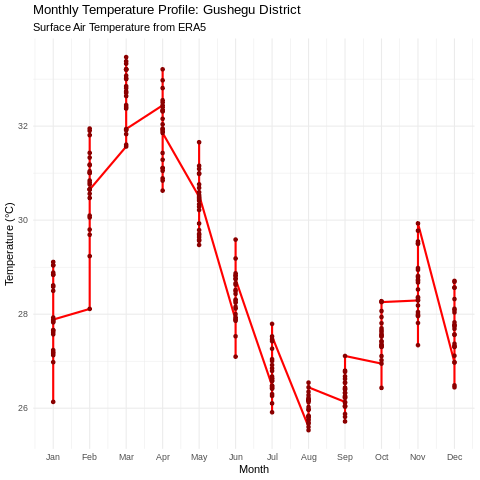

In [ ]:
%%R
## loading and preparing temperature data
#read.csv("/content/drive/MyDrive/Peter_MSc_AIMS/precipitation_northGhana_average_across_years.csv")->rain_data
TemData<- read.csv("/content/drive/MyDrive/Peter_MSc_AIMS/monthly_temperature_Gushiegu.csv")


library(ggplot2)

# Using temp_celsius from your TemData structure
ggplot(TemData, aes(x = month, y = temp_celsius)) +
  # Adds a line showing the temperature trend
  geom_line(color = "red", linewidth = 1) +
  # Adds individual points for each data entry
  geom_point(color = "darkred") +
  # Formats the x-axis to show month abbreviations
  scale_x_continuous(breaks = 1:12, labels = month.abb) +
  theme_minimal() +
  labs(
    title = "Monthly Temperature Profile: Gushegu District",
    subtitle = "Surface Air Temperature from ERA5",
    x = "Month",
    y = "Temperature (°C)"
  )

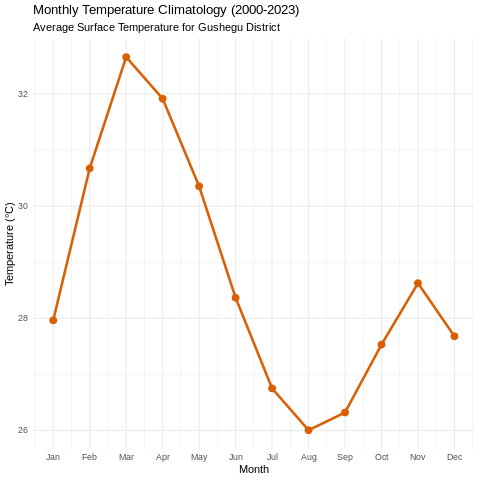

In [ ]:
%%R
library(ggplot2)
library(dplyr)

# 1. Group by month and calculate the average temperature across all years (2000-2023)
temp_summary <- TemData %>%
  group_by(month) %>%
  summarise(avg_temp = mean(temp_celsius, na.rm = TRUE))

# 2. Plot the resulting climatology
ggplot(temp_summary, aes(x = month, y = avg_temp)) +
  geom_line(color = "#d95f02", linewidth = 1.2) + # Distinct orange-red for temp
  geom_point(color = "#d95f02", size = 3) +
  scale_x_continuous(breaks = 1:12, labels = month.abb) +
  theme_minimal() +
  labs(
    title = "Monthly Temperature Climatology (2000-2023)",
    subtitle = "Average Surface Temperature for Gushegu District",
    x = "Month",
    y = "Temperature (°C)"
  )

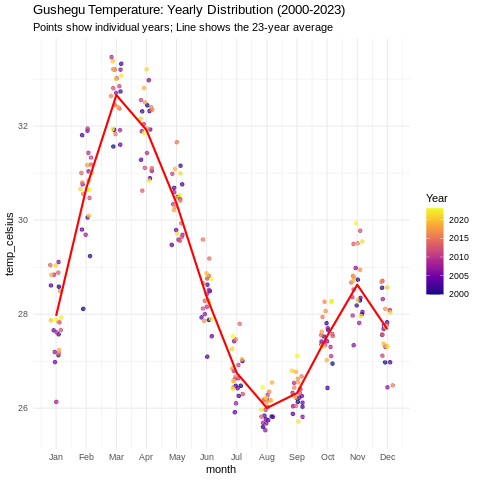

In [ ]:
%%R
library(ggplot2)

ggplot(TemData, aes(x = month, y = temp_celsius)) +
  # We color the points by 'year' to see if newer years (lighter color)
  # are higher than older years (darker color)
  geom_jitter(aes(color = year), width = 0.2, alpha = 0.7) +
  geom_line(stat = "summary", fun = "mean", color = "red", linewidth = 1) +
  scale_color_viridis_c(option = "plasma") +
  scale_x_continuous(breaks = 1:12, labels = month.abb) +
  theme_minimal() +
  labs(title = "Gushegu Temperature: Yearly Distribution (2000-2023)",
       subtitle = "Points show individual years; Line shows the 23-year average",
       color = "Year")

## **VECTORIAL CAPACITY**

###Mechanistic model:
$$
V_{CAP}(T,P)
=
\frac{m(P)\,a(T)^2\,p(T)^{n(T)}}{-\ln p(T)}
$$

##Components:
\begin{align*}
m(P) &= \max(0, 0.01 \cdot P) \quad \text{[Mosquito density]} \\
a(T) &= \max(0, 0.000202 \cdot T \cdot (T-12.3) \cdot \sqrt{40-T}) \quad \text{[Biting rate]} \\
P(T) &= \exp\left[-\frac{(T-25)^2}{2 \cdot 10^2}\right] \quad \text{ Mosquito [Survival rate]} \\
n(T) &= \frac{111}{T-16} \quad \text{[Incubation period]}
\end{align*}
Where $n$= extrinsic incubation period, $P$= precipitation and $T$= temperature.

# **New work**

[1] "T_vec length: 288"
[1] "P_vec length: 12"
[1] "V_CAP_norm length will be: 12"
[1] "V_CAP_monthly length: 12"
 [1] 0.000001 0.000002 0.000000 0.000000 0.000002 0.000030 0.000182 0.000782
 [9] 0.000094 0.000001 0.000000 0.000000
[1] "monthly_times length: 12"
[1] "V_CAP_norm length: 12"
[1] "vc_df rows: 120"


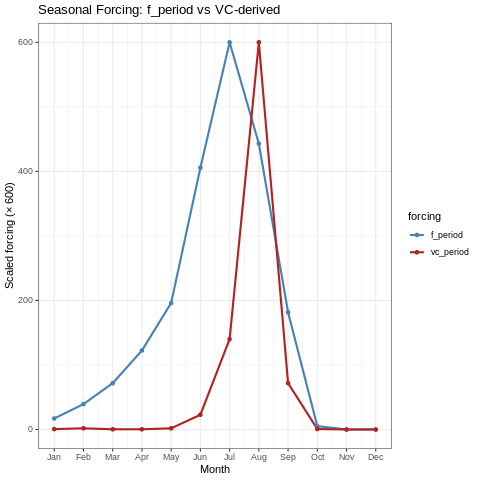

In [ ]:
%%R
## ── 1. Get 12 monthly precip values ──────────────────────────────────────────

P_vec_raw <- rain_data %>%
  filter(district == "gushegu" & month >= 1 & month <= 12) %>%
  group_by(month) %>%
  summarise(precip = mean(relative_total_precipitation_mean_month, na.rm = TRUE)) %>%
  arrange(month) %>%
  pull(precip)

P_vec <- c(P_vec_raw[2:12], P_vec_raw[1]) / 100

T_vec <- TemData$temp_celsius

# Diagnose lengths before anything else
print(paste("T_vec length:", length(T_vec)))
print(paste("P_vec length:", length(P_vec)))
print(paste("V_CAP_norm length will be:", min(length(T_vec), length(P_vec))))

# Safety: trim both to length 12
n <- min(length(T_vec), length(P_vec), 12)
T_vec <- T_vec[1:n]
P_vec <- P_vec[1:n]

## ── 2. VC component functions ────────────────────────────────────────────────

m_P <- function(P) pmax(0, 0.01 * P)
a_T <- function(T) pmax(0, 0.000202 * T * (T - 12.3) * sqrt(pmax(0, 40 - T)))
p_T <- function(T) exp(-(T - 25)^2 / (2 * 10^2))
n_T <- function(T) 111 / (T - 16)

## ── 3. Compute raw V_CAP monthly ─────────────────────────────────────────────

V_CAP_monthly <- numeric(n)
for (j in 1:n) {
  p  <- p_T(T_vec[j])
  lp <- -log(p)
  if (lp <= 0 || is.nan(lp) || is.infinite(lp)) {
    V_CAP_monthly[j] <- 0
  } else {
    V_CAP_monthly[j] <- m_P(P_vec[j]) * a_T(T_vec[j])^2 * p^n_T(T_vec[j]) / lp
  }
}

print(paste("V_CAP_monthly length:", length(V_CAP_monthly)))
print(round(V_CAP_monthly, 6))

## ── 4. Normalize ─────────────────────────────────────────────────────────────

V_CAP_norm <- V_CAP_monthly / max(V_CAP_monthly, na.rm = TRUE)

## ── 5. Step-interpolate onto 120-point local grid ────────────────────────────

monthly_times   <- seq(0, (n-1)/12, 1/12)   # exactly n points
fine_time_local <- seq(0, 1 - 1/120, 1/120) # exactly 120 points

print(paste("monthly_times length:", length(monthly_times)))
print(paste("V_CAP_norm length:", length(V_CAP_norm)))

vc_vals <- approx(
  x      = c(monthly_times, 1),
  y      = c(V_CAP_norm, V_CAP_norm[1]),
  xout   = fine_time_local,
  method = "constant",
  rule   = 2
)$y

vc_df <- data.frame(time = fine_time_local, vc = vc_vals)
print(paste("vc_df rows:", nrow(vc_df)))  # must be 120

## ── 6. vc_period drop-in replacement ─────────────────────────────────────────

vc_period <- function(i) {
  600 * vc_df$vc[which(abs(vc_df$time - (time[i] %% 1)) < 10^-5)]
}

## ── 7. Diagnostic plot ───────────────────────────────────────────────────────

diag_df <- data.frame(
  month     = 1:n,
  f_period  = 600 * (P_vec / max(P_vec)),
  vc_period = 600 * V_CAP_norm
) %>%
  pivot_longer(-month, names_to = "forcing", values_to = "value")

ggplot(diag_df, aes(x = month, y = value, color = forcing)) +
  geom_line(linewidth = 1) +
  geom_point() +
  scale_x_continuous(breaks = 1:12, labels = month.abb) +
  scale_color_manual(values = c("f_period" = "steelblue", "vc_period" = "firebrick")) +
  labs(title = "Seasonal Forcing: f_period vs VC-derived",
       x = "Month", y = "Scaled forcing (× 600)") +
  theme_bw()

 ## **VC-DRIVEN SIMULATION:  (integral scaling) + (linear interp)**

[1] "f_period annual mean: 0.5"
[1] "vc_period annual mean: 0.1481"
[1] "scaling factor applied: 3.3751"


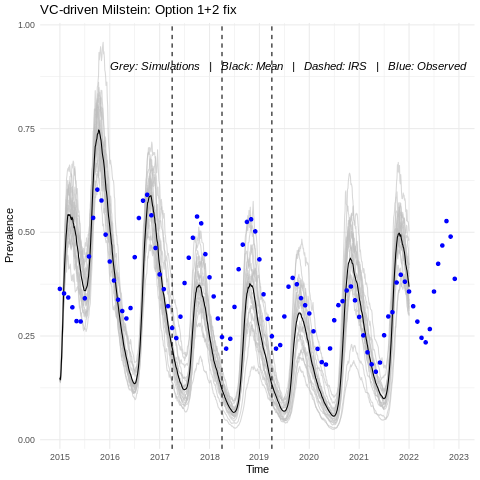

In [ ]:
%%R
## ══ VC-DRIVEN SIMULATION: Option 1 (integral scaling) + Option 2 (linear interp) ═══

## ── 1. Model parameters ───────────────────────────────────────────────────────

Lambda <- 1.0182*10^7
alpha  <- 1.3499*10^-3
mu     <- 9.125
lambda <- 5.9869*10^5
beta   <- 4.761*10^-9
delta  <- 0.00645
gamma  <- 0.20064
k      <- 3
d      <- 0.0336

sigma1 <- 0.32*2
sigma2 <- 0.23*2
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

n_reps <- 20

Sv0 <- 4.5*10^6;  Iv0 <- 4.7*10^3
Sh0 <- 4.4*10^7;  Ih0 <- 1.3144*10^4;  Rh0 <- 10000

## ── 2. Build T_vec and P_vec ──────────────────────────────────────────────────

T_vec <- TemData %>%
  group_by(month) %>%
  summarise(temp = mean(temp_celsius, na.rm = TRUE)) %>%
  arrange(month) %>%
  pull(temp)

P_vec_raw <- rain_data %>%
  filter(district == "gushegu" & month >= 1 & month <= 12) %>%
  group_by(month) %>%
  summarise(precip = mean(relative_total_precipitation_mean_month, na.rm = TRUE)) %>%
  arrange(month) %>%
  pull(precip)

P_vec <- c(P_vec_raw[2:12], P_vec_raw[1]) / 100

## ── 3. VC component functions ─────────────────────────────────────────────────

m_P <- function(P) pmax(0, 0.01 * P)
a_T <- function(T) pmax(0, 0.000202 * T * (T - 12.3) * sqrt(pmax(0, 40 - T)))
p_T <- function(T) exp(-(T - 25)^2 / (2 * 10^2))
n_T <- function(T) 111 / (T - 16)

## ── 4. Compute V_CAP monthly & normalize ─────────────────────────────────────

V_CAP_monthly <- numeric(12)
for (j in 1:12) {
  p  <- p_T(T_vec[j])
  lp <- -log(p)
  if (lp <= 0 || is.nan(lp) || is.infinite(lp)) {
    V_CAP_monthly[j] <- 0
  } else {
    V_CAP_monthly[j] <- m_P(P_vec[j]) * a_T(T_vec[j])^2 * p^n_T(T_vec[j]) / lp
  }
}

V_CAP_norm <- V_CAP_monthly / max(V_CAP_monthly, na.rm = TRUE)

## ── 5. OPTION 2: Linear interpolation onto 120-point grid ────────────────────

monthly_times   <- seq(0, 11/12, 1/12)
fine_time_local <- seq(0, 1 - 1/120, 1/120)

vc_vals <- approx(
  x      = c(monthly_times, 1),
  y      = c(V_CAP_norm, V_CAP_norm[1]),  # wrap Jan back at end
  xout    = fine_time_local,
  method = "linear",                       # OPTIONS 2: smooth the spike
  rule   = 2
)$y

vc_df <- data.frame(time = fine_time_local, vc = vc_vals)

## ── 6. OPTION 1: Match annual integral of f_period ───────────────────────────

f_integral  <- mean(600 * df_period$relative_total_precipitation_mean_month_lag)
vc_integral <- mean(vc_df$vc)
scaling_factor <- f_integral / vc_integral

print(paste("f_period annual mean:", round(f_integral, 4)))
print(paste("vc_period annual mean:", round(vc_integral, 4)))
print(paste("scaling factor applied:", round(scaling_factor, 4)))

## ── 7. vc_period with both fixes applied ─────────────────────────────────────

vc_period <- function(i) {
  scaling_factor * vc_df$vc[which(abs(vc_df$time - (time[i] %% 1)) < 10^-5)]
}

## ── 8. Diagnostic: compare f_period vs fixed vc_period shape ─────────────────


f_vals <- sapply(seq_along(fine_time_local), function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which.min(abs(df_period$time - fine_time_local[i]))
  ]
})

diag_df <- data.frame(
  time      = fine_time_local,
  f_period  = f_vals,
  vc_period = scaling_factor * vc_df$vc
) %>%
  pivot_longer(-time, names_to = "forcing", values_to = "value")

p_diag <- ggplot(diag_df, aes(x = time, y = value, color = forcing)) +
  geom_line(linewidth = 1) +
  scale_x_continuous(breaks = monthly_times, labels = month.abb) +  # fix: 12 breaks = 12 labels
  scale_color_manual(values = c("f_period" = "steelblue", "vc_period" = "firebrick")) +
  labs(title = "Forcing comparison after Option 1+2 fix",
       x = "Month", y = "Scaled forcing") +
  theme_bw()

print(p_diag)

## ── Milstein SDE ──────────────────────────────────────────────────────────────

results_vc <- list()
set.seed(123)

for (rep in 1:n_reps) {
  Sv <- numeric(length(time)); Iv <- numeric(length(time))
  Sh <- numeric(length(time)); Ih <- numeric(length(time))
  Rh <- numeric(length(time)); Nh <- numeric(length(time))

  Sv[1] <- Sv0; Iv[1] <- Iv0; Sh[1] <- Sh0
  Ih[1] <- Ih0; Rh[1] <- Rh0
  Nh[1] <- Sh0 + Ih0 + Rh0

  for (i in 1:N) {
    dB  <- rnorm(5, mean = 0, sd = sqrt(dt))
    dB2 <- dB^2 - dt

    Sv[i+1] <- Sv[i] + (vc_period(i)*Lambda - alpha*Sv[i]*Ih[i] - (mu + mu*vc_exp_decay(i,time=time,interv=IRScampaigns))*Sv[i])*dt + sigma1*Sv[i]*dB[1] + 0.5*sigma1^2*Sv[i]*dB2[1]
    Iv[i+1] <- Iv[i] + (alpha*Sv[i]*Ih[i]   - (mu + mu*vc_exp_decay(i,time=time,interv=IRScampaigns))*Iv[i])*dt + sigma2*Iv[i]*dB[2] + 0.5*sigma2^2*Iv[i]*dB2[2]
    Sh[i+1] <- Sh[i] + (lambda - beta*Sh[i]*Iv[i] - delta*Sh[i] + gamma*Rh[i])*dt + sigma3*Sh[i]*dB[3] + 0.5*sigma3^2*Sh[i]*dB2[3]
    Ih[i+1] <- Ih[i] + (beta*Sh[i]*Iv[i] - (delta+k+d)*Ih[i])*dt + sigma4*Ih[i]*dB[4] + 0.5*sigma4^2*Ih[i]*dB2[4]
    Rh[i+1] <- Rh[i] + (k*Ih[i] - (delta+gamma)*Rh[i])*dt + sigma5*Rh[i]*dB[5] + 0.5*sigma5^2*Rh[i]*dB2[5]
    Nh[i+1] <- Sh[i+1] + Ih[i+1] + Rh[i+1]
  }

  results_vc[[rep]] <- data.frame(
    time      = rep(time, 5),
    value     = c(Sv, Iv, Sh, Ih, Rh),
    variable  = factor(rep(c("S_v","I_v","S_h","I_h","R_h"), each=length(time))),
    replicate = rep(rep, length(time)*5)
  )
}

## ── Plot simulation ───────────────────────────────────────────────────────────

do.call(rbind, results_vc) %>%
  pivot_wider(id_cols=c("time","replicate"), names_from=variable, values_from=value) %>%
  mutate(N_h=S_h+I_h+R_h, prev_h=500*I_h/N_h) %>%
  group_by(time) %>%
  mutate(prev_h_mean=mean(prev_h)) -> df_vc

ggplot() +
  geom_line(data=df_vc, aes(x=time, y=prev_h, group=replicate), color="grey", alpha=0.6) +
  geom_line(data=df_vc, aes(x=time, y=prev_h_mean), color="black") +
  geom_vline(xintercept=c(IRScampaigns[[1]]["t"], IRScampaigns[[2]]["t"], IRScampaigns[[3]]["t"]),
             linetype="dashed", color="black") +
  geom_point(data=df_prev, aes(x=time, y=prevalence_under5), color="blue") +
  scale_x_continuous(labels=2015:2023, breaks=0:8) +
  labs(title="VC-driven Milstein: Option 1+2 fix", x="Time", y="Prevalence") +
  theme_minimal() +
  theme(legend.position="none") +
  annotate("text", x=1, y=0.9,
           label="Grey: Simulations   |   Black: Mean   |   Dashed: IRS   |   Blue: Observed",
           size=4, hjust=0, fontface="italic")

## X

#  **DECOMPOSED VC: each component → its biological SDE term**

[1] "Monthly m(P) normalized:"
 [1] 0.099 0.227 0.414 0.706 1.130 2.338 3.458 2.553 1.047 0.030 0.000 0.000
[1] "Monthly a(T) normalized:"
 [1] 0.973 1.102 1.154 1.140 1.090 0.996 0.901 0.854 0.874 0.948 1.010 0.957
[1] "Monthly mu modifier normalized:"
 [1] 0.949 1.067 1.218 1.154 1.048 0.961 0.922 0.913 0.916 0.938 0.970 0.942


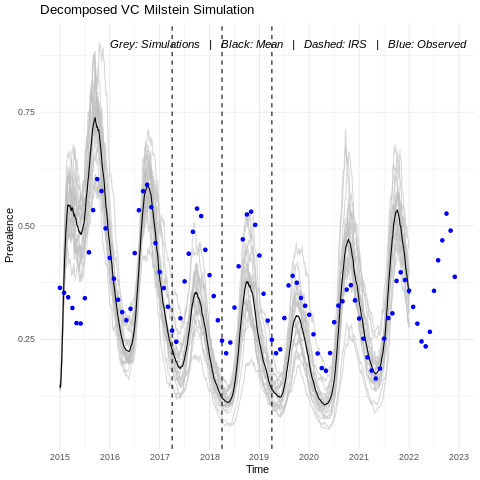

In [ ]:
%%R
## ══ DECOMPOSED VC: each component → its biological SDE term ══════════════════

## ── 1. Model parameters ───────────────────────────────────────────────────────

Lambda <- 1.0182*10^7
alpha  <- 1.3499*10^-3
mu     <- 9.125
lambda <- 5.9869*10^5
beta   <- 4.761*10^-9
delta  <- 0.00645
gamma  <- 0.20064
k      <- 3
d      <- 0.0336

sigma1 <- 0.32*2;  sigma2 <- 0.23*2
sigma3 <- 0.15;    sigma4 <- 0.21;  sigma5 <- 0.32

n_reps <- 20

Sv0 <- 4.5*10^6;  Iv0 <- 4.7*10^3
Sh0 <- 4.4*10^7;  Ih0 <- 1.3144*10^4;  Rh0 <- 10000

## ── 2. Build T_vec and P_vec ──────────────────────────────────────────────────

T_vec <- TemData %>%
  group_by(month) %>%
  summarise(temp = mean(temp_celsius, na.rm = TRUE)) %>%
  arrange(month) %>%
  pull(temp)

P_vec_raw <- rain_data %>%
  filter(district == "gushegu" & month >= 1 & month <= 12) %>%
  group_by(month) %>%
  summarise(precip = mean(relative_total_precipitation_mean_month, na.rm=TRUE)) %>%
  arrange(month) %>%
  pull(precip)

P_vec <- c(P_vec_raw[2:12], P_vec_raw[1]) / 100

## ── 3. VC component functions ─────────────────────────────────────────────────

m_P <- function(P) pmax(0, 0.01 * P)
a_T <- function(T) pmax(0, 0.000202 * T * (T - 12.3) * sqrt(pmax(0, 40 - T)))
p_T <- function(T) exp(-(T - 25)^2 / (2 * 10^2))
n_T <- function(T) 111 / (T - 16)

## ── 4. Build monthly seasonal modifiers for each SDE term ────────────────────

# month index helper: maps simulation time → month index 1–12
month_idx <- function(i) {
  t_mod <- time[i] %% 1
  which.min(abs(seq(0, 11/12, 1/12) - t_mod))
}

# (a) Recruitment modifier: only m(P) — normalized to mean 1
m_monthly  <- sapply(1:12, function(j) m_P(P_vec[j]))
m_norm     <- m_monthly / mean(m_monthly)   # mean=1 so Lambda unchanged on average

# (b) Biting rate modifier: a(T) — normalized to mean 1
a_monthly  <- sapply(1:12, function(j) a_T(T_vec[j]))
a_norm     <- a_monthly / mean(a_monthly)

# (c) Mortality modifier: 1/p(T) — higher temp deviation = higher mortality
p_monthly  <- sapply(1:12, function(j) p_T(T_vec[j]))
mu_mod     <- 1 / p_monthly                 # inverse survival = mortality scaling
mu_norm    <- mu_mod / mean(mu_mod)         # normalized to mean 1

print("Monthly m(P) normalized:"); print(round(m_norm, 3))
print("Monthly a(T) normalized:"); print(round(a_norm, 3))
print("Monthly mu modifier normalized:"); print(round(mu_norm, 3))

## ── 5. Interpolate all modifiers onto fine grid ───────────────────────────────

monthly_times   <- seq(0, 11/12, 1/12)
fine_time_local <- seq(0, 1 - 1/120, 1/120)

interp_fine <- function(vals) {
  approx(
    x      = c(monthly_times, 1),
    y      = c(vals, vals[1]),
    xout   = fine_time_local,
    method = "linear",
    rule   = 2
  )$y
}

m_fine  <- interp_fine(m_norm)
a_fine  <- interp_fine(a_norm)
mu_fine <- interp_fine(mu_norm)

## ── 6. Seasonal parameter functions ──────────────────────────────────────────

# Scale f_period mean to match original (same annual budget as f_period)
f_mean <- mean(600 * df_period$relative_total_precipitation_mean_month_lag)

f_decomp <- function(i) {
  f_mean * m_fine[which(abs(fine_time_local - (time[i] %% 1)) < 10^-5)]
}

alpha_decomp <- function(i) {
  alpha * a_fine[which(abs(fine_time_local - (time[i] %% 1)) < 10^-5)]
}

mu_decomp <- function(i) {
  mu * mu_fine[which(abs(fine_time_local - (time[i] %% 1)) < 10^-5)]
}

## ── 7. Diagnostic plot: all three modifiers ───────────────────────────────────

diag_decomp <- data.frame(
  time        = fine_time_local,
  recruitment = f_mean * m_fine,
  biting_rate = a_fine,        # relative modifier
  mortality   = mu_fine        # relative modifier
) %>% pivot_longer(-time, names_to="component", values_to="value")

ggplot(diag_decomp, aes(x=time, y=value, color=component)) +
  geom_line(linewidth=1) +
  scale_x_continuous(breaks=seq(0,11/12,1/12), labels=month.abb) +
  scale_color_manual(values=c(
    "recruitment" = "steelblue",
    "biting_rate" = "firebrick",
    "mortality"   = "darkgreen"
  )) +
  labs(title="Decomposed VC: seasonal modifiers per SDE term",
       x="Month", y="Relative modifier (mean = 1)") +
  theme_bw()

## ── 8. Milstein SDE with decomposed VC ───────────────────────────────────────

results_decomp <- list()
set.seed(123)

for (rep in 1:n_reps) {
  Sv <- numeric(length(time)); Iv <- numeric(length(time))
  Sh <- numeric(length(time)); Ih <- numeric(length(time))
  Rh <- numeric(length(time)); Nh <- numeric(length(time))

  Sv[1] <- Sv0; Iv[1] <- Iv0; Sh[1] <- Sh0
  Ih[1] <- Ih0; Rh[1] <- Rh0
  Nh[1] <- Sh0 + Ih0 + Rh0

  for (i in 1:N) {
    dB  <- rnorm(5, mean=0, sd=sqrt(dt))
    dB2 <- dB^2 - dt

    # Each VC component goes to its biological home
    f_t     <- f_decomp(i)                                          # m(P)   → recruitment
    alpha_t <- alpha_decomp(i)                                      # a(T)   → biting rate
    mu_t    <- mu_decomp(i) + mu*vc_exp_decay(i,time=time,         # 1/p(T) → mortality
                                               interv=IRScampaigns)

    Sv[i+1] <- Sv[i] + (f_t*Lambda - alpha_t*Sv[i]*Ih[i] - mu_t*Sv[i])*dt + sigma1*Sv[i]*dB[1] + 0.5*sigma1^2*Sv[i]*dB2[1]
    Iv[i+1] <- Iv[i] + (alpha_t*Sv[i]*Ih[i] - mu_t*Iv[i])*dt + sigma2*Iv[i]*dB[2] + 0.5*sigma2^2*Iv[i]*dB2[2]
    Sh[i+1] <- Sh[i] + (lambda - beta*Sh[i]*Iv[i] - delta*Sh[i] + gamma*Rh[i])*dt + sigma3*Sh[i]*dB[3] + 0.5*sigma3^2*Sh[i]*dB2[3]
    Ih[i+1] <- Ih[i] + (beta*Sh[i]*Iv[i] - (delta+k+d)*Ih[i])*dt + sigma4*Ih[i]*dB[4] + 0.5*sigma4^2*Ih[i]*dB2[4]
    Rh[i+1] <- Rh[i] + (k*Ih[i] - (delta+gamma)*Rh[i])*dt + sigma5*Rh[i]*dB[5] + 0.5*sigma5^2*Rh[i]*dB2[5]
    Nh[i+1] <- Sh[i+1] + Ih[i+1] + Rh[i+1]
  }

  results_decomp[[rep]] <- data.frame(
    time      = rep(time, 5),
    value     = c(Sv, Iv, Sh, Ih, Rh),
    variable  = factor(rep(c("S_v","I_v","S_h","I_h","R_h"), each=length(time))),
    replicate = rep(rep, length(time)*5)
  )
}

## ── 9. Plot ───────────────────────────────────────────────────────────────────

do.call(rbind, results_decomp) %>%
  pivot_wider(id_cols=c("time","replicate"), names_from=variable, values_from=value) %>%
  mutate(N_h=S_h+I_h+R_h, prev_h=500*I_h/N_h) %>%
  group_by(time) %>%
  mutate(prev_h_mean=mean(prev_h)) -> df_decomp

ggplot() +
  geom_line(data=df_decomp, aes(x=time, y=prev_h, group=replicate), color="grey", alpha=0.6) +
  geom_line(data=df_decomp, aes(x=time, y=prev_h_mean), color="black") +
  geom_vline(xintercept=c(IRScampaigns[[1]]["t"], IRScampaigns[[2]]["t"], IRScampaigns[[3]]["t"]),
             linetype="dashed", color="black") +
  geom_point(data=df_prev, aes(x=time, y=prevalence_under5), color="blue") +
  scale_x_continuous(labels=2015:2023, breaks=0:8) +
  labs(title="Decomposed VC Milstein Simulation", x="Time", y="Prevalence") +
  theme_minimal() +
  theme(legend.position="none") +
  annotate("text", x=1, y=0.9,
           label="Grey: Simulations   |   Black: Mean   |   Dashed: IRS   |   Blue: Observed",
           size=4, hjust=0, fontface="italic")

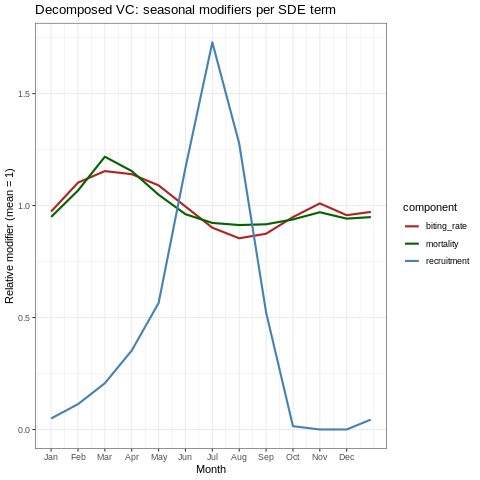

In [ ]:
%%R

ggplot(diag_decomp, aes(x=time, y=value, color=component)) +
  geom_line(linewidth=1) +
  scale_x_continuous(breaks=seq(0,11/12,1/12), labels=month.abb) +
  scale_color_manual(values=c(
    "recruitment" = "steelblue",
    "biting_rate" = "firebrick",
    "mortality"   = "darkgreen"
  )) +
  labs(title="Decomposed VC: seasonal modifiers per SDE term",
       x="Month", y="Relative modifier (mean = 1)") +
  theme_bw()

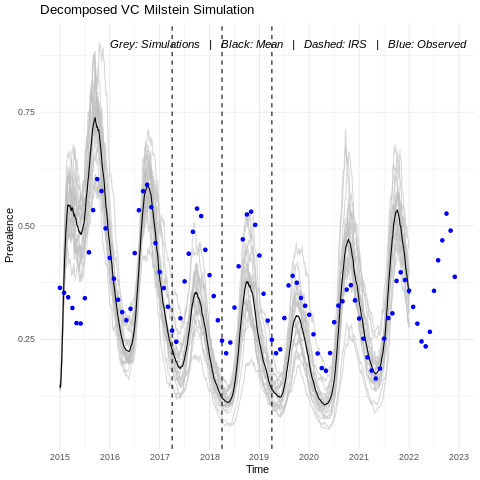

In [ ]:
%%R
ggplot() +
  geom_line(data=df_decomp, aes(x=time, y=prev_h, group=replicate), color="grey", alpha=0.6) +
  geom_line(data=df_decomp, aes(x=time, y=prev_h_mean), color="black") +
  geom_vline(xintercept=c(IRScampaigns[[1]]["t"], IRScampaigns[[2]]["t"], IRScampaigns[[3]]["t"]),
             linetype="dashed", color="black") +
  geom_point(data=df_prev, aes(x=time, y=prevalence_under5), color="blue") +
  scale_x_continuous(labels=2015:2023, breaks=0:8) +
  labs(title="Decomposed VC Milstein Simulation", x="Time", y="Prevalence") +
  theme_minimal() +
  theme(legend.position="none") +
  annotate("text", x=1, y=0.9,
           label="Grey: Simulations   |   Black: Mean   |   Dashed: IRS   |   Blue: Observed",
           size=4, hjust=0, fontface="italic")

In [ ]:
%%R
TemData$year%>%unique()

 [1] 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014
[16] 2015 2016 2017 2018 2019 2020 2021 2022 2023


# **Driving by Rainfall alone (f_period)**

[1] 2.897112
[1] TRUE


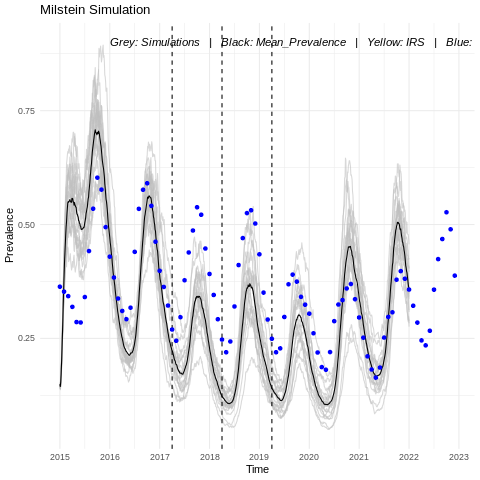

In [ ]:
%%R
##periodic force of infection, with scaling and old vector control function...
## for inference of alpha or beta, focus on time window c(1,IRScampaigns[[1]]["t"])=c(1,2.25)
f_period<-function(i){
  ##factor 600
  600*df_period$relative_total_precipitation_mean_month_lag[which(abs(df_period$time-(time[i]%%1))<10^-5)]
}

# Set model parameters, yearly rates
Lambda <- 1.0182*10^7
alpha <- 1.3499*10^-3
mu <- 9.125

lambda <- 5.9869*10^5
beta <- 4.761*10^-9
delta <- 0.00645
gamma <- 0.20064
k <- 3
d <- 0.0336

sigma1 <- 0.32*2
sigma2 <- 0.23*2
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

R0=sqrt(Lambda*lambda*alpha*beta/((mu+sigma1^2/2)*(mu+sigma2^2/2)*(delta+sigma3^2/2)*(delta+k+d+sigma4^2/2)))
print(R0)
print(min(mu,delta)<0.5*max(sigma1^2,sigma2^2,sigma3^2,sigma4^2,sigma5^2))


# Vector control
epsilon<- 1.7 #fold increase in mortality at beginning of campaign
kappa<-3 #decay rate
tt<-c(4) #starting months vector control campaign
mu_vc<-function(i){
  if(i<=which(time==tt)){
    mu
  }else{
    mu+mu*(epsilon-1)*exp(-kappa*(time[i]-time[which(time==tt)]))-(exp(-kappa*time[which(time==tt)])-exp(-kappa*time[which(abs(time-tt-7/12)<10^-5)]))
  }
}##exponential decay of vector control

n_reps <- 20    # number of stochastic replicates

# Initial conditions
Sv0 <- 4.5*10^6
Iv0 <- 4.7*10^3
Sh0 <- 4.4*10^7
Ih0 <- 1.3144*10^4
Rh0 <- 10000

# Store results in a list
results <- list()

set.seed(123)
for (rep in 1:n_reps) {
  # Initialize vectors
  Sv <- numeric(length(time))
  Iv <- numeric(length(time))
  Sh <- numeric(length(time))
  Ih <- numeric(length(time))
  Rh <- numeric(length(time))
  Nh <- numeric(length(time))

  Sv[1] <- Sv0
  Iv[1] <- Iv0
  Sh[1] <- Sh0
  Ih[1] <- Ih0
  Rh[1] <- Rh0
  Nh[1] <- Sh[1] + Ih[1] + Rh[1]

  # Milstein simulation
  for (i in 1:N) {
    dB <- rnorm(5, mean = 0, sd = sqrt(dt))  # Brownian increments
    dB2 <- dB^2 - dt  # Milstein correction term

    Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] -(mu+mu*vc_exp_decay(i,time=time,interv=IRScampaigns)) * Sv[i]) * dt + sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]
    Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - (mu+mu*vc_exp_decay(i,time=time,interv=IRScampaigns)) * Iv[i]) * dt + sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]
    Sh[i + 1] <- Sh[i] + (lambda -  beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt + sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]
    Ih[i + 1] <- Ih[i] + ( beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt + sigma4 * Ih[i] * dB[4]+ 0.5 * sigma4^2 * Ih[i] * dB2[4]
    Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt + sigma5 * Rh[i] * dB[5]+ 0.5 * sigma5^2 * Rh[i] * dB2[5]
    Nh[i+1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
  }

  # Store in long format for ggplot
  df <- data.frame(
    time = rep(time, 5),
    value = c(Sv, Iv, Sh, Ih, Rh),
    variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
    replicate = rep(rep, length(time) * 5)
  )

  results[[rep]] <- df
}

# Combine all results into one data frame
all_data <- do.call(rbind, results)

all_data%>%
  pivot_wider(id_cols=c("time","replicate"),names_from = variable,values_from = value)%>%
  mutate(N_h=S_h+I_h+R_h,
         prev_h=500*I_h/N_h)%>%
  group_by(time)%>%
  mutate(I_h_mean=mean(I_h),
         prev_h_mean=mean(prev_h))->df

ggplot() +
  geom_line(data = df, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.6) +
  geom_line(data = df, aes(x = time, y = prev_h_mean), color = "black") +
  geom_vline(xintercept = c(IRScampaigns[[1]]["t"], IRScampaigns[[2]]["t"], IRScampaigns[[3]]["t"]),
             linetype = "dashed", color = "black") +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Milstein Simulation", x = "Time", y = "Prevalence") +
  theme_minimal() +
  theme(legend.position = "none") +
  annotate("text", x = 1, y = 0.9, label = "Grey: Simulations   |   Black: Mean_Prevalence   |   Yellow: IRS   |   Blue: Observed",
           size = 4, hjust = 0, fontface = "italic")

Three seasonal forcing formulations were compared: a precipitation-based function $f_{\text{period}}$, a composite vectorial capacity function $V_{CAP}$, and a biologically decomposed $V_{CAP}$ where each component was assigned to its corresponding epidemiological term in the SDE.

The composite $V_{CAP}$ was integrated into the model using two calibration steps. First, the annual recruitment budget was matched by scaling $V_{CAP}$ such that its time-averaged value over one seasonal cycle equalled that of $f_{\text{period}}$:

$$
\tilde{V}_{CAP}(t) =
\frac{\displaystyle \frac{1}{T}\int_0^T f_{\text{period}}(t)\,dt}
{\displaystyle \frac{1}{T}\int_0^T V_{CAP\_norm}(t)\,dt}
\times V_{CAP\_norm}(t)
$$
ensuring dynamical consistency in the mean mosquito recruitment rate.

Second, linear interpolation was applied when mapping the monthly $V_{CAP}$ values onto the fine simulation time grid:

$$
V_{CAP}(t)
=
V_{CAP}(t_j)
+
\frac{V_{CAP}(t_{j+1}) - V_{CAP}(t_j)}
{t_{j+1} - t_j}
(t - t_j),
\qquad
t \in [t_j, t_{j+1}]
$$

This replaced step-wise interpolation, which broadened the seasonal forcing window and prevented artificial post-intervention collapse of the vector population.

In the Gushegu climate, temperature varies narrowly between $26^\circ\text{C}$–$33^\circ\text{C}$ — well within the optimal range for Anopheles transmission. Evaluating the biting rate
$$
a(T) =
\max \left(
0,\;
0.000202 \cdot T (T - 12.3)\sqrt{40 - T}
\right)
$$

and the survival probability over the extrinsic incubation period
$$
p(T)^{n(T)} =
\exp\left[
-\frac{(T-25)^2}{2 \times 10^2}
\right]^{\frac{111}{T-16}}
$$
	​


across the observed monthly temperature range yields values that are nearly constant throughout the year, rendering both terms thermally insensitive in this climate zone.

Consequently, all three formulations converge on precipitation as the dominant seasonal driver, with the decomposed model reducing approximately to
$$
\frac{dS_v}{dt}
\approx
\tilde{V}_{CAP}(t)\Lambda
-
\alpha S_v I_h
-
\mu S_v
$$


This finding is consistent with the ecological literature on Sahelian malaria transmission, where rainfall seasonality is the primary determinant of mosquito population dynamics.

The composite $V_{CAP}$ formulation with mean-integral scaling and linear temporal interpolation was selected as the preferred forcing function, as it produced the closest agreement with observed prevalence data across the full study period (2015–2023), retained the biological structure of vectorial capacity theory, and remained computationally tractable for subsequent parameter estimation.

The biologically decomposed formulation, while more mechanistically explicit, yielded near-identical simulation dynamics due to the thermal insensitivity of $a(T)$ and $p(T)^{n(T)}$ in this climate zone, confirming that
$$
V_{CAP}(T,P)
=
\frac{m(P)\,a(T)^2\,p(T)^{n(T)}}{-\ln p(T)}
$$
	​
$$
V_{CAP}(T,P)
\approx
c \cdot m(P)
=
c \cdot 0.01 P
$$
where $c$ is a near-constant scaling factor, confirming precipitation $P$ as the dominant seasonal driver of malaria transmission in the Gushegu District.

# Simulation from 2014 to 2021

[1] 3.452075
[1] TRUE


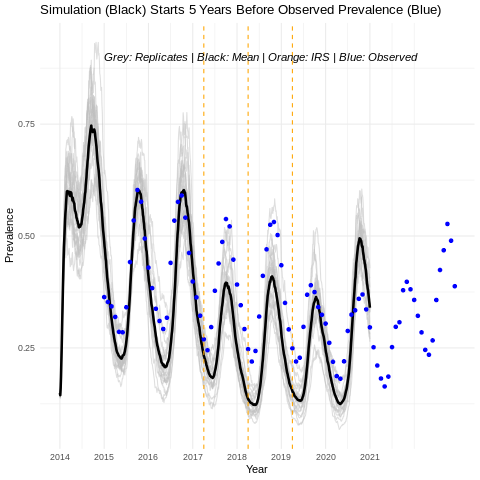

In [ ]:
%%R
## Periodic force of infection with precipitation (unchanged)
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

## Set parameters
Lambda <- 1.0182e7
#alpha <- 1.3499e-3
alpha<-0.0019166
mu <- 9.125

lambda <- 5.9869e5
beta <- 4.761e-9
delta <- 0.00645
gamma <- 0.20064
k <- 3
d <- 0.0336

sigma1 <- 0.32 * 2
sigma2 <- 0.23 * 2
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

## Basic reproduction number
R0 <- sqrt(Lambda * lambda * alpha * beta /
  ((mu + sigma1^2 / 2) * (mu + sigma2^2 / 2) *
   (delta + sigma3^2 / 2) * (delta + k + d + sigma4^2 / 2)))
print(R0)
print(min(mu, delta) < 0.5 * max(sigma1^2, sigma2^2, sigma3^2, sigma4^2, sigma5^2))

## Extend time: simulate from 2010 to 2023 (13 years)
TT <- 7
dt <- 1 / 120
N <- TT / dt
time <- round(seq(0, TT, by = dt), 5)

## Shift IRS campaigns forward: first one now starts in year 2017.25 (time = 7.25)
IRScampaigns <- list(
  "interv1" = c(t = 3.25, a = 1,   k = 2),  # 2017.25
  "interv2" = c(t = 4.25, a = 0.4, k = 2),  # 2018.25
  "interv3" = c(t = 5.25, a = 0.8, k = 2)   # 2019.25
)

## Exponential decay of vector control
vc_exp_decay <- function(i, time, interv = IRScampaigns) {
  if (i == 0) return(0)

  sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  }) -> df

  df * (time[i] > sapply(interv, function(y) y[1])) -> df
  sum(df)
}

## Initial conditions
Sv0 <- 4.5e6
Iv0 <- 4.7e3
Sh0 <- 4.4e7
Ih0 <- 1.3144e4
Rh0 <- 1e4

n_reps <- 20
results <- list()

set.seed(123)
for (rep in 1:n_reps) {
  Sv <- numeric(length(time))
  Iv <- numeric(length(time))
  Sh <- numeric(length(time))
  Ih <- numeric(length(time))
  Rh <- numeric(length(time))
  Nh <- numeric(length(time))

  Sv[1] <- Sv0
  Iv[1] <- Iv0
  Sh[1] <- Sh0
  Ih[1] <- Ih0
  Rh[1] <- Rh0
  Nh[1] <- Sh[1] + Ih[1] + Rh[1]

  for (i in 1:N) {
    dB <- rnorm(5, mean = 0, sd = sqrt(dt))
    dB2 <- dB^2 - dt

    mu_vc_i <- mu + mu * vc_exp_decay(i, time)

    Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
      sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

    Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
      sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

    Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
      sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

    Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
      sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

    Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
      sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

    Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
  }

  df <- data.frame(
    time = rep(time, 5),
    value = c(Sv, Iv, Sh, Ih, Rh),
    variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
    replicate = rep(rep, length(time) * 5)
  )

  results[[rep]] <- df
}

## Combine results and calculate prevalence
all_data <- do.call(rbind, results)

df <- all_data %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h) %>%
  group_by(time) %>%
  mutate(prev_h_mean = mean(prev_h))

## Plot with observed data starting from 2015
# Shift observed data to start from 2015 (time = 5)
df_prev_shifted <- df_prev %>% mutate(time = time + 1)

# Final plot: simulated prevalence from 2010, observed prevalence from 2015
ggplot() +
  geom_line(data = df, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:7, labels = 2014:2021) +
  scale_y_continuous(name = "Prevalence") +
  labs(title = "Simulation (Black) Starts 5 Years Before Observed Prevalence (Blue)") +
  theme_minimal() +
  annotate("text", x = 1, y = 0.9,
           label = "Grey: Replicates | Black: Mean | Orange: IRS | Blue: Observed",
           size = 4, hjust = 0, fontface = "italic")


# EFFICACY (a1=0.38163, a2=0.7054, a3=1.2221)



[1] 3.452075
[1] TRUE


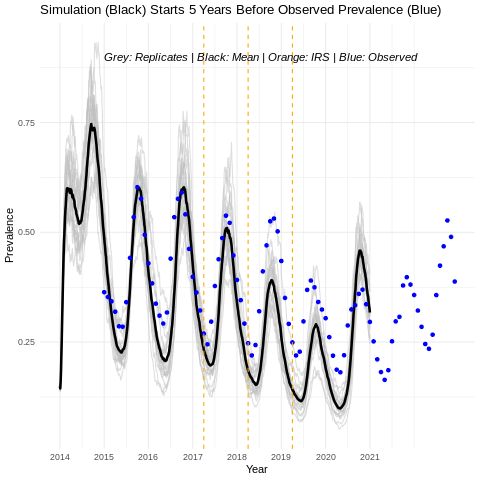

In [ ]:
%%R

## Periodic force of infection with precipitation (unchanged)
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

## Set parameters
Lambda <- 1.0182e7
#alpha <- 1.3499e-3
alpha<-0.0019166
mu <- 9.125

lambda <- 5.9869e5
beta <- 4.761e-9
delta <- 0.00645
gamma <- 0.20064
k <- 3
d <- 0.0336

sigma1 <- 0.32 * 2
sigma2 <- 0.23 * 2
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

## Basic reproduction number
R0 <- sqrt(Lambda * lambda * alpha * beta /
  ((mu + sigma1^2 / 2) * (mu + sigma2^2 / 2) *
   (delta + sigma3^2 / 2) * (delta + k + d + sigma4^2 / 2)))
print(R0)
print(min(mu, delta) < 0.5 * max(sigma1^2, sigma2^2, sigma3^2, sigma4^2, sigma5^2))

## Extend time: simulate from 2010 to 2023 (13 years)
TT <- 7
dt <- 1 / 120
N <- TT / dt
time <- round(seq(0, TT, by = dt), 5)

## Shift IRS campaigns forward: first one now starts in year 2017.25 (time = 7.25)
IRScampaigns <- list(
  "interv1" = c(t = 3.25, a = 0.3816,   k = 2),  # 2017.25
  "interv2" = c(t = 4.25, a = 0.7054, k = 2),  # 2018.25
  "interv3" = c(t = 5.25, a = 1.2221, k = 2)   # 2019.25
)

## Exponential decay of vector control
vc_exp_decay <- function(i, time, interv = IRScampaigns) {
  if (i == 0) return(0)

  sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  }) -> df

  df * (time[i] > sapply(interv, function(y) y[1])) -> df
  sum(df)
}

## Initial conditions
Sv0 <- 4.5e6
Iv0 <- 4.7e3
Sh0 <- 4.4e7
Ih0 <- 1.3144e4
Rh0 <- 1e4

n_reps <- 20
results <- list()

set.seed(123)
for (rep in 1:n_reps) {
  Sv <- numeric(length(time))
  Iv <- numeric(length(time))
  Sh <- numeric(length(time))
  Ih <- numeric(length(time))
  Rh <- numeric(length(time))
  Nh <- numeric(length(time))

  Sv[1] <- Sv0
  Iv[1] <- Iv0
  Sh[1] <- Sh0
  Ih[1] <- Ih0
  Rh[1] <- Rh0
  Nh[1] <- Sh[1] + Ih[1] + Rh[1]

  for (i in 1:N) {
    dB <- rnorm(5, mean = 0, sd = sqrt(dt))
    dB2 <- dB^2 - dt

    mu_vc_i <- mu + mu * vc_exp_decay(i, time)

    Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
      sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

    Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
      sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

    Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
      sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

    Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
      sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

    Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
      sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

    Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
  }

  df <- data.frame(
    time = rep(time, 5),
    value = c(Sv, Iv, Sh, Ih, Rh),
    variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
    replicate = rep(rep, length(time) * 5)
  )

  results[[rep]] <- df
}

## Combine results and calculate prevalence
all_data <- do.call(rbind, results)

df <- all_data %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h) %>%
  group_by(time) %>%
  mutate(prev_h_mean = mean(prev_h))

## Plot with observed data starting from 2015
# Shift observed data to start from 2015 (time = 5)
df_prev_shifted <- df_prev %>% mutate(time = time + 1)

# Final plot: simulated prevalence from 2010, observed prevalence from 2015
ggplot() +
  geom_line(data = df, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:7, labels = 2014:2021) +
  scale_y_continuous(name = "Prevalence") +
  labs(title = "Simulation (Black) Starts 5 Years Before Observed Prevalence (Blue)") +
  theme_minimal() +
  annotate("text", x = 1, y = 0.9,
           label = "Grey: Replicates | Black: Mean | Orange: IRS | Blue: Observed",
           size = 4, hjust = 0, fontface = "italic")


# IRS (EFFICACY PARAMETER) =0

[1] 3.452075
[1] TRUE


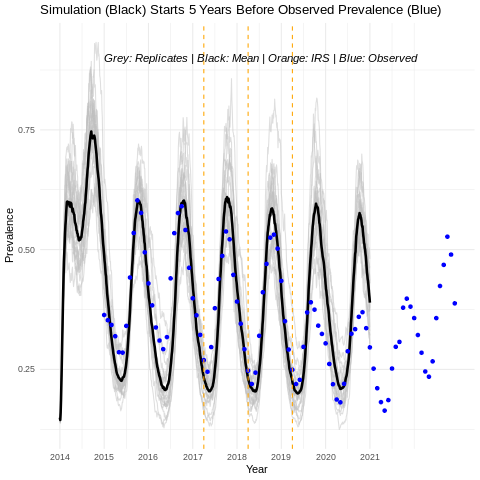

In [ ]:
%%R

## Periodic force of infection with precipitation (unchanged)
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

## Set parameters
Lambda <- 1.0182e7
#alpha <- 1.3499e-3
alpha<-0.0019166
mu <- 9.125

lambda <- 5.9869e5
beta <- 4.761e-9
delta <- 0.00645
gamma <- 0.20064
k <- 3
d <- 0.0336

sigma1 <- 0.32 * 2
sigma2 <- 0.23 * 2
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

## Basic reproduction number
R0 <- sqrt(Lambda * lambda * alpha * beta /
  ((mu + sigma1^2 / 2) * (mu + sigma2^2 / 2) *
   (delta + sigma3^2 / 2) * (delta + k + d + sigma4^2 / 2)))
print(R0)
print(min(mu, delta) < 0.5 * max(sigma1^2, sigma2^2, sigma3^2, sigma4^2, sigma5^2))

## Extend time: simulate from 2010 to 2023 (13 years)
TT <- 7
dt <- 1 / 120
N <- TT / dt
time <- round(seq(0, TT, by = dt), 5)

## Shift IRS campaigns forward: first one now starts in year 2017.25 (time = 7.25)
IRScampaigns <- list(
  "interv1" = c(t = 3.25, a = 0,   k = 2),  # 2017.25
  "interv2" = c(t = 4.25, a = 0, k = 2),  # 2018.25
  "interv3" = c(t = 5.25, a = 0, k = 2)   # 2019.25
)

## Exponential decay of vector control
vc_exp_decay <- function(i, time, interv = IRScampaigns) {
  if (i == 0) return(0)

  sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  }) -> df

  df * (time[i] > sapply(interv, function(y) y[1])) -> df
  sum(df)
}

## Initial conditions
Sv0 <- 4.5e6
Iv0 <- 4.7e3
Sh0 <- 4.4e7
Ih0 <- 1.3144e4
Rh0 <- 1e4

n_reps <- 20
results <- list()

set.seed(123)
for (rep in 1:n_reps) {
  Sv <- numeric(length(time))
  Iv <- numeric(length(time))
  Sh <- numeric(length(time))
  Ih <- numeric(length(time))
  Rh <- numeric(length(time))
  Nh <- numeric(length(time))

  Sv[1] <- Sv0
  Iv[1] <- Iv0
  Sh[1] <- Sh0
  Ih[1] <- Ih0
  Rh[1] <- Rh0
  Nh[1] <- Sh[1] + Ih[1] + Rh[1]

  for (i in 1:N) {
    dB <- rnorm(5, mean = 0, sd = sqrt(dt))
    dB2 <- dB^2 - dt

    mu_vc_i <- mu + mu * vc_exp_decay(i, time)

    Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
      sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

    Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
      sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

    Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
      sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

    Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
      sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

    Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
      sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

    Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
  }

  df <- data.frame(
    time = rep(time, 5),
    value = c(Sv, Iv, Sh, Ih, Rh),
    variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
    replicate = rep(rep, length(time) * 5)
  )

  results[[rep]] <- df
}

## Combine results and calculate prevalence
all_data <- do.call(rbind, results)

df <- all_data %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h) %>%
  group_by(time) %>%
  mutate(prev_h_mean = mean(prev_h))

## Plot with observed data starting from 2015
# Shift observed data to start from 2015 (time = 5)
df_prev_shifted <- df_prev %>% mutate(time = time + 1)

# Final plot: simulated prevalence from 2010, observed prevalence from 2015
ggplot() +
  geom_line(data = df, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:7, labels = 2014:2021) +
  scale_y_continuous(name = "Prevalence") +
  labs(title = "Simulation (Black) Starts 5 Years Before Observed Prevalence (Blue)") +
  theme_minimal() +
  annotate("text", x = 1, y = 0.9,
           label = "Grey: Replicates | Black: Mean | Orange: IRS | Blue: Observed",
           size = 4, hjust = 0, fontface = "italic")


# Counter Factual

[1] 3.452075
[1] TRUE
[1] "Debug: Effect size value ="


Effect size: A 1% increase in vector mortality leads to a 1.43% decrease in prevalence in 2017.


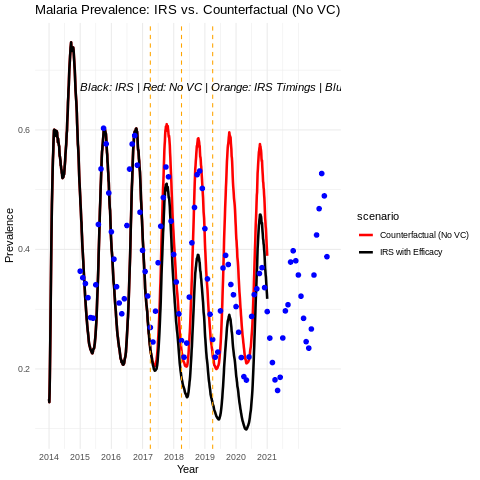

In [ ]:
%%R
## Periodic force of infection with precipitation (unchanged)
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

## Set parameters (same for all scenarios)
Lambda <- 1.0182e7
alpha <- 0.0019166
mu <- 9.125
lambda <- 5.9869e5
beta <- 4.761e-9
delta <- 0.00645
gamma <- 0.20064
k <- 3
d <- 0.0336
sigma1 <- 0.32 * 2
sigma2 <- 0.23 * 2
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

## Basic reproduction number
R0 <- sqrt(Lambda * lambda * alpha * beta /
  ((mu + sigma1^2 / 2) * (mu + sigma2^2 / 2) *
   (delta + sigma3^2 / 2) * (delta + k + d + sigma4^2 / 2)))
print(R0)
print(min(mu, delta) < 0.5 * max(sigma1^2, sigma2^2, sigma3^2, sigma4^2, sigma5^2))

## Simulation settings
TT <- 7
dt <- 1 / 120
N <- TT / dt
time <- round(seq(0, TT, by = dt), 5)

## Initial conditions
Sv0 <- 4.5e6
Iv0 <- 4.7e3
Sh0 <- 4.4e7
Ih0 <- 1.3144e4
Rh0 <- 1e4
n_reps <- 20

## Function to run simulation for a given scenario
run_simulation <- function(vc_function) {
  results <- list()
  set.seed(123)
  for (rep in 1:n_reps) {
    Sv <- numeric(length(time))
    Iv <- numeric(length(time))
    Sh <- numeric(length(time))
    Ih <- numeric(length(time))
    Rh <- numeric(length(time))
    Nh <- numeric(length(time))

    Sv[1] <- Sv0
    Iv[1] <- Iv0
    Sh[1] <- Sh0
    Ih[1] <- Ih0
    Rh[1] <- Rh0
    Nh[1] <- Sh[1] + Ih[1] + Rh[1]

    for (i in 1:N) {
      dB <- rnorm(5, mean = 0, sd = sqrt(dt))
      dB2 <- dB^2 - dt
      mu_vc_i <- mu + mu * vc_function(i, time)

      Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
        sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]
      Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
        sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]
      Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
        sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]
      Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
        sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]
      Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
        sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]
      Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
    }

    df <- data.frame(
      time = rep(time, 5),
      value = c(Sv, Iv, Sh, Ih, Rh),
      variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
      replicate = rep(rep, length(time) * 5)
    )
    results[[rep]] <- df
  }

  all_data <- do.call(rbind, results)
  df <- all_data %>%
    pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
    mutate(N_h = S_h + I_h + R_h, prev_h = 500 * I_h / N_h) %>%
    group_by(time) %>%
    summarise(prev_h_mean = mean(prev_h), .groups = "drop")
  return(df)
}

## Scenario 1: IRS with efficacy intact
IRScampaigns <- list(
  "interv1" = c(t = 3.25, a = 0.3816, k = 2),
  "interv2" = c(t = 4.25, a = 0.7054, k = 2),
  "interv3" = c(t = 5.25, a = 1.2221, k = 2)
)
vc_exp_decay <- function(i, time, interv = IRScampaigns) {
  if (i == 0) return(0)
  df <- sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  })
  df <- df * (time[i] > sapply(interv, function(y) y[1]))
  sum(df)
}
df_irs <- run_simulation(vc_exp_decay)

## Scenario 2: Counterfactual (No VC)
IRScampaigns_counter <- list(
  "interv1" = c(t = 3.25, a = 0, k = 2),
  "interv2" = c(t = 4.25, a = 0, k = 2),
  "interv3" = c(t = 5.25, a = 0, k = 2)
)
vc_exp_decay_counter <- function(i, time, interv = IRScampaigns_counter) {
  if (i == 0) return(0)
  df <- sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  })
  df <- df * (time[i] > sapply(interv, function(y) y[1]))
  sum(df)
}
df_counter <- run_simulation(vc_exp_decay_counter)

## Scenario 3: 1% increase in vector mortality
vc_1percent <- function(i, time) {
  return(0.01) # 1% increase in mu
}
df_1percent <- run_simulation(vc_1percent)

## Calculate effect size at time = 3 (2017)
prev_counter_2017 <- df_counter$prev_h_mean[df_counter$time == 3]
prev_1percent_2017 <- df_1percent$prev_h_mean[df_1percent$time == 3]
effect_size <- ((prev_counter_2017 - prev_1percent_2017) / prev_counter_2017) * 100
# Debug: Print effect size once to verify
print("Debug: Effect size value =", effect_size)
message("Effect size: A 1% increase in vector mortality leads to a ", round(effect_size, 2), "% decrease in prevalence in 2017.")

## Prepare data for plotting
df_plot <- rbind(
  df_irs %>% mutate(scenario = "IRS with Efficacy"),
  df_counter %>% mutate(scenario = "Counterfactual (No VC)")
)

## Plot prevalence curves
library(ggplot2)
df_prev_shifted <- df_prev %>% mutate(time = time + 1)
ggplot() +
  geom_line(data = df_plot, aes(x = time, y = prev_h_mean, color = scenario), linewidth = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue", size = 2) +
  geom_vline(xintercept = c(3.25, 4.25, 5.25), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:7, labels = 2014:2021) +
  scale_y_continuous(name = "Prevalence") +
  scale_color_manual(values = c("IRS with Efficacy" = "black", "Counterfactual (No VC)" = "red")) +
  labs(title = "Malaria Prevalence: IRS vs. Counterfactual (No VC)") +
  theme_minimal() +
  annotate("text", x = 1, y = max(df_plot$prev_h_mean) * 0.9,
           label = "Black: IRS | Red: No VC | Orange: IRS Timings | Blue: Observed",
           size = 4, hjust = 0, fontface = "italic")

# Comparing all the years

[1] 3.452075
[1] TRUE
[1] 3.452075
[1] TRUE


Effect size for 2017: A 1% increase in vector mortality leads to a 1.43% decrease in prevalence.
Effect size for 2018: A 1% increase in vector mortality leads to a 1.43% decrease in prevalence.
Effect size for 2019: A 1% increase in vector mortality leads to a 1.46% decrease in prevalence.
Effect size for 2017: A 1% increase in vector mortality leads to a 1.43% decrease in prevalence.
Effect size for 2018: A 1% increase in vector mortality leads to a 1.43% decrease in prevalence.
Effect size for 2019: A 1% increase in vector mortality leads to a 1.46% decrease in prevalence.


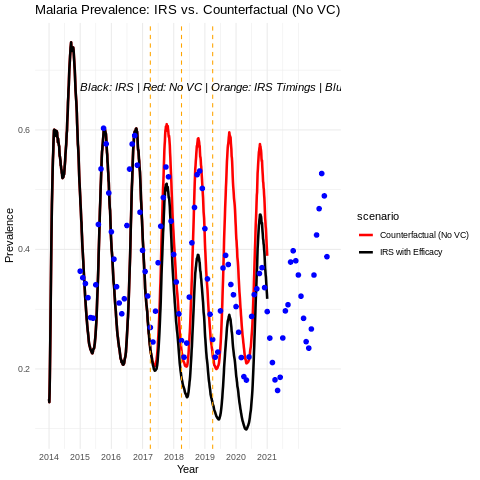

In [ ]:
%%R
## Periodic force of infection with precipitation (unchanged)
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

## Set parameters (same for all scenarios)
Lambda <- 1.0182e7
alpha <- 0.0019166
mu <- 9.125
lambda <- 5.9869e5
beta <- 4.761e-9
delta <- 0.00645
gamma <- 0.20064
k <- 3
d <- 0.0336
sigma1 <- 0.32 * 2
sigma2 <- 0.23 * 2
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

## Basic reproduction number
R0 <- sqrt(Lambda * lambda * alpha * beta /
  ((mu + sigma1^2 / 2) * (mu + sigma2^2 / 2) *
   (delta + sigma3^2 / 2) * (delta + k + d + sigma4^2 / 2)))
print(R0)
print(min(mu, delta) < 0.5 * max(sigma1^2, sigma2^2, sigma3^2, sigma4^2, sigma5^2))

## Simulation settings
TT <- 7
dt <- 1 / 120
N <- TT / dt
time <- round(seq(0, TT, by = dt), 5)

## Initial conditions
Sv0 <- 4.5e6
Iv0 <- 4.7e3
Sh0 <- 4.4e7
Ih0 <- 1.3144e4
Rh0 <- 1e4
n_reps <- 20

## Function to run simulation for a given scenario
run_simulation <- function(vc_function) {
  results <- list()
  set.seed(123)
  for (rep in 1:n_reps) {
    Sv <- numeric(length(time))
    Iv <- numeric(length(time))
    Sh <- numeric(length(time))
    Ih <- numeric(length(time))
    Rh <- numeric(length(time))
    Nh <- numeric(length(time))

    Sv[1] <- Sv0
    Iv[1] <- Iv0
    Sh[1] <- Sh0
    Ih[1] <- Ih0
    Rh[1] <- Rh0
    Nh[1] <- Sh[1] + Ih[1] + Rh[1]

    for (i in 1:N) {
      dB <- rnorm(5, mean = 0, sd = sqrt(dt))
      dB2 <- dB^2 - dt
      mu_vc_i <- mu + mu * vc_function(i, time)

      Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
        sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]
      Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
        sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]
      Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
        sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]
      Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
        sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]
      Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
        sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]
      Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
    }

    df <- data.frame(
      time = rep(time, 5),
      value = c(Sv, Iv, Sh, Ih, Rh),
      variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
      replicate = rep(rep, length(time) * 5)
    )
    results[[rep]] <- df
  }

  all_data <- do.call(rbind, results)
  df <- all_data %>%
    pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
    mutate(N_h = S_h + I_h + R_h, prev_h = 500 * I_h / N_h) %>%
    group_by(time) %>%
    summarise(prev_h_mean = mean(prev_h), .groups = "drop")
  return(df)
}

## Scenario 1: IRS with efficacy intact
IRScampaigns <- list(
  "interv1" = c(t = 3.25, a = 0.3816, k = 2),
  "interv2" = c(t = 4.25, a = 0.7054, k = 2),
  "interv3" = c(t = 5.25, a = 1.2221, k = 2)
)
vc_exp_decay <- function(i, time, interv = IRScampaigns) {
  if (i == 0) return(0)
  df <- sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  })
  df <- df * (time[i] > sapply(interv, function(y) y[1]))
  sum(df)
}
df_irs <- run_simulation(vc_exp_decay)

## Scenario 2: Counterfactual (No VC)
IRScampaigns_counter <- list(
  "interv1" = c(t = 3.25, a = 0, k = 2),
  "interv2" = c(t = 4.25, a = 0, k = 2),
  "interv3" = c(t = 5.25, a = 0, k = 2)
)
vc_exp_decay_counter <- function(i, time, interv = IRScampaigns_counter) {
  if (i == 0) return(0)
  df <- sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  })
  df <- df * (time[i] > sapply(interv, function(y) y[1]))
  sum(df)
}
df_counter <- run_simulation(vc_exp_decay_counter)

## Scenario 3: 1% increase in vector mortality
vc_1percent <- function(i, time) {
  return(0.01) # 1% increase in mu
}
df_1percent <- run_simulation(vc_1percent)

## Calculate effect size for multiple time periods (2017, 2018, 2019)
time_points <- c(3, 4, 5)
years <- c(2017, 2018, 2019)

for (j in 1:length(time_points)) {
  t <- time_points[j]
  year <- years[j]
  prev_counter <- df_counter$prev_h_mean[df_counter$time == t]
  prev_1percent <- df_1percent$prev_h_mean[df_1percent$time == t]
  effect_size <- ((prev_counter - prev_1percent) / prev_counter) * 100
  message("Effect size for ", year, ": A 1% increase in vector mortality leads to a ", round(effect_size, 2), "% decrease in prevalence.")
}

## Prepare data for plotting
df_plot <- rbind(
  df_irs %>% mutate(scenario = "IRS with Efficacy"),
  df_counter %>% mutate(scenario = "Counterfactual (No VC)")
)

## Plot prevalence curves
library(ggplot2)
df_prev_shifted <- df_prev %>% mutate(time = time + 1)
ggplot() +
  geom_line(data = df_plot, aes(x = time, y = prev_h_mean, color = scenario), linewidth = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue", size = 2) +
  geom_vline(xintercept = c(3.25, 4.25, 5.25), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:7, labels = 2014:2021) +
  scale_y_continuous(name = "Prevalence") +
  scale_color_manual(values = c("IRS with Efficacy" = "black", "Counterfactual (No VC)" = "red")) +
  labs(title = "Malaria Prevalence: IRS vs. Counterfactual (No VC)") +
  theme_minimal() +
  annotate("text", x = 1, y = max(df_plot$prev_h_mean) * 0.9,
           label = "Black: IRS | Red: No VC | Orange: IRS Timings | Blue: Observed",
           size = 4, hjust = 0, fontface = "italic")## Periodic force of infection with precipitation (unchanged)
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

## Set parameters (same for all scenarios)
Lambda <- 1.0182e7
alpha <- 0.0019166
mu <- 9.125
lambda <- 5.9869e5
beta <- 4.761e-9
delta <- 0.00645
gamma <- 0.20064
k <- 3
d <- 0.0336
sigma1 <- 0.32 * 2
sigma2 <- 0.23 * 2
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

## Basic reproduction number
R0 <- sqrt(Lambda * lambda * alpha * beta /
  ((mu + sigma1^2 / 2) * (mu + sigma2^2 / 2) *
   (delta + sigma3^2 / 2) * (delta + k + d + sigma4^2 / 2)))
print(R0)
print(min(mu, delta) < 0.5 * max(sigma1^2, sigma2^2, sigma3^2, sigma4^2, sigma5^2))

## Simulation settings
TT <- 7
dt <- 1 / 120
N <- TT / dt
time <- round(seq(0, TT, by = dt), 5)

## Initial conditions
Sv0 <- 4.5e6
Iv0 <- 4.7e3
Sh0 <- 4.4e7
Ih0 <- 1.3144e4
Rh0 <- 1e4
n_reps <- 20

## Function to run simulation for a given scenario
run_simulation <- function(vc_function) {
  results <- list()
  set.seed(123)
  for (rep in 1:n_reps) {
    Sv <- numeric(length(time))
    Iv <- numeric(length(time))
    Sh <- numeric(length(time))
    Ih <- numeric(length(time))
    Rh <- numeric(length(time))
    Nh <- numeric(length(time))

    Sv[1] <- Sv0
    Iv[1] <- Iv0
    Sh[1] <- Sh0
    Ih[1] <- Ih0
    Rh[1] <- Rh0
    Nh[1] <- Sh[1] + Ih[1] + Rh[1]

    for (i in 1:N) {
      dB <- rnorm(5, mean = 0, sd = sqrt(dt))
      dB2 <- dB^2 - dt
      mu_vc_i <- mu + mu * vc_function(i, time)

      Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
        sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]
      Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
        sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]
      Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
        sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]
      Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
        sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]
      Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
        sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]
      Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
    }

    df <- data.frame(
      time = rep(time, 5),
      value = c(Sv, Iv, Sh, Ih, Rh),
      variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
      replicate = rep(rep, length(time) * 5)
    )
    results[[rep]] <- df
  }

  all_data <- do.call(rbind, results)
  df <- all_data %>%
    pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
    mutate(N_h = S_h + I_h + R_h, prev_h = 500 * I_h / N_h) %>%
    group_by(time) %>%
    summarise(prev_h_mean = mean(prev_h), .groups = "drop")
  return(df)
}

## Scenario 1: IRS with efficacy intact
IRScampaigns <- list(
  "interv1" = c(t = 3.25, a = 0.3816, k = 2),
  "interv2" = c(t = 4.25, a = 0.7054, k = 2),
  "interv3" = c(t = 5.25, a = 1.2221, k = 2)
)
vc_exp_decay <- function(i, time, interv = IRScampaigns) {
  if (i == 0) return(0)
  df <- sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  })
  df <- df * (time[i] > sapply(interv, function(y) y[1]))
  sum(df)
}
df_irs <- run_simulation(vc_exp_decay)

## Scenario 2: Counterfactual (No VC)
IRScampaigns_counter <- list(
  "interv1" = c(t = 3.25, a = 0, k = 2),
  "interv2" = c(t = 4.25, a = 0, k = 2),
  "interv3" = c(t = 5.25, a = 0, k = 2)
)
vc_exp_decay_counter <- function(i, time, interv = IRScampaigns_counter) {
  if (i == 0) return(0)
  df <- sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  })
  df <- df * (time[i] > sapply(interv, function(y) y[1]))
  sum(df)
}
df_counter <- run_simulation(vc_exp_decay_counter)

## Scenario 3: 1% increase in vector mortality
vc_1percent <- function(i, time) {
  return(0.01) # 1% increase in mu
}
df_1percent <- run_simulation(vc_1percent)

## Calculate effect size for multiple time periods (2017, 2018, 2019)
time_points <- c(3, 4, 5)
years <- c(2017, 2018, 2019)

for (j in 1:length(time_points)) {
  t <- time_points[j]
  year <- years[j]
  prev_counter <- df_counter$prev_h_mean[df_counter$time == t]
  prev_1percent <- df_1percent$prev_h_mean[df_1percent$time == t]
  effect_size <- ((prev_counter - prev_1percent) / prev_counter) * 100
  message("Effect size for ", year, ": A 1% increase in vector mortality leads to a ", round(effect_size, 2), "% decrease in prevalence.")
}

## Prepare data for plotting
df_plot <- rbind(
  df_irs %>% mutate(scenario = "IRS with Efficacy"),
  df_counter %>% mutate(scenario = "Counterfactual (No VC)")
)

## Plot prevalence curves
library(ggplot2)
df_prev_shifted <- df_prev %>% mutate(time = time + 1)
ggplot() +
  geom_line(data = df_plot, aes(x = time, y = prev_h_mean, color = scenario), linewidth = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue", size = 2) +
  geom_vline(xintercept = c(3.25, 4.25, 5.25), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:7, labels = 2014:2021) +
  scale_y_continuous(name = "Prevalence") +
  scale_color_manual(values = c("IRS with Efficacy" = "black", "Counterfactual (No VC)" = "red")) +
  labs(title = "Malaria Prevalence: IRS vs. Counterfactual (No VC)") +
  theme_minimal() +
  annotate("text", x = 1, y = max(df_plot$prev_h_mean) * 0.9,
           label = "Black: IRS | Red: No VC | Orange: IRS Timings | Blue: Observed",
           size = 4, hjust = 0, fontface = "italic")

# Simulation from 2015 to 2023

[1] 3.452075
[1] TRUE


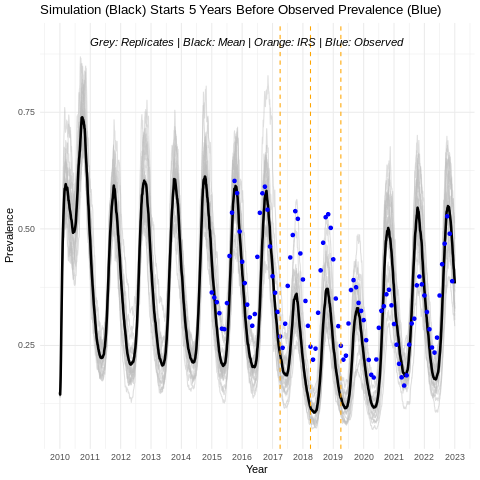

In [ ]:
%%R


## Periodic force of infection with precipitation (unchanged)
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

## Set parameters
Lambda <- 1.0182e7
#alpha <- 1.3499e-3
alpha<-0.0019166
mu <- 9.125

lambda <- 5.9869e5
beta <- 4.761e-9
delta <- 0.00645
gamma <- 0.20064
k <- 3
d <- 0.0336

sigma1 <- 0.32 * 2
sigma2 <- 0.23 * 2
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

## Basic reproduction number
R0 <- sqrt(Lambda * lambda * alpha * beta /
  ((mu + sigma1^2 / 2) * (mu + sigma2^2 / 2) *
   (delta + sigma3^2 / 2) * (delta + k + d + sigma4^2 / 2)))
print(R0)
print(min(mu, delta) < 0.5 * max(sigma1^2, sigma2^2, sigma3^2, sigma4^2, sigma5^2))

## Extend time: simulate from 2010 to 2023 (13 years)
TT <- 13
dt <- 1 / 120
N <- TT / dt
time <- round(seq(0, TT, by = dt), 5)

## Shift IRS campaigns forward: first one now starts in year 2017.25 (time = 7.25)
IRScampaigns <- list(
  "interv1" = c(t = 7.25, a = 1,   k = 2),  # 2017.25
  "interv2" = c(t = 8.25, a = 0.4, k = 2),  # 2018.25
  "interv3" = c(t =9.25, a = 0.8, k = 2)   # 2019.25
)

## Exponential decay of vector control
vc_exp_decay <- function(i, time, interv = IRScampaigns) {
  if (i == 0) return(0)

  sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  }) -> df

  df * (time[i] > sapply(interv, function(y) y[1])) -> df
  sum(df)
}

## Initial conditions
Sv0 <- 4.5e6
Iv0 <- 4.7e3
Sh0 <- 4.4e7
Ih0 <- 1.3144e4
Rh0 <- 1e4

n_reps <- 20
results <- list()

set.seed(123)
for (rep in 1:n_reps) {
  Sv <- numeric(length(time))
  Iv <- numeric(length(time))
  Sh <- numeric(length(time))
  Ih <- numeric(length(time))
  Rh <- numeric(length(time))
  Nh <- numeric(length(time))

  Sv[1] <- Sv0
  Iv[1] <- Iv0
  Sh[1] <- Sh0
  Ih[1] <- Ih0
  Rh[1] <- Rh0
  Nh[1] <- Sh[1] + Ih[1] + Rh[1]

  for (i in 1:N) {
    dB <- rnorm(5, mean = 0, sd = sqrt(dt))
    dB2 <- dB^2 - dt

    mu_vc_i <- mu + mu * vc_exp_decay(i, time)

    Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
      sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

    Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
      sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

    Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
      sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

    Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
      sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

    Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
      sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

    Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
  }

  df <- data.frame(
    time = rep(time, 5),
    value = c(Sv, Iv, Sh, Ih, Rh),
    variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
    replicate = rep(rep, length(time) * 5)
  )

  results[[rep]] <- df
}

## Combine results and calculate prevalence
all_data <- do.call(rbind, results)

df <- all_data %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h) %>%
  group_by(time) %>%
  mutate(prev_h_mean = mean(prev_h))

## Plot with observed data starting from 2015
# Shift observed data to start from 2015 (time = 5)
df_prev_shifted <- df_prev %>% mutate(time = time + 5)

# Final plot: simulated prevalence from 2010, observed prevalence from 2015
ggplot() +
  geom_line(data = df, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:13, labels = 2010:2023) +
  scale_y_continuous(name = "Prevalence") +
  labs(title = "Simulation (Black) Starts 5 Years Before Observed Prevalence (Blue)") +
  theme_minimal() +
  annotate("text", x = 1, y = 0.9,
           label = "Grey: Replicates | Black: Mean | Orange: IRS | Blue: Observed",
           size = 4, hjust = 0, fontface = "italic")


# IRS Efficacy Parameter

In [ ]:
%%R

library(tidyverse)
library(ggplot2)

# --- PARAMETERS ---
Lambda <- 1.0182e7
alpha <- 0.0019166  # fixed alpha from earlier
mu <- 9.125
lambda <- 5.9869e5
beta <- 4.761e-9
delta <- 0.00645
gamma <- 0.20064
k <- 3
d <- 0.0336

sigma1 <- 0.64
sigma2 <- 0.46
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

# --- TIME ---
TT <- 13
dt <- 1 / 120
N <- TT / dt
time <- round(seq(0, TT, by = dt), 5)

# --- PERIODIC FORCE ---
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

# --- IRS Campaigns (decay rate fixed) ---
IRScampaigns <- list(
  "interv1" = c(t = 7.25, a = 0,   k = 2),
  "interv2" = c(t = 8.25, a = 1, k = 2),
  "interv3" = c(t = 9.25, a = 1, k = 2)
)

# --- Decay Function ---
vc_exp_decay <- function(i, time, a_val, interv = IRScampaigns) {
  if (i == 0) return(0)
  sapply(interv, function(x) {
    a_val * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  }) -> df
  df * (time[i] > sapply(interv, function(y) y[1])) -> df
  sum(df)
}

# --- Initial States ---
Sv0 <- 4.5e6
Iv0 <- 4.7e3
Sh0 <- 4.4e7
Ih0 <- 1.3144e4
Rh0 <- 1e4

# --- Prior ---
a_range <- c(0, 1.5)
n_particles <- 10
n_iter <- 25
n_reps <- 20

prior_sample_a <- function(n) {
  data.frame(a = runif(n, a_range[1], a_range[2]))
}

compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time")
  error <- common$prev_h_mean - common$prevalence_under5
  -sum(error^2, na.rm = TRUE)
}

# --- SMC START ---
particles <- prior_sample_a(n_particles)
weights <- rep(1 / n_particles, n_particles)
df_best_all <- NULL
best_likelihood <- -Inf
best_a <- NULL
posterior_a <- NULL
best_replicates <- NULL

set.seed(123)
for (iter in 1:n_iter) {
  message("SMC iteration: ", iter)
  likelihoods <- numeric(n_particles)

  for (p in 1:n_particles) {
    a_val <- particles$a[p]
    results <- list()

    for (rep in 1:n_reps) {
      Sv <- numeric(length(time))
      Iv <- numeric(length(time))
      Sh <- numeric(length(time))
      Ih <- numeric(length(time))
      Rh <- numeric(length(time))
      Nh <- numeric(length(time))

      Sv[1] <- Sv0; Iv[1] <- Iv0
      Sh[1] <- Sh0; Ih[1] <- Ih0
      Rh[1] <- Rh0; Nh[1] <- Sh[1] + Ih[1] + Rh[1]

      for (i in 1:N) {
        dB <- rnorm(5, mean = 0, sd = sqrt(dt))
        dB2 <- dB^2 - dt
        mu_vc_i <- mu + mu * vc_exp_decay(i, time, a_val)

        Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
                     sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]
        Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
                     sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]
        Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                     sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]
        Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
                     sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]
        Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
                     sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

        Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
      }

      df <- data.frame(
        time = rep(time, 5),
        value = c(Sv, Iv, Sh, Ih, Rh),
        variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
        replicate = rep(rep, length(time) * 5)
      )
      results[[rep]] <- df
    }

    all_data <- bind_rows(results)
    df_sim <- all_data %>%
      pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
      mutate(N_h = S_h + I_h + R_h,
             prev_h = ifelse(N_h > 0, 500 * I_h / N_h, NA)) %>%
      group_by(time) %>%
      summarise(prev_h_mean = mean(prev_h, na.rm = TRUE), .groups = "drop")

    likelihoods[p] <- compute_likelihood(df_sim, df_prev)

    if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
      best_likelihood <- likelihoods[p]
      best_a <- a_val
      df_best_all <- df_sim
      best_replicates <- all_data
    }
  }

  weights <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
  weights <- weights / sum(weights)
  resample_idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = weights)
  particles <- particles[resample_idx, , drop = FALSE]
  posterior_a <- c(posterior_a, particles$a)
}

# --- FINAL DATA PROCESSING AND PLOTTING ---
df_reps <- best_replicates %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = ifelse(N_h > 0, 500 * I_h / N_h, NA))

df_prev_shifted <- df_prev %>% mutate(time = time + 5)

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.4) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:13, labels = 2010:2023) +
  labs(title = "SMC Fit: Estimating IRS Efficacy (a)", y = "Prevalence") +
  theme_minimal()

# --- POSTERIOR ---
posterior_df <- data.frame(a = posterior_a)
ggplot(posterior_df, aes(x = a)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", linewidth = 1.2) +
  geom_vline(xintercept = best_a, linetype = "dashed", color = "red") +
  annotate("text", x = best_a, y = Inf, label = paste("Best a:", signif(best_a, 5)),
           hjust = 1.1, vjust = 2, color = "red", size = 3.5) +
  labs(title = "Posterior Distribution of IRS Efficacy (a)", x = "a", y = "Density") +
  theme_minimal()

# --- OUTPUT ---
cat("Best a estimate:", signif(best_a, 5), "\n")
cat("95% credible interval for a:\n")
print(quantile(posterior_a, probs = c(0.025, 0.5, 0.975)))





Best a estimate: 0.38163 
95% credible interval for a:
    2.5%      50%    97.5% 
0.381627 0.381627 1.222127 


SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25



(`geom_line()`). 



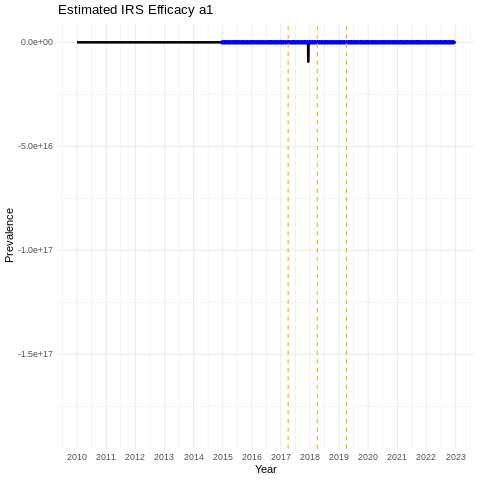

In [ ]:
%%R

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.4) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:13, labels = 2010:2023) +
  scale_y_continuous(name = "Prevalence") +
  labs(title = "Estimated IRS Efficacy a1", y = "Prevalence") +
  theme_minimal()


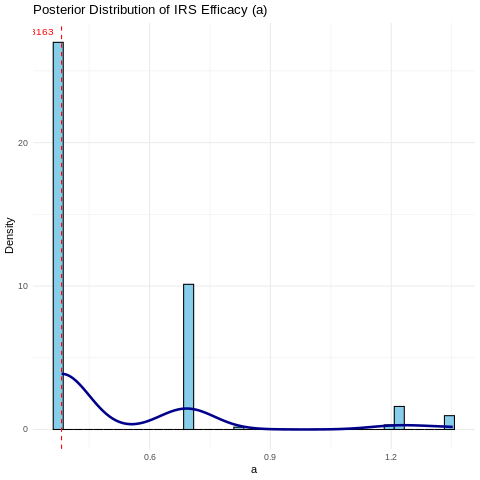

In [ ]:
%%R

# --- POSTERIOR ---
posterior_df <- data.frame(a = posterior_a)
ggplot(posterior_df, aes(x = a)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", linewidth = 1.2) +
  geom_vline(xintercept = best_a, linetype = "dashed", color = "red") +
  annotate("text", x = best_a, y = Inf, label = paste("Best a:", signif(best_a, 5)),
           hjust = 1.1, vjust = 2, color = "red", size = 3.5) +
  labs(title = "Posterior Distribution of IRS Efficacy (a)", x = "a", y = "Density") +
  theme_minimal()

# ESTIMATING ALL EFFICACY PARAMETERS AT AGO

In [ ]:
%%R

library(tidyverse)
library(ggplot2)

# ----------------------------
# Fixed parameters (use your values)
# ----------------------------
Lambda <- 1.0182e7
alpha  <- 0.0019166
mu     <- 9.125

lambda <- 5.9869e5
beta   <- 4.761e-9
delta  <- 0.00645
gamma  <- 0.20064
k      <- 3
d      <- 0.0336

sigma1 <- 0.64
sigma2 <- 0.46
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

# ----------------------------
# Time grid
# ----------------------------
TT <- 13
dt <- 1/120
time <- round(seq(0, TT, by = dt), 5)   # length = N+1
N <- length(time) - 1

# ----------------------------
# Seasonal forcing (expects df_period available)
# ----------------------------
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

# ----------------------------
# IRS campaigns (decay rate k fixed = 2 here)
# ----------------------------
IRScampaigns <- list(
  interv1 = c(t = 7.25, a = 1, k = 2),
  interv2 = c(t = 8.25, a = 1, k = 2),
  interv3 = c(t = 9.25, a = 1, k = 2)
)

# ----------------------------
# Exponential decay function using a named vector a_vec
# a_vec should be named with names(IRScampaigns)
# ----------------------------
vc_exp_decay <- function(i, time, a_vec, interv = IRScampaigns) {
  if (i == 0) return(0)
  cn <- names(interv)
  a_here <- a_vec[cn]
  # compute for each campaign the contribution at time[i]
  contrib <- mapply(function(x, a_val) {
    a_val * exp(-x["k"] * pmax(0, time[i] - x["t"]))
  }, interv, a_here, SIMPLIFY = TRUE)
  # only include contributions for campaigns already started
  contrib <- contrib * (time[i] > sapply(interv, function(x) x["t"]))
  sum(contrib)
}

# ----------------------------
# Initial states
# ----------------------------
Sv0 <- 4.5e6
Iv0 <- 4.7e3
Sh0 <- 4.4e7
Ih0 <- 1.3144e4
Rh0 <- 1e4

# ----------------------------
# SMC settings
# ----------------------------
a_range <- c(0.0, 1.5)     # prior range for a
n_particles <- 10
n_iter <- 25
n_reps <- 20

prior_sample_a <- function(n) data.frame(a = runif(n, a_range[1], a_range[2]))

# Likelihood: join simulated summary to observed df_prev by "time".
compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time")
  if (nrow(common) == 0) return(-Inf)
  err <- common$prev_h_mean - common$prevalence_under5
  -sum(err^2, na.rm = TRUE)
}

# ----------------------------
# SMC: estimate a for campaign 1 (others fixed to 1)
# ----------------------------
target_campaign_name <- "interv1"   # estimate this one
fixed_a_vec <- c(interv1 = NA, interv2 = 1, interv3 = 1) # NA will be replaced by particle a

particles <- prior_sample_a(n_particles)
weights <- rep(1 / n_particles, n_particles)
posterior_a <- numeric(0)
best_likelihood <- -Inf
best_a <- NA
df_best_all <- NULL
best_replicates <- NULL

set.seed(123)
for (iter in 1:n_iter) {
  message("SMC iteration: ", iter)
  likelihoods <- numeric(n_particles)

  for (p in 1:n_particles) {
    a_p <- particles$a[p]
    # build a_vec for this particle (named)
    a_vec <- fixed_a_vec
    a_vec[target_campaign_name] <- a_p
    names(a_vec) <- names(IRScampaigns)

    # collect replicates
    rep_out <- vector("list", n_reps)

    for (rep in 1:n_reps) {
      # initial vectors (ensure length time)
      Sv <- numeric(length(time)); Iv <- numeric(length(time))
      Sh <- numeric(length(time)); Ih <- numeric(length(time)); Rh <- numeric(length(time))
      Sv[1] <- Sv0; Iv[1] <- Iv0
      Sh[1] <- Sh0; Ih[1] <- Ih0; Rh[1] <- Rh0

      # Milstein loop: i from 1 to length(time)-1
      for (i in 1:(length(time)-1)) {
        dB <- rnorm(5, mean = 0, sd = sqrt(dt))
        dB2 <- dB^2 - dt
        mu_vc_i <- mu + mu * vc_exp_decay(i, time, a_vec)

        Sv[i+1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
                   sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

        Iv[i+1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
                   sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

        Sh[i+1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                   sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

        Ih[i+1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
                   sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

        Rh[i+1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
                   sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]
      }

      # create wide df for this replicate (same lengths)
      rep_out[[rep]] <- data.frame(time = time,
                                   Sv = Sv, Iv = Iv,
                                   Sh = Sh, Ih = Ih, Rh = Rh,
                                   replicate = rep)
    } # end replicates

    # combine replicates into a single df for this particle
    all_data <- bind_rows(rep_out)

    # compute summary prev_h_mean by time
    df_sim <- all_data %>%
      group_by(time) %>%
      summarise(prev_h_mean = mean(ifelse((Sh + Ih + Rh) > 0, 500 * Ih / (Sh + Ih + Rh), NA), na.rm = TRUE),
                .groups = "drop")

    likelihoods[p] <- compute_likelihood(df_sim, df_prev)

    # track best
    if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
      best_likelihood <- likelihoods[p]
      best_a <- a_p
      df_best_all <- df_sim
      best_replicates <- all_data
    }
  } # end particles

  # weights + resample
  w <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
  if (all(is.na(w)) || sum(w, na.rm = TRUE) == 0) {
    # fallback: uniform
    w <- rep(1 / n_particles, n_particles)
  } else w <- w / sum(w, na.rm = TRUE)
  idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = w)
  particles <- particles[idx, , drop = FALSE]
  posterior_a <- c(posterior_a, particles$a)
} # end SMC

# ----------------------------
# Results plot + posterior
# ----------------------------
# replicate-level df for plotting (use best_replicates)
df_reps <- best_replicates %>%
  group_by(time, replicate) %>%
  mutate(N_h = Sh + Ih + Rh,
         prev_h = ifelse(N_h > 0, 500 * Ih / N_h, NA)) %>%
  ungroup()

df_prev_shifted <- df_prev %>% mutate(time = time + 5)  # if you want observed at 2015.. adjust if necessary

# Time axis labels: map 0..13 -> 2010..2023 if desired via scale_x_continuous(labels = 2010:2023, breaks = 0:13)
ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.4) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", size = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x["t"]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year (simulation time)") +
  labs(title = paste0("SMC fit — estimated a for ", target_campaign_name),
       y = "Prevalence (scaled)") +
  theme_minimal()

# posterior histogram + density
posterior_df <- data.frame(a = posterior_a)
ggplot(posterior_df, aes(x = a)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", size = 1) +
  geom_vline(xintercept = best_a, linetype = "dashed", color = "red") +
  labs(title = paste("Posterior for a —", target_campaign_name), x = "a", y = "Density") +
  theme_minimal()

cat("Best a estimate (", target_campaign_name, "):", signif(best_a, 5), "\n")
cat("95% credible interval for a:\n")
print(quantile(posterior_a, probs = c(0.025, 0.5, 0.975)))


Best a estimate ( interv1 ): 0.17923 
95% credible interval for a:
    2.5%      50%    97.5% 
0.179234 0.179234 0.655683 


SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25
In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


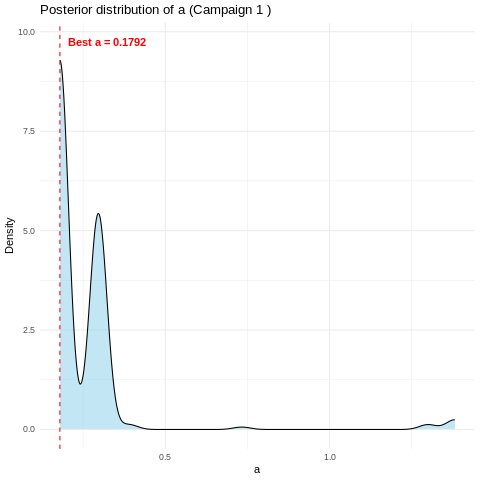

In [ ]:
%%R

# --- Posterior density plot ---
#df_post <- data.frame(a = posterior_df)
#ggplot(df_post, aes(x = a)) +
#  geom_density(fill = "skyblue", alpha = 0.5) +
 # labs(title = paste("Posterior distribution of a (Campaign", interv_index, ")"),
  #     x = "a", y = "Density") +
  #theme_minimal()


 # Ensure posterior_df is numeric
if (is.data.frame(posterior_df)) {
  posterior_vec <- posterior_df$a
} else {
  posterior_vec <- as.numeric(posterior_df)
}

# Calculate best a (posterior median)
a_best <- median(posterior_vec, na.rm = TRUE)

# Prepare data frame for plotting
df_post <- data.frame(a = posterior_vec)

# Plot
ggplot(df_post, aes(x = a)) +
  geom_density(fill = "skyblue", alpha = 0.5) +
  geom_vline(xintercept = a_best, color = "red", linetype = "dashed") +
  annotate(
    "text",
    x = a_best,
    y = max(density(df_post$a)$y) * 1.05,
    label = paste0("Best a = ", round(a_best, 4)),
    color = "red", fontface = "bold", hjust = -0.1
  ) +
  labs(
    title = paste("Posterior distribution of a (Efficay", interv_index, ")"),
    x = "a", y = "Density"
  ) +
  theme_minimal()




# First Intervention

In [ ]:
%%R
library(tidyverse)
library(ggplot2)

# ----------------------------
# Fixed parameters (use your values)
# ----------------------------
Lambda <- 1.0182e7
alpha  <- 0.0019166
mu     <- 9.125

lambda <- 5.9869e5
beta   <- 4.761e-9
delta  <- 0.00645
gamma  <- 0.20064
k      <- 3
d      <- 0.0336

sigma1 <- 0.64
sigma2 <- 0.46
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

# ----------------------------
# Time grid
# ----------------------------
TT <- 13
dt <- 1/120
time <- round(seq(0, TT, by = dt), 5)   # length = N+1
N <- length(time) - 1

# ----------------------------
# Seasonal forcing (expects df_period available)
# ----------------------------
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

# ----------------------------
# IRS campaigns (decay rate k fixed = 2 here)
# ----------------------------
IRScampaigns <- list(
  interv1 = c(t = 7.25, a = 1, k = 2),
  interv2 = c(t = 8.25, a = 1, k = 2),
  interv3 = c(t = 9.25, a = 1, k = 2)
)

# ----------------------------
# Exponential decay function using a named vector a_vec
# a_vec should be named with names(IRScampaigns)
# ----------------------------
vc_exp_decay <- function(i, time, a_vec, interv = IRScampaigns) {
  if (i == 0) return(0)
  cn <- names(interv)
  a_here <- a_vec[cn]
  # compute for each campaign the contribution at time[i]
  contrib <- mapply(function(x, a_val) {
    a_val * exp(-x["k"] * pmax(0, time[i] - x["t"]))
  }, interv, a_here, SIMPLIFY = TRUE)
  # only include contributions for campaigns already started
  contrib <- contrib * (time[i] > sapply(interv, function(x) x["t"]))
  sum(contrib)
}

# ----------------------------
# Initial states
# ----------------------------
Sv0 <- 4.5e6
Iv0 <- 4.7e3
Sh0 <- 4.4e7
Ih0 <- 1.3144e4
Rh0 <- 1e4

# ----------------------------
# SMC settings
# ----------------------------
a_range <- c(0.0, 1.5)     # prior range for a
n_particles <- 10
n_iter <- 25
n_reps <- 20

prior_sample_a <- function(n) data.frame(a = runif(n, a_range[1], a_range[2]))

# Likelihood: join simulated summary to observed df_prev by "time".
compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time")
  if (nrow(common) == 0) return(-Inf)
  err <- common$prev_h_mean - common$prevalence_under5
  -sum(err^2, na.rm = TRUE)
}

# ----------------------------
# SMC: estimate a for campaign 1 (others fixed to 1)
# ----------------------------
target_campaign_name <- "interv1"   # estimate this one
fixed_a_vec <- c(interv1 = NA, interv2 = 1, interv3 = 1) # NA will be replaced by particle a

particles <- prior_sample_a(n_particles)
weights <- rep(1 / n_particles, n_particles)
posterior_a <- numeric(0)
best_likelihood <- -Inf
best_a <- NA
df_best_all <- NULL
best_replicates <- NULL

set.seed(123)
for (iter in 1:n_iter) {
  message("SMC iteration: ", iter)
  likelihoods <- numeric(n_particles)

  for (p in 1:n_particles) {
    a_p <- particles$a[p]
    # build a_vec for this particle (named)
    a_vec <- fixed_a_vec
    a_vec[target_campaign_name] <- a_p
    names(a_vec) <- names(IRScampaigns)

    # collect replicates
    rep_out <- vector("list", n_reps)

    for (rep in 1:n_reps) {
      # initial vectors (ensure length time)
      Sv <- numeric(length(time)); Iv <- numeric(length(time))
      Sh <- numeric(length(time)); Ih <- numeric(length(time)); Rh <- numeric(length(time))
      Sv[1] <- Sv0; Iv[1] <- Iv0
      Sh[1] <- Sh0; Ih[1] <- Ih0; Rh[1] <- Rh0

      # Milstein loop: i from 1 to length(time)-1
      for (i in 1:(length(time)-1)) {
        dB <- rnorm(5, mean = 0, sd = sqrt(dt))
        dB2 <- dB^2 - dt
        mu_vc_i <- mu + mu * vc_exp_decay(i, time, a_vec)

        Sv[i+1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
                   sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

        Iv[i+1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
                   sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

        Sh[i+1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                   sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

        Ih[i+1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
                   sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

        Rh[i+1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
                   sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]
      }

      # create wide df for this replicate (same lengths)
      rep_out[[rep]] <- data.frame(time = time,
                                   Sv = Sv, Iv = Iv,
                                   Sh = Sh, Ih = Ih, Rh = Rh,
                                   replicate = rep)
    } # end replicates

    # combine replicates into a single df for this particle
    all_data <- bind_rows(rep_out)

    # compute summary prev_h_mean by time
    df_sim <- all_data %>%
      group_by(time) %>%
      summarise(prev_h_mean = mean(ifelse((Sh + Ih + Rh) > 0, 500 * Ih / (Sh + Ih + Rh), NA), na.rm = TRUE),
                .groups = "drop")

    likelihoods[p] <- compute_likelihood(df_sim, df_prev)

    # track best
    if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
      best_likelihood <- likelihoods[p]
      best_a <- a_p
      df_best_all <- df_sim
      best_replicates <- all_data
    }
  } # end particles

  # weights + resample
  w <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
  if (all(is.na(w)) || sum(w, na.rm = TRUE) == 0) {
    # fallback: uniform
    w <- rep(1 / n_particles, n_particles)
  } else w <- w / sum(w, na.rm = TRUE)
  idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = w)
  particles <- particles[idx, , drop = FALSE]
  posterior_a <- c(posterior_a, particles$a)
} # end SMC

# ----------------------------
# Results plot + posterior
# ----------------------------
# replicate-level df for plotting (use best_replicates)
df_reps <- best_replicates %>%
  group_by(time, replicate) %>%
  mutate(N_h = Sh + Ih + Rh,
         prev_h = ifelse(N_h > 0, 500 * Ih / N_h, NA)) %>%
  ungroup()

df_prev_shifted <- df_prev %>% mutate(time = time + 5)  # if you want observed at 2015.. adjust if necessary

# Time axis labels: map 0..13 -> 2010..2023 if desired via scale_x_continuous(labels = 2010:2023, breaks = 0:13)
ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.4) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", size = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x["t"]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year (simulation time)") +
  labs(title = paste0("SMC fit — estimated a for ", target_campaign_name),
       y = "Prevalence (scaled)") +
  theme_minimal()

# posterior histogram + density
posterior_df <- data.frame(a = posterior_a)
ggplot(posterior_df, aes(x = a)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", size = 1) +
  geom_vline(xintercept = best_a, linetype = "dashed", color = "red") +
  labs(title = paste("Posterior for a —", target_campaign_name), x = "a", y = "Density") +
  theme_minimal()

cat("Best a estimate (", target_campaign_name, "):", signif(best_a, 5), "\n")
cat("95% credible interval for a:\n")
print(quantile(posterior_a, probs = c(0.025, 0.5, 0.975)))


Best a estimate ( interv1 ): 0.322 
95% credible interval for a:
     2.5%       50%     97.5% 
0.3220014 0.3220014 1.4081565 


SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25
In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


Best a estimate ( interv1 ): 0.322 
95% credible interval for a:
     2.5%       50%     97.5% 
0.3220014 0.3220014 1.4081565 


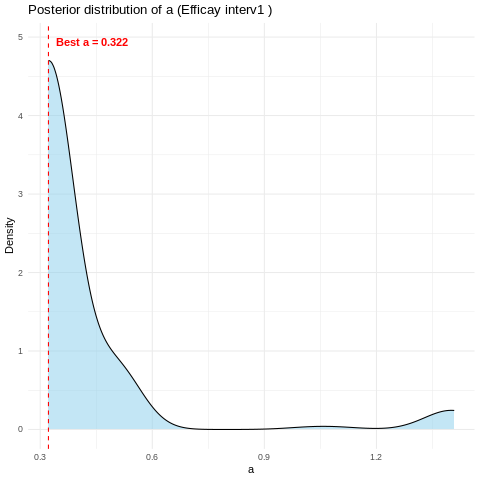

In [ ]:
%%R
posterior_df <- data.frame(a = posterior_a)
ggplot(posterior_df, aes(x = a)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", size = 1) +
  geom_vline(xintercept = best_a, linetype = "dashed", color = "red") +
  labs(title = paste("Posterior for a —", target_campaign_name), x = "a", y = "Density") +
  theme_minimal()

cat("Best a estimate (", target_campaign_name, "):", signif(best_a, 5), "\n")
cat("95% credible interval for a:\n")
print(quantile(posterior_a, probs = c(0.025, 0.5, 0.975)))




 # Ensure posterior_df is numeric
if (is.data.frame(posterior_df)) {
  posterior_vec <- posterior_df$a
} else {
  posterior_vec <- as.numeric(posterior_df)
}

# Calculate best a (posterior median)
a_best <- median(posterior_vec, na.rm = TRUE)

# Prepare data frame for plotting
df_post <- data.frame(a = posterior_vec)

# Plot
ggplot(df_post, aes(x = a)) +
  geom_density(fill = "skyblue", alpha = 0.5) +
  geom_vline(xintercept = a_best, color = "red", linetype = "dashed") +
  annotate(
    "text",
    x = a_best,
    y = max(density(df_post$a)$y) * 1.05,
    label = paste0("Best a = ", round(a_best, 4)),
    color = "red", fontface = "bold", hjust = -0.1
  ) +
  labs(
    title = paste("Posterior distribution of a (Efficay", target_campaign_name, ")"),
    x = "a", y = "Density"
  ) +
  theme_minimal()

# Second intervention

In [ ]:
%%R

library(tidyverse)
library(ggplot2)

# ----------------------------
# Fixed parameters (same as above)
# ----------------------------
Lambda <- 1.0182e7
alpha  <- 0.0019166
mu     <- 9.125
lambda <- 5.9869e5
beta   <- 4.761e-9
delta  <- 0.00645
gamma  <- 0.20064
k      <- 3
d      <- 0.0336

sigma1 <- 0.64; sigma2 <- 0.46; sigma3 <- 0.15; sigma4 <- 0.21; sigma5 <- 0.32

TT <- 13; dt <- 1/120
time <- round(seq(0, TT, by = dt), 5)
N <- length(time) - 1

f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

IRScampaigns <- list(
  interv1 = c(t = 7.25, a = 0.322, k = 2),
  interv2 = c(t = 8.25, a = 1, k = 2),
  interv3 = c(t = 9.25, a = 1, k = 2)
)

vc_exp_decay <- function(i, time, a_vec, interv = IRScampaigns) {
  if (i == 0) return(0)
  cn <- names(interv)
  a_here <- a_vec[cn]
  contrib <- mapply(function(x, a_val) {
    a_val * exp(-x["k"] * pmax(0, time[i] - x["t"]))
  }, interv, a_here, SIMPLIFY = TRUE)
  contrib <- contrib * (time[i] > sapply(interv, function(x) x["t"]))
  sum(contrib)
}

Sv0 <- 4.5e6; Iv0 <- 4.7e3; Sh0 <- 4.4e7; Ih0 <- 1.3144e4; Rh0 <- 1e4

a_range <- c(0.0, 1.5)
n_particles <- 10; n_iter <- 25; n_reps <- 20
prior_sample_a <- function(n) data.frame(a = runif(n, a_range[1], a_range[2]))

compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time")
  if (nrow(common) == 0) return(-Inf)
  err <- common$prev_h_mean - common$prevalence_under5
  -sum(err^2, na.rm = TRUE)
}

# Here: estimate interv2, fix others
target_campaign_name <- "interv2"
fixed_a_vec <- c(interv1 = 0.322, interv2 = NA, interv3 = 1)

particles <- prior_sample_a(n_particles)
weights <- rep(1 / n_particles, n_particles)
posterior_a <- numeric(0)
best_likelihood <- -Inf
best_a <- NA
df_best_all <- NULL
best_replicates <- NULL

set.seed(123)
for (iter in 1:n_iter) {
  message("SMC iteration: ", iter)
  likelihoods <- numeric(n_particles)

  for (p in 1:n_particles) {
    a_p <- particles$a[p]
    a_vec <- fixed_a_vec
    a_vec[target_campaign_name] <- a_p
    names(a_vec) <- names(IRScampaigns)

    rep_out <- vector("list", n_reps)
    for (rep in 1:n_reps) {
      Sv <- numeric(length(time)); Iv <- numeric(length(time))
      Sh <- numeric(length(time)); Ih <- numeric(length(time)); Rh <- numeric(length(time))
      Sv[1] <- Sv0; Iv[1] <- Iv0; Sh[1] <- Sh0; Ih[1] <- Ih0; Rh[1] <- Rh0

      for (i in 1:(length(time)-1)) {
        dB <- rnorm(5, mean = 0, sd = sqrt(dt)); dB2 <- dB^2 - dt
        mu_vc_i <- mu + mu * vc_exp_decay(i, time, a_vec)

        Sv[i+1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
                   sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]
        Iv[i+1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
                   sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]
        Sh[i+1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                   sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]
        Ih[i+1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
                   sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]
        Rh[i+1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
                   sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]
      }

      rep_out[[rep]] <- data.frame(time = time, Sv = Sv, Iv = Iv, Sh = Sh, Ih = Ih, Rh = Rh, replicate = rep)
    }

    all_data <- bind_rows(rep_out)
    df_sim <- all_data %>%
      group_by(time) %>%
      summarise(prev_h_mean = mean(ifelse((Sh + Ih + Rh) > 0, 500 * Ih / (Sh + Ih + Rh), NA), na.rm = TRUE), .groups = "drop")

    likelihoods[p] <- compute_likelihood(df_sim, df_prev)
    if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
      best_likelihood <- likelihoods[p]
      best_a <- a_p
      df_best_all <- df_sim
      best_replicates <- all_data
    }
  }

  w <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
  if (all(is.na(w)) || sum(w, na.rm = TRUE) == 0) w <- rep(1/n_particles, n_particles) else w <- w / sum(w, na.rm = TRUE)
  idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = w)
  particles <- particles[idx, , drop = FALSE]
  posterior_a <- c(posterior_a, particles$a)
}

# Plot and outputs
df_reps <- best_replicates %>% mutate(N_h = Sh + Ih + Rh, prev_h = ifelse(N_h>0, 500*Ih/N_h, NA))
df_prev_shifted <- df_prev %>% mutate(time = time + 5)

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.4) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", size = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x["t"]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year (sim time)") +
  labs(title = paste0("SMC fit — estimated a for ", target_campaign_name), y = "Prevalence") +
  theme_minimal()

posterior_df <- data.frame(a = posterior_a)
ggplot(posterior_df, aes(x = a)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", size = 1) +
  geom_vline(xintercept = best_a, linetype = "dashed", color = "red") +
  labs(title = paste("Posterior for a —", target_campaign_name), x = "a", y = "Density") +
  theme_minimal()

cat("Best a estimate (", target_campaign_name, "):", signif(best_a, 5), "\n")
cat("95% credible interval for a:\n"); print(quantile(posterior_a, probs = c(0.025,0.5,0.975)))


Best a estimate ( interv2 ): 1.1916 
95% credible interval for a:
    2.5%      50%    97.5% 
1.191618 1.191618 1.435400 


SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25


Best a estimate ( interv2 ): 1.1916 
95% credible interval for a:
    2.5%      50%    97.5% 
1.191618 1.191618 1.435400 


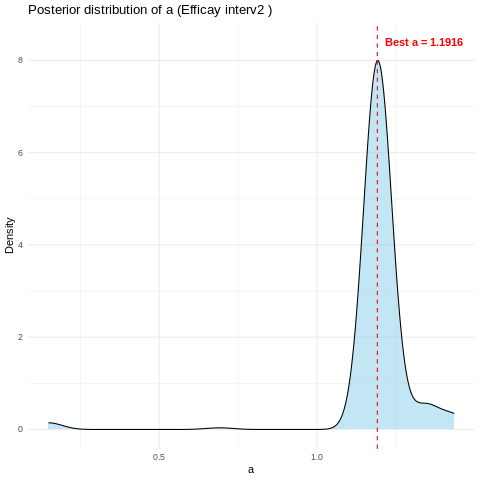

In [ ]:
%%R
posterior_df <- data.frame(a = posterior_a)
ggplot(posterior_df, aes(x = a)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", size = 1) +
  geom_vline(xintercept = best_a, linetype = "dashed", color = "red") +
  labs(title = paste("Posterior for a —", target_campaign_name), x = "a", y = "Density") +
  theme_minimal()

cat("Best a estimate (", target_campaign_name, "):", signif(best_a, 5), "\n")
cat("95% credible interval for a:\n"); print(quantile(posterior_a, probs = c(0.025,0.5,0.975)))



 # Ensure posterior_df is numeric
if (is.data.frame(posterior_df)) {
  posterior_vec <- posterior_df$a
} else {
  posterior_vec <- as.numeric(posterior_df)
}

# Calculate best a (posterior median)
a_best <- median(posterior_vec, na.rm = TRUE)

# Prepare data frame for plotting
df_post <- data.frame(a = posterior_vec)

# Plot
ggplot(df_post, aes(x = a)) +
  geom_density(fill = "skyblue", alpha = 0.5) +
  geom_vline(xintercept = a_best, color = "red", linetype = "dashed") +
  annotate(
    "text",
    x = a_best,
    y = max(density(df_post$a)$y) * 1.05,
    label = paste0("Best a = ", round(a_best, 4)),
    color = "red", fontface = "bold", hjust = -0.1
  ) +
  labs(
    title = paste("Posterior distribution of a (Efficay", target_campaign_name, ")"),
    x = "a", y = "Density"
  ) +
  theme_minimal()


# Third Intervention

In [ ]:
%%R
library(tidyverse)
library(ggplot2)

# fixed params (same)
Lambda <- 1.0182e7; alpha <- 0.0019166; mu <- 9.125
lambda <- 5.9869e5; beta <- 4.761e-9; delta <- 0.00645; gamma <- 0.20064
k <- 3; d <- 0.0336
sigma1 <- 0.64; sigma2 <- 0.46; sigma3 <- 0.15; sigma4 <- 0.21; sigma5 <- 0.32

TT <- 13; dt <- 1/120
time <- round(seq(0, TT, by = dt), 5)
N <- length(time) - 1

f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

IRScampaigns <- list(
  interv1 = c(t = 7.25, a = 0.322, k = 2),
  interv2 = c(t = 8.25, a = 1.1916 , k = 2),
  interv3 = c(t = 9.25, a = 1, k = 2)
)

vc_exp_decay <- function(i, time, a_vec, interv = IRScampaigns) {
  if (i == 0) return(0)
  cn <- names(interv)
  a_here <- a_vec[cn]
  contrib <- mapply(function(x, a_val) {
    a_val * exp(-x["k"] * pmax(0, time[i] - x["t"]))
  }, interv, a_here, SIMPLIFY = TRUE)
  contrib <- contrib * (time[i] > sapply(interv, function(x) x["t"]))
  sum(contrib)
}

Sv0 <- 4.5e6; Iv0 <- 4.7e3; Sh0 <- 4.4e7; Ih0 <- 1.3144e4; Rh0 <- 1e4

a_range <- c(0.0, 1.5); n_particles <- 10; n_iter <- 25; n_reps <- 20
prior_sample_a <- function(n) data.frame(a = runif(n, a_range[1], a_range[2]))

compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time")
  if (nrow(common) == 0) return(-Inf)
  -sum((common$prev_h_mean - common$prevalence_under5)^2, na.rm = TRUE)
}

target_campaign_name <- "interv3"
fixed_a_vec <- c(interv1 = 0.322, interv2 =1.1916 , interv3 = NA)

particles <- prior_sample_a(n_particles)
posterior_a <- numeric(0)
best_likelihood <- -Inf
best_a <- NA
df_best_all <- NULL
best_replicates <- NULL

set.seed(123)
for (iter in 1:n_iter) {
  message("SMC iteration: ", iter)
  likelihoods <- numeric(n_particles)
  for (p in 1:n_particles) {
    a_p <- particles$a[p]
    a_vec <- fixed_a_vec
    a_vec[target_campaign_name] <- a_p
    names(a_vec) <- names(IRScampaigns)

    rep_out <- vector("list", n_reps)
    for (rep in 1:n_reps) {
      Sv <- numeric(length(time)); Iv <- numeric(length(time))
      Sh <- numeric(length(time)); Ih <- numeric(length(time)); Rh <- numeric(length(time))
      Sv[1] <- Sv0; Iv[1] <- Iv0; Sh[1] <- Sh0; Ih[1] <- Ih0; Rh[1] <- Rh0

      for (i in 1:(length(time)-1)) {
        dB <- rnorm(5, mean=0, sd = sqrt(dt)); dB2 <- dB^2 - dt
        mu_vc_i <- mu + mu * vc_exp_decay(i, time, a_vec)

        Sv[i+1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
                   sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

        Iv[i+1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
                   sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

        Sh[i+1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                   sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

        Ih[i+1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
                   sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

        Rh[i+1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
                   sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]
      } # end time

      rep_out[[rep]] <- data.frame(time = time, Sv = Sv, Iv = Iv, Sh = Sh, Ih = Ih, Rh = Rh, replicate = rep)
    } # end reps

    all_data <- bind_rows(rep_out)
    df_sim <- all_data %>%
      group_by(time) %>%
      summarise(prev_h_mean = mean(ifelse((Sh + Ih + Rh) > 0, 500 * Ih / (Sh + Ih + Rh), NA), na.rm = TRUE), .groups = "drop")

    likelihoods[p] <- compute_likelihood(df_sim, df_prev)
    if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
      best_likelihood <- likelihoods[p]
      best_a <- a_p
      df_best_all <- df_sim
      best_replicates <- all_data
    }
  } # end particles

  w <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
  if (all(is.na(w)) || sum(w, na.rm=TRUE) == 0) w <- rep(1/n_particles, n_particles) else w <- w / sum(w, na.rm=TRUE)
  idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = w)
  particles <- particles[idx, , drop = FALSE]
  posterior_a <- c(posterior_a, particles$a)
}

# Plot + posterior
df_reps <- best_replicates %>% mutate(N_h = Sh + Ih + Rh, prev_h = ifelse(N_h>0, 500*Ih/N_h, NA))
df_prev_shifted <- df_prev %>% mutate(time = time + 5)

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.4) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", size = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x["t"]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year (sim time)") +
  labs(title = paste0("SMC fit — estimated a for ", target_campaign_name), y = "Prevalence") +
  theme_minimal()

posterior_df <- data.frame(a = posterior_a)
ggplot(posterior_df, aes(x = a)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", size = 1) +
  geom_vline(xintercept = best_a, linetype = "dashed", color = "red") +
  labs(title = paste("Posterior for a —", target_campaign_name), x = "a", y = "Density") +
  theme_minimal()

cat("Best a estimate (", target_campaign_name, "):", signif(best_a, 5), "\n")
cat("95% credible interval for a:\n"); print(quantile(posterior_a, probs = c(0.025,0.5,0.975)))


Best a estimate ( interv3 ): 1.1916 
95% credible interval for a:
    2.5%      50%    97.5% 
1.191618 1.191618 1.435400 


SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25


Best a estimate ( interv3 ): 1.1916 
95% credible interval for a:
    2.5%      50%    97.5% 
1.191618 1.191618 1.435400 


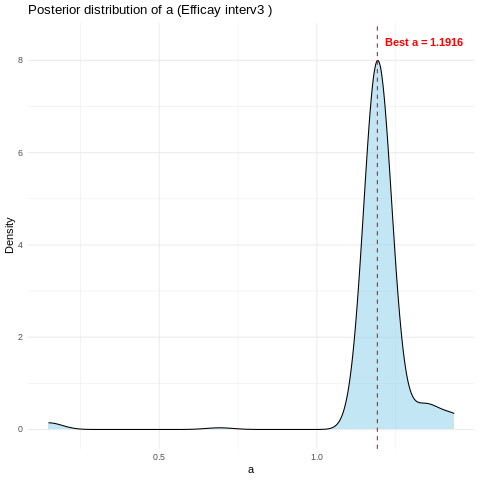

In [ ]:
%%R


posterior_df <- data.frame(a = posterior_a)
ggplot(posterior_df, aes(x = a)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", size = 1) +
  geom_vline(xintercept = best_a, linetype = "dashed", color = "red") +
  labs(title = paste("Posterior for a —", target_campaign_name), x = "a", y = "Density") +
  theme_minimal()

cat("Best a estimate (", target_campaign_name, "):", signif(best_a, 5), "\n")
cat("95% credible interval for a:\n"); print(quantile(posterior_a, probs = c(0.025,0.5,0.975)))





 # Ensure posterior_df is numeric
if (is.data.frame(posterior_df)) {
  posterior_vec <- posterior_df$a
} else {
  posterior_vec <- as.numeric(posterior_df)
}

# Calculate best a (posterior median)
a_best <- median(posterior_vec, na.rm = TRUE)

# Prepare data frame for plotting
df_post <- data.frame(a = posterior_vec)

# Plot
ggplot(df_post, aes(x = a)) +
  geom_density(fill = "skyblue", alpha = 0.5) +
  geom_vline(xintercept = a_best, color = "red", linetype = "dashed") +
  annotate(
    "text",
    x = a_best,
    y = max(density(df_post$a)$y) * 1.05,
    label = paste0("Best a = ", round(a_best, 4)),
    color = "red", fontface = "bold", hjust = -0.1
  ) +
  labs(
    title = paste("Posterior distribution of a (Efficay", target_campaign_name, ")"),
    x = "a", y = "Density"
  ) +
  theme_minimal()


In [ ]:
%%R
# =============================================================
# Function: SMC estimation for one IRS campaign (your workflow)
# =============================================================
estimate_a_campaign <- function(target_campaign_name, fixed_a_vec) {
  particles <- prior_sample_a(n_particles)
  weights <- rep(1 / n_particles, n_particles)
  posterior_a <- numeric(0)
  best_likelihood <- -Inf
  best_a <- NA
  df_best_all <- NULL
  best_replicates <- NULL

  set.seed(123)
  for (iter in 1:n_iter) {
    message("SMC iteration: ", iter)
    likelihoods <- numeric(n_particles)

    for (p in 1:n_particles) {
      a_p <- particles$a[p]
      # build a_vec for this particle (named)
      a_vec <- fixed_a_vec
      a_vec[target_campaign_name] <- a_p
      names(a_vec) <- names(IRScampaigns)

      # collect replicates
      rep_out <- vector("list", n_reps)

      for (rep in 1:n_reps) {
        # initial vectors
        Sv <- numeric(length(time)); Iv <- numeric(length(time))
        Sh <- numeric(length(time)); Ih <- numeric(length(time)); Rh <- numeric(length(time))
        Sv[1] <- Sv0; Iv[1] <- Iv0
        Sh[1] <- Sh0; Ih[1] <- Ih0; Rh[1] <- Rh0

        # Milstein loop
        for (i in 1:(length(time)-1)) {
          dB <- rnorm(5, mean = 0, sd = sqrt(dt))
          dB2 <- dB^2 - dt
          mu_vc_i <- mu + mu * vc_exp_decay(i, time, a_vec)

          Sv[i+1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
                     sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

          Iv[i+1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
                     sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

          Sh[i+1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                     sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

          Ih[i+1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
                     sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

          Rh[i+1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
                     sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]
        }

        rep_out[[rep]] <- data.frame(time = time,
                                     Sv = Sv, Iv = Iv,
                                     Sh = Sh, Ih = Ih, Rh = Rh,
                                     replicate = rep)
      }

      all_data <- bind_rows(rep_out)

      df_sim <- all_data %>%
        group_by(time) %>%
        summarise(prev_h_mean = mean(ifelse((Sh + Ih + Rh) > 0, 500 * Ih / (Sh + Ih + Rh), NA), na.rm = TRUE),
                  .groups = "drop")

      likelihoods[p] <- compute_likelihood(df_sim, df_prev)

      if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
        best_likelihood <- likelihoods[p]
        best_a <- a_p
        df_best_all <- df_sim
        best_replicates <- all_data
      }
    }

    w <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
    if (all(is.na(w)) || sum(w, na.rm = TRUE) == 0) w <- rep(1/n_particles, n_particles) else w <- w / sum(w, na.rm = TRUE)
    idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = w)
    particles <- particles[idx, , drop = FALSE]
    posterior_a <- c(posterior_a, particles$a)
  }

  list(best_a = best_a, posterior_a = posterior_a,
       df_best_all = df_best_all, best_replicates = best_replicates)
}

# =============================================================
# Sequential estimation for all campaigns
# =============================================================
# Step 1: interv1
res1 <- estimate_a_campaign("interv1", c(interv1 = NA, interv2 = 1, interv3 = 1))
a1 <- res1$best_a
cat("Best a for interv1:", a1, "\n")

# Step 2: interv2 (fix a1)
res2 <- estimate_a_campaign("interv2", c(interv1 = a1, interv2 = NA, interv3 = 1))
a2 <- res2$best_a
cat("Best a for interv2:", a2, "\n")

# Step 3: interv3 (fix a1 and a2)
res3 <- estimate_a_campaign("interv3", c(interv1 = a1, interv2 = a2, interv3 = NA))
a3 <- res3$best_a
cat("Best a for interv3:", a3, "\n")

# =============================================================
# Final results
# =============================================================
final_results <- data.frame(intervention = c("interv1", "interv2", "interv3"),
                            best_a = c(a1, a2, a3))
print(final_results)



Best a for interv1: 0.4487118 
Best a for interv2: 1.191618 
Best a for interv3: 1.191618 
  intervention    best_a
1      interv1 0.4487118
2      interv2 1.1916185
3      interv3 1.1916185


SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25
SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25
SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7

Best a estimate ( interv1 ): 0.38163 
95% credible interval for a:
    2.5%      50%    97.5% 
0.381627 0.381627 1.222127 


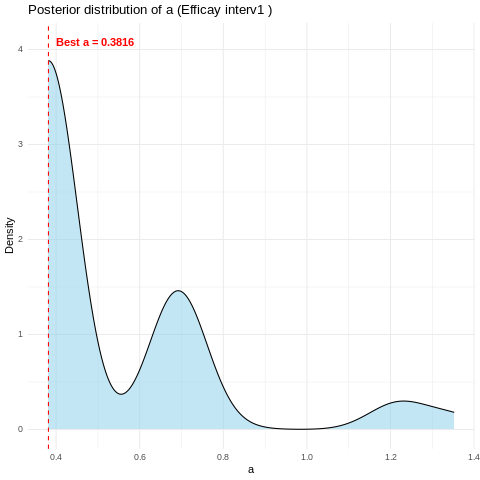

# Running 150 particles ($\alpha$ Estimation)

In [ ]:
%%R
library(tidyverse)
library(ggplot2)

# SMC settings
alpha_range <- c(1e-4, 2e-3)
n_particles <- 150
n_iter <- 25
n_reps <- 20

# Prior sampler for alpha
prior_sample_alpha <- function(n) {
  data.frame(alpha = runif(n, alpha_range[1], alpha_range[2]))
}

# Likelihood function using squared error on time window [1, 2.25]
compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time") %>% filter(time >= 1, time <= 2.25)
  error <- common$prev_h_mean - common$prevalence_under5
  -sum(error^2, na.rm = TRUE)
}

# Initialize
particles <- prior_sample_alpha(n_particles)
weights <- rep(1 / n_particles, n_particles)
df_best_all <- NULL
best_likelihood <- -Inf
best_alpha <- NULL
posterior_alpha <- NULL
best_replicates <- NULL

set.seed(123)
for (iter in 1:n_iter) {
  message("SMC iteration: ", iter)
  likelihoods <- numeric(n_particles)

  for (p in 1:n_particles) {
    alpha <- particles$alpha[p]
    results <- list()

    for (rep in 1:n_reps) {
      Sv <- numeric(length(time)); Iv <- numeric(length(time))
      Sh <- numeric(length(time)); Ih <- numeric(length(time))
      Rh <- numeric(length(time)); Nh <- numeric(length(time))

      Sv[1] <- Sv0; Iv[1] <- Iv0
      Sh[1] <- Sh0; Ih[1] <- Ih0
      Rh[1] <- Rh0; Nh[1] <- Sh[1] + Ih[1] + Rh[1]

      for (i in 1:N) {
        dB <- rnorm(5, mean = 0, sd = sqrt(dt))
        dB2 <- dB^2 - dt

        Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Sv[i]) * dt +
                     sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

        Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Iv[i]) * dt +
                     sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

        Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                     sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

        Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i] - f_treat(i) * Ih[i]) * dt +
                     sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

        Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i] + f_treat(i) * Ih[i]) * dt +
                     sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

        Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
      }

      df <- data.frame(
        time = rep(time, 5),
        value = c(Sv, Iv, Sh, Ih, Rh),
        variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
        replicate = rep(rep, length(time) * 5)
      )
      results[[rep]] <- df
    }

    all_data <- bind_rows(results)

    df_sim <- all_data %>%
      pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
      mutate(N_h = S_h + I_h + R_h,
             prev_h = I_h / N_h) %>%
      group_by(time) %>%
      summarise(prev_h_mean = mean(500 * prev_h), .groups = "drop")

    likelihoods[p] <- compute_likelihood(df_sim, df_prev)

    if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
      best_likelihood <- likelihoods[p]
      best_alpha <- alpha
      df_best_all <- df_sim
      best_replicates <- all_data
    }
  }

  weights <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
  weights <- weights / sum(weights)
  resample_idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = weights)
  particles <- particles[resample_idx, , drop = FALSE]
  posterior_alpha <- c(posterior_alpha, particles$alpha)
}

# ▶ Plot best fit
df_reps <- best_replicates %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h)

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Estimating Alpha, Beta Fixed)", x = "Time", y = "Prevalence") +
  theme_minimal()

# ▶ Plot posterior
posterior_df <- data.frame(alpha = posterior_alpha)
ggplot(posterior_df, aes(x = alpha)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", linewidth = 1.2) +
  geom_vline(xintercept = best_alpha, linetype = "dashed", color = "red") +
  annotate("text", x = best_alpha, y = Inf, label = paste("Best alpha:", signif(best_alpha, 5)),
           hjust = 1.1, vjust = 2, color = "red", size = 3.5) +
  labs(title = "Posterior Distribution of Alpha",
       x = expression(alpha),
       y = "Density") +
  theme_minimal()

# ▶ Print results
cat("Best alpha estimate:", signif(best_alpha, 5), "\n")
cat("95% credible interval for alpha:\n")
print(quantile(posterior_alpha, probs = c(0.025, 0.5, 0.975)))


Best alpha estimate: 0.0019841 
95% credible interval for alpha:
        2.5%          50%        97.5% 
0.0005354732 0.0015066145 0.0019573409 


SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25


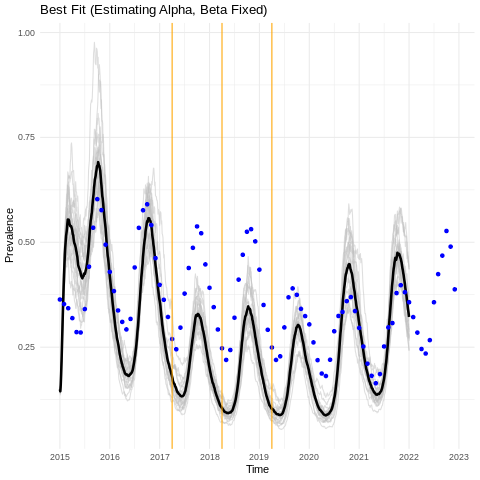

In [ ]:
%%R

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Estimating Alpha, Beta Fixed)", x = "Time", y = "Prevalence") +
  theme_minimal()

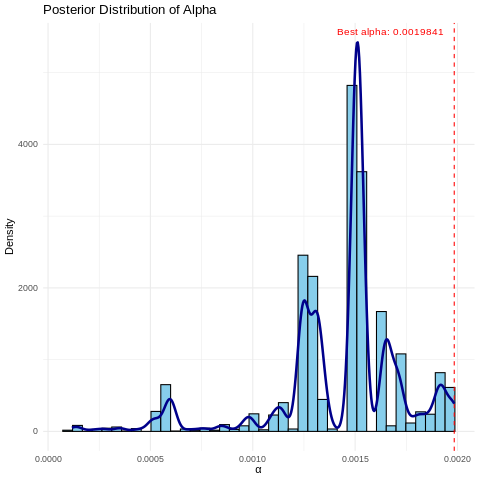

In [ ]:
%%R

# ▶ Plot posterior
posterior_df <- data.frame(alpha = posterior_alpha)
ggplot(posterior_df, aes(x = alpha)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", linewidth = 1.2) +
  geom_vline(xintercept = best_alpha, linetype = "dashed", color = "red") +
  annotate("text", x = best_alpha, y = Inf, label = paste("Best alpha:", signif(best_alpha, 5)),
           hjust = 1.1, vjust = 2, color = "red", size = 3.5) +
  labs(title = "Posterior Distribution of Alpha",
       x = expression(alpha),
       y = "Density") +
  theme_minimal()

# Running 100 Particles ($\alpha$ Estimation)

In [ ]:
%%R
library(tidyverse)
library(ggplot2)

# SMC settings
alpha_range <- c(1e-4, 2e-3)
n_particles <- 100
n_iter <- 25
n_reps <- 20

# Prior sampler for alpha
prior_sample_alpha <- function(n) {
  data.frame(alpha = runif(n, alpha_range[1], alpha_range[2]))
}

# Likelihood function using squared error on time window [1, 2.25]
compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time") %>% filter(time >= 1, time <= 2.25)
  error <- common$prev_h_mean - common$prevalence_under5
  -sum(error^2, na.rm = TRUE)
}

# Initialize
particles <- prior_sample_alpha(n_particles)
weights <- rep(1 / n_particles, n_particles)
df_best_all <- NULL
best_likelihood <- -Inf
best_alpha <- NULL
posterior_alpha <- NULL
best_replicates <- NULL

set.seed(123)
for (iter in 1:n_iter) {
  message("SMC iteration: ", iter)
  likelihoods <- numeric(n_particles)

  for (p in 1:n_particles) {
    alpha <- particles$alpha[p]
    results <- list()

    for (rep in 1:n_reps) {
      Sv <- numeric(length(time)); Iv <- numeric(length(time))
      Sh <- numeric(length(time)); Ih <- numeric(length(time))
      Rh <- numeric(length(time)); Nh <- numeric(length(time))

      Sv[1] <- Sv0; Iv[1] <- Iv0
      Sh[1] <- Sh0; Ih[1] <- Ih0
      Rh[1] <- Rh0; Nh[1] <- Sh[1] + Ih[1] + Rh[1]

      for (i in 1:N) {
        dB <- rnorm(5, mean = 0, sd = sqrt(dt))
        dB2 <- dB^2 - dt

        Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Sv[i]) * dt +
                     sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

        Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Iv[i]) * dt +
                     sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

        Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                     sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

        Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i] - f_treat(i) * Ih[i]) * dt +
                     sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

        Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i] + f_treat(i) * Ih[i]) * dt +
                     sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

        Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
      }

      df <- data.frame(
        time = rep(time, 5),
        value = c(Sv, Iv, Sh, Ih, Rh),
        variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
        replicate = rep(rep, length(time) * 5)
      )
      results[[rep]] <- df
    }

    all_data <- bind_rows(results)

    df_sim <- all_data %>%
      pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
      mutate(N_h = S_h + I_h + R_h,
             prev_h = I_h / N_h) %>%
      group_by(time) %>%
      summarise(prev_h_mean = mean(500 * prev_h), .groups = "drop")

    likelihoods[p] <- compute_likelihood(df_sim, df_prev)

    if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
      best_likelihood <- likelihoods[p]
      best_alpha <- alpha
      df_best_all <- df_sim
      best_replicates <- all_data
    }
  }

  weights <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
  weights <- weights / sum(weights)
  resample_idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = weights)
  particles <- particles[resample_idx, , drop = FALSE]
  posterior_alpha <- c(posterior_alpha, particles$alpha)
}

# ▶ Plot best fit
df_reps <- best_replicates %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h)

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Estimating Alpha, Beta Fixed)", x = "Time", y = "Prevalence") +
  theme_minimal()

# ▶ Plot posterior
posterior_df <- data.frame(alpha = posterior_alpha)
ggplot(posterior_df, aes(x = alpha)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", linewidth = 1.2) +
  geom_vline(xintercept = best_alpha, linetype = "dashed", color = "red") +
  annotate("text", x = best_alpha, y = Inf, label = paste("Best alpha:", signif(best_alpha, 5)),
           hjust = 1.1, vjust = 2, color = "red", size = 3.5) +
  labs(title = "Posterior Distribution of Alpha",
       x = expression(alpha),
       y = "Density") +
  theme_minimal()

# ▶ Print results
cat("Best alpha estimate:", signif(best_alpha, 5), "\n")
cat("95% credible interval for alpha:\n")
print(quantile(posterior_alpha, probs = c(0.025, 0.5, 0.975)))


[1] 2.897112
[1] TRUE
Best alpha estimate: 0.0012639 
95% credible interval for alpha:
        2.5%          50%        97.5% 
0.0006573856 0.0016356621 0.0018755644 


SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25


In [ ]:
%%R
library(tidyverse)
library(ggplot2)

alpha_range <- c(1e-4, 2e-3)
n_particles <- 100
n_iter <- 25
n_reps <- 20

prior_sample_alpha <- function(n) {
  data.frame(alpha = runif(n, alpha_range[1], alpha_range[2]))
}

compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time") %>% filter(time >= 6, time <= 7.25)
  error <- common$prev_h_mean - common$prevalence_under5
  -sum(error^2, na.rm = TRUE)
}

particles <- prior_sample_alpha(n_particles)
weights <- rep(1 / n_particles, n_particles)
df_best_all <- NULL
best_likelihood <- -Inf
best_alpha <- NULL
posterior_alpha <- NULL
best_replicates <- NULL

set.seed(123)
for (iter in 1:n_iter) {
  message("SMC iteration: ", iter)
  likelihoods <- numeric(n_particles)

  for (p in 1:n_particles) {
    alpha <- particles$alpha[p]
    results <- list()

    for (rep in 1:n_reps) {
      Sv <- numeric(length(time)); Iv <- numeric(length(time))
      Sh <- numeric(length(time)); Ih <- numeric(length(time))
      Rh <- numeric(length(time)); Nh <- numeric(length(time))

      Sv[1] <- Sv0; Iv[1] <- Iv0
      Sh[1] <- Sh0; Ih[1] <- Ih0
      Rh[1] <- Rh0; Nh[1] <- Sh[1] + Ih[1] + Rh[1]

      for (i in 1:N) {
        dB <- rnorm(5, mean = 0, sd = sqrt(dt))
        dB2 <- dB^2 - dt
        mu_vc_i <- mu + mu * vc_exp_decay(i, time, IRScampaigns)

        Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
                     sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

        Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
                     sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

        Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                     sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

        Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i] - f_treat(i) * Ih[i]) * dt +
                     sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

        Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i] + f_treat(i) * Ih[i]) * dt +
                     sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

        Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
      }

      df <- data.frame(
        time = rep(time, 5),
        value = c(Sv, Iv, Sh, Ih, Rh),
        variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
        replicate = rep(rep, length(time) * 5)
      )
      results[[rep]] <- df
    }

    all_data <- bind_rows(results)

    df_sim <- all_data %>%
      pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
      mutate(N_h = S_h + I_h + R_h,
             prev_h = I_h / N_h) %>%
      group_by(time) %>%
      summarise(prev_h_mean = mean(500 * prev_h), .groups = "drop")

    likelihoods[p] <- compute_likelihood(df_sim, df_prev)

    if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
      best_likelihood <- likelihoods[p]
      best_alpha <- alpha
      df_best_all <- df_sim
      best_replicates <- all_data
    }
  }

  weights <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
  weights <- weights / sum(weights)
  resample_idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = weights)
  particles <- particles[resample_idx, , drop = FALSE]
  posterior_alpha <- c(posterior_alpha, particles$alpha)
}

df_reps <- best_replicates %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h)

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.4) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:13, labels = 2010:2023) +
  labs(title = "SMC Fit: Simulated Starts 2010, Observed From 2015", y = "Prevalence") +
  theme_minimal()

posterior_df <- data.frame(alpha = posterior_alpha)
ggplot(posterior_df, aes(x = alpha)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", linewidth = 1.2) +
  geom_vline(xintercept = best_alpha, linetype = "dashed", color = "red") +
  annotate("text", x = best_alpha, y = Inf, label = paste("Best alpha:", signif(best_alpha, 5)),
           hjust = 1.1, vjust = 2, color = "red", size = 3.5) +
  labs(title = "Posterior Distribution of Alpha", x = expression(alpha), y = "Density") +
  theme_minimal()

cat("Best alpha estimate:", signif(best_alpha, 5), "\n")
cat("95% credible interval for alpha:\n")
print(quantile(posterior_alpha, probs = c(0.025, 0.5, 0.975)))


SMC iteration: 1
Error in Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) *  : 
  replacement has length zero


RInterpreterError: Failed to parse and evaluate line 'library(tidyverse)\nlibrary(ggplot2)\n\nalpha_range <- c(1e-4, 2e-3)\nn_particles <- 100\nn_iter <- 25\nn_reps <- 20\n\nprior_sample_alpha <- function(n) {\n  data.frame(alpha = runif(n, alpha_range[1], alpha_range[2]))\n}\n\ncompute_likelihood <- function(sim_prev, obs_prev) {\n  common <- inner_join(sim_prev, obs_prev, by = "time") %>% filter(time >= 6, time <= 7.25)\n  error <- common$prev_h_mean - common$prevalence_under5\n  -sum(error^2, na.rm = TRUE)\n}\n\nparticles <- prior_sample_alpha(n_particles)\nweights <- rep(1 / n_particles, n_particles)\ndf_best_all <- NULL\nbest_likelihood <- -Inf\nbest_alpha <- NULL\nposterior_alpha <- NULL\nbest_replicates <- NULL\n\nset.seed(123)\nfor (iter in 1:n_iter) {\n  message("SMC iteration: ", iter)\n  likelihoods <- numeric(n_particles)\n\n  for (p in 1:n_particles) {\n    alpha <- particles$alpha[p]\n    results <- list()\n\n    for (rep in 1:n_reps) {\n      Sv <- numeric(length(time));

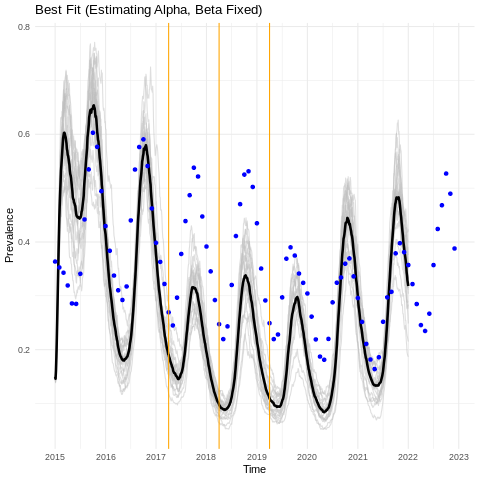

In [ ]:
%%R

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Estimating Alpha, Beta Fixed)", x = "Time", y = "Prevalence") +
  theme_minimal()


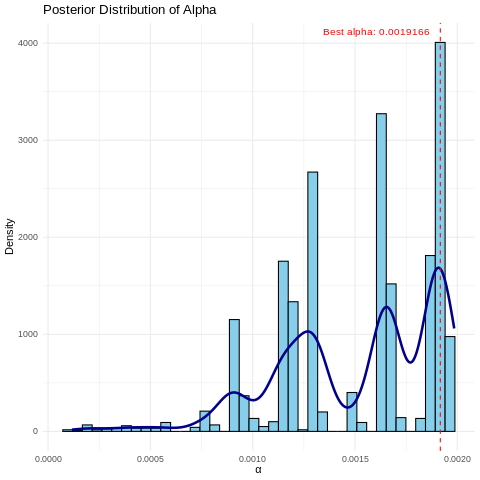

In [ ]:
%%R
# ▶ Plot posterior
posterior_df <- data.frame(alpha = posterior_alpha)
ggplot(posterior_df, aes(x = alpha)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", linewidth = 1.2) +
  geom_vline(xintercept = best_alpha, linetype = "dashed", color = "red") +
  annotate("text", x = best_alpha, y = Inf, label = paste("Best alpha:", signif(best_alpha, 5)),
           hjust = 1.1, vjust = 2, color = "red", size = 3.5) +
  labs(title = "Posterior Distribution of Alpha",
       x = expression(alpha),
       y = "Density") +
  theme_minimal()

In [ ]:
%%R
library(tidyverse)
library(ggplot2)

# ========== PARAMETERS (unchanged) ==========
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

Lambda <- 1.0182e7
mu <- 9.125
lambda <- 5.9869e5
beta <- 4.761e-9
delta <- 0.00645
gamma <- 0.20064
k <- 3
d <- 0.0336

sigma1 <- 0.64
sigma2 <- 0.46
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

# placeholder alpha for R0 calculation
#alpha <- 1.3499e-3

R0 <- sqrt(Lambda * lambda * alpha * beta /
  ((mu + sigma1^2 / 2) * (mu + sigma2^2 / 2) *
   (delta + sigma3^2 / 2) * (delta + k + d + sigma4^2 / 2)))
print(R0)
print(min(mu, delta) < 0.5 * max(sigma1^2, sigma2^2, sigma3^2, sigma4^2, sigma5^2))

TT <- 13
dt <- 1 / 120
N <- TT / dt
time <- round(seq(0, TT, by = dt), 5)

IRScampaigns <- list(
  "interv1" = c(t = 7.25, a = 1,   k = 2),
  "interv2" = c(t = 8.25, a = 0.4, k = 2),
  "interv3" = c(t = 9.25, a = 0.8, k = 2)
)

vc_exp_decay <- function(i, time, interv = IRScampaigns) {
  if (i == 0) return(0)
  df <- sapply(interv, function(x) {
    x[2] * exp(-x[3] * pmax(0, time[i] - time[which(time == x[1])]))
  })
  df <- df * (time[i] > sapply(interv, function(y) y[1]))
  sum(df)
}

# ========== INITIAL CONDITIONS ==========
Sv0 <- 4.5e6
Iv0 <- 4.7e3
Sh0 <- 4.4e7
Ih0 <- 1.3144e4
Rh0 <- 1e4

# ========== SMC PARAMETERS ==========
alpha_range <- c(1e-4, 2e-3)
n_particles <- 50
n_iter <- 25
n_reps <- 20

prior_sample_alpha <- function(n) {
  data.frame(alpha = runif(n, alpha_range[1], alpha_range[2]))
}

compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time") %>%
    filter(time >= 5, time <= 13)
  error <- common$prev_h_mean - common$prevalence_under5
  -sum(error^2, na.rm = TRUE)
}

# ========== SMC LOOP ==========
particles <- prior_sample_alpha(n_particles)
weights <- rep(1 / n_particles, n_particles)
df_best_all <- NULL
best_likelihood <- -Inf
best_alpha <- NULL
posterior_alpha <- NULL
best_replicates <- NULL

set.seed(123)
for (iter in 1:n_iter) {
  message("SMC iteration: ", iter)
  likelihoods <- numeric(n_particles)

  for (p in 1:n_particles) {
    alpha <- particles$alpha[p]
    results <- list()

    for (rep in 1:n_reps) {
      Sv <- Iv <- Sh <- Ih <- Rh <- Nh <- numeric(length(time))
      Sv[1] <- Sv0; Iv[1] <- Iv0
      Sh[1] <- Sh0; Ih[1] <- Ih0
      Rh[1] <- Rh0; Nh[1] <- Sh[1] + Ih[1] + Rh[1]

      for (i in 1:N) {
        dB <- rnorm(5, mean = 0, sd = sqrt(dt))
        dB2 <- dB^2 - dt
        mu_vc_i <- mu + mu * vc_exp_decay(i, time)

        Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
                     sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]
        Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
                     sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]
        Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                     sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]
        Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i]) * dt +
                     sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]
        Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i]) * dt +
                     sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

        Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
      }

      df <- data.frame(
        time = rep(time, 5),
        value = c(Sv, Iv, Sh, Ih, Rh),
        variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
        replicate = rep(rep, length(time) * 5)
      )
      results[[rep]] <- df
    }

    all_data <- bind_rows(results)
    df_sim <- all_data %>%
      pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
      mutate(N_h = S_h + I_h + R_h,
             prev_h = I_h / N_h) %>%
      filter(!is.na(prev_h) & N_h > 0) %>%
      group_by(time) %>%
      summarise(prev_h_mean = mean(500 * prev_h, na.rm = TRUE), .groups = "drop")

    likelihoods[p] <- compute_likelihood(df_sim, df_prev)

    if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
      best_likelihood <- likelihoods[p]
      best_alpha <- alpha
      df_best_all <- df_sim
      best_replicates <- all_data
    }
  }

  weights <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
  weights <- weights / sum(weights)
  resample_idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = weights)
  particles <- particles[resample_idx, , drop = FALSE]
  posterior_alpha <- c(posterior_alpha, particles$alpha)
}

# ========== PLOTTING ==========
df_reps <- best_replicates %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h) %>%
  filter(!is.na(prev_h) & N_h > 0)

df_prev_shifted <- df_prev %>% mutate(time = time + 5)

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.4) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:13, labels = 2010:2023) +
  labs(title = "SMC Fit: Simulated From 2010, Observed From 2015", y = "Prevalence") +
  theme_minimal()

# ========== POSTERIOR PLOT ==========
posterior_df <- data.frame(alpha = posterior_alpha)
ggplot(posterior_df, aes(x = alpha)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", linewidth = 1.2) +
  geom_vline(xintercept = best_alpha, linetype = "dashed", color = "red") +
  annotate("text", x = best_alpha, y = Inf, label = paste("Best alpha:", signif(best_alpha, 5)),
           hjust = 1.1, vjust = 2, color = "red", size = 3.5) +
  labs(title = "Posterior Distribution of Alpha", x = expression(alpha), y = "Density") +
  theme_minimal()

# Print best estimate
cat("Best alpha estimate:", signif(best_alpha, 5), "\n")
cat("95% credible interval for alpha:\n")
print(quantile(posterior_alpha, probs = c(0.025, 0.5, 0.975)))



[1] 2.803287
[1] TRUE
Best alpha estimate: 0.0016031 
95% credible interval for alpha:
        2.5%          50%        97.5% 
0.0006238361 0.0016480273 0.0018584283 


SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25


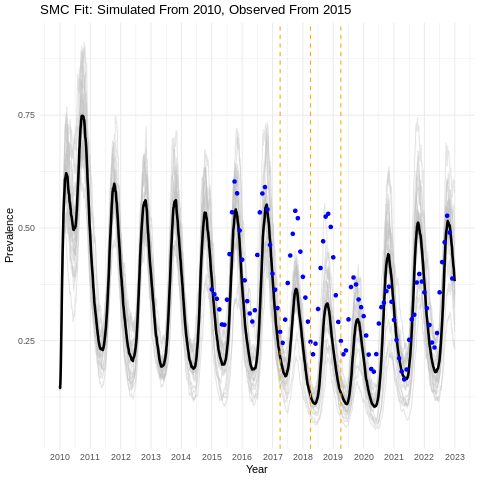

In [ ]:
%%R
ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.4) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev_shifted, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange", linetype = "dashed") +
  scale_x_continuous(name = "Year", breaks = 0:13, labels = 2010:2023) +
  labs(title = "SMC Fit: Simulated From 2010, Observed From 2015", y = "Prevalence") +
  theme_minimal()


# Beta Estimation

In [ ]:
%%R
library(tidyverse)
library(ggplot2)

# --- Settings ---
beta_range <- c(4.5e-9, 5.0e-9)  # Range for beta
fixed_alpha <- 1.3499e-3         # Alpha is fixed
n_particles <- 3
n_iter <- 30
n_reps <- 20

# Prior sampler for beta
prior_sample_beta <- function(n) {
  data.frame(beta = runif(n, beta_range[1], beta_range[2]))
}

# Likelihood function using squared error on time window [1, 2.25]
compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time") %>% filter(time >= 1, time <= 2.25)
  error <- common$prev_h_mean - common$prevalence_under5
  -sum(error^2, na.rm = TRUE)
}

# Initialize
particles <- prior_sample_beta(n_particles)
weights <- rep(1 / n_particles, n_particles)
df_best_all <- NULL
best_likelihood <- -Inf
best_beta <- NULL
posterior_beta <- NULL
best_replicates <- NULL

set.seed(123)
for (iter in 1:n_iter) {
  message("SMC iteration: ", iter)
  likelihoods <- numeric(n_particles)

  for (p in 1:n_particles) {
    beta <- particles$beta[p]
    results <- list()

    for (rep in 1:n_reps) {
      Sv <- numeric(length(time)); Iv <- numeric(length(time))
      Sh <- numeric(length(time)); Ih <- numeric(length(time))
      Rh <- numeric(length(time)); Nh <- numeric(length(time))

      Sv[1] <- Sv0; Iv[1] <- Iv0
      Sh[1] <- Sh0; Ih[1] <- Ih0
      Rh[1] <- Rh0; Nh[1] <- Sh[1] + Ih[1] + Rh[1]

      for (i in 1:N) {
        dB <- rnorm(5, mean = 0, sd = sqrt(dt))
        dB2 <- dB^2 - dt

        Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - fixed_alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Sv[i]) * dt +
                     sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

        Iv[i + 1] <- Iv[i] + (fixed_alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Iv[i]) * dt +
                     sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

        Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                     sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

        Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i] - f_treat(i) * Ih[i]) * dt +
                     sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

        Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i] + f_treat(i) * Ih[i]) * dt +
                     sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

        Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
      }

      df <- data.frame(
        time = rep(time, 5),
        value = c(Sv, Iv, Sh, Ih, Rh),
        variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
        replicate = rep(rep, length(time) * 5)
      )
      results[[rep]] <- df
    }

    all_data <- bind_rows(results)

    df_sim <- all_data %>%
      pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
      mutate(N_h = S_h + I_h + R_h,
             prev_h = I_h / N_h) %>%
      group_by(time) %>%
      summarise(prev_h_mean = mean(500 * prev_h), .groups = "drop")

    likelihoods[p] <- compute_likelihood(df_sim, df_prev)

    if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
      best_likelihood <- likelihoods[p]
      best_beta <- beta
      df_best_all <- df_sim
      best_replicates <- all_data
    }
  }

  weights <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
  weights <- weights / sum(weights)
  resample_idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = weights)
  particles <- particles[resample_idx, , drop = FALSE]
  posterior_beta <- c(posterior_beta, particles$beta)
}

# ▶ Plot best fit
df_reps <- best_replicates %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h)

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Estimating Beta, Alpha Fixed)", x = "Time", y = "Prevalence") +
  theme_minimal()

# ▶ Plot posterior
posterior_df <- data.frame(beta = posterior_beta)
ggplot(posterior_df, aes(x = beta)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", linewidth = 1.2) +
  geom_vline(xintercept = best_beta, linetype = "dashed", color = "red") +
  annotate("text", x = best_beta, y = Inf, label = paste("Best beta:", signif(best_beta, 5)),
           hjust = 1.1, vjust = 2, color = "red", size = 3.5) +
  labs(title = "Posterior Distribution of Beta",
       x = expression(beta),
       y = "Density") +
  theme_minimal()

# ▶ Print results
cat("Best beta estimate:", signif(best_beta, 5), "\n")
cat("95% credible interval for beta:\n")
print(quantile(posterior_beta, probs = c(0.025, 0.5, 0.975)))


Best beta estimate: 4.5951e-09 
95% credible interval for beta:
        2.5%          50%        97.5% 
4.587457e-09 4.595076e-09 4.595076e-09 


SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25
SMC iteration: 26
SMC iteration: 27
SMC iteration: 28
SMC iteration: 29
SMC iteration: 30


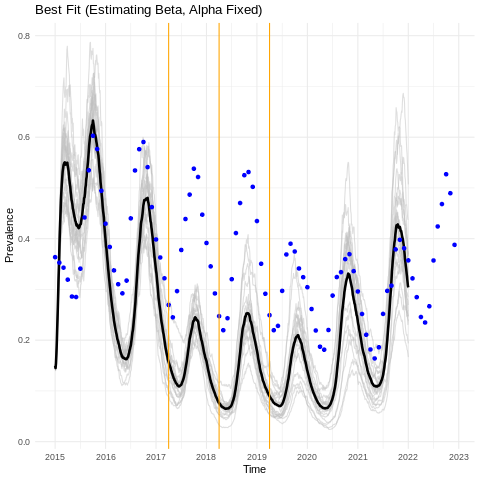

In [ ]:
%%R


ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Estimating Beta, Alpha Fixed)", x = "Time", y = "Prevalence") +
  theme_minimal()

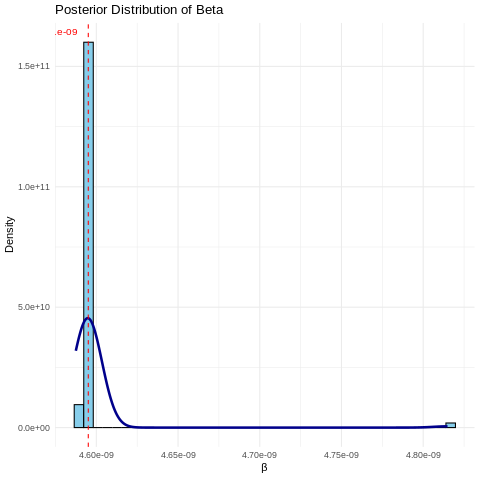

In [ ]:
%%R

# ▶ Plot posterior
posterior_df <- data.frame(beta = posterior_beta)
ggplot(posterior_df, aes(x = beta)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", linewidth = 1.2) +
  geom_vline(xintercept = best_beta, linetype = "dashed", color = "red") +
  annotate("text", x = best_beta, y = Inf, label = paste("Best beta:", signif(best_beta, 5)),
           hjust = 1.1, vjust = 2, color = "red", size = 3.5) +
  labs(title = "Posterior Distribution of Beta",
       x = expression(beta),
       y = "Density") +
  theme_minimal()

# Grid search Method

In [ ]:
%%R

library(tidyverse)
library(ggplot2)

# Grid settings
alpha_grid <- seq(1e-4, 2e-3, length.out = 50)  # 50 values in the range
n_reps <- 20

# Likelihood function (squared error)
compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time") %>% filter(time >= 1, time <= 2.25)
  error <- common$prev_h_mean - common$prevalence_under5
  -sum(error^2, na.rm = TRUE)
}

# Initialize
best_likelihood <- -Inf
best_alpha <- NULL
df_best_all <- NULL
best_replicates <- NULL
posterior_alpha <- numeric()

set.seed(123)
for (alpha in alpha_grid) {
  results <- list()

  for (rep in 1:n_reps) {
    Sv <- numeric(length(time)); Iv <- numeric(length(time))
    Sh <- numeric(length(time)); Ih <- numeric(length(time))
    Rh <- numeric(length(time)); Nh <- numeric(length(time))

    Sv[1] <- Sv0; Iv[1] <- Iv0
    Sh[1] <- Sh0; Ih[1] <- Ih0
    Rh[1] <- Rh0; Nh[1] <- Sh[1] + Ih[1] + Rh[1]

    for (i in 1:N) {
      dB <- rnorm(5, mean = 0, sd = sqrt(dt))
      dB2 <- dB^2 - dt

      Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Sv[i]) * dt +
                   sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

      Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Iv[i]) * dt +
                   sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

      Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                   sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

      Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i] - f_treat(i) * Ih[i]) * dt +
                   sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

      Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i] + f_treat(i) * Ih[i]) * dt +
                   sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

      Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
    }

    df <- data.frame(
      time = rep(time, 5),
      value = c(Sv, Iv, Sh, Ih, Rh),
      variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
      replicate = rep(rep, length(time) * 5)
    )
    results[[rep]] <- df
  }

  all_data <- bind_rows(results)

  df_sim <- all_data %>%
    pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
    mutate(N_h = S_h + I_h + R_h,
           prev_h = I_h / N_h) %>%
    group_by(time) %>%
    summarise(prev_h_mean = mean(500 * prev_h), .groups = "drop")

  likelihood <- compute_likelihood(df_sim, df_prev)

  if (!is.na(likelihood) && likelihood > best_likelihood) {
    best_likelihood <- likelihood
    best_alpha <- alpha
    df_best_all <- df_sim
    best_replicates <- all_data
  }

  posterior_alpha <- c(posterior_alpha, rep(alpha, n_reps))
}

# ▶ Plot best fit
df_reps <- best_replicates %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h)

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Grid Search for Alpha)", x = "Time", y = "Prevalence") +
  theme_minimal()

# ▶ Plot posterior
posterior_df <- data.frame(alpha = posterior_alpha)
ggplot(posterior_df, aes(x = alpha)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "skyblue", color = "black") +
  geom_density(color = "darkblue", linewidth = 1.2) +
  geom_vline(xintercept = best_alpha, linetype = "dashed", color = "red") +
  annotate("text", x = best_alpha, y = Inf, label = paste("Best alpha:", signif(best_alpha, 5)),
           hjust = 1.1, vjust = 2, color = "red", size = 3.5) +
  labs(title = "Posterior (Grid Search)", x = expression(alpha), y = "Density") +
  theme_minimal()

# ▶ Print results
cat("Best alpha estimate from Grid Search:", signif(best_alpha, 5), "\n")
print(quantile(posterior_alpha, probs = c(0.025, 0.5, 0.975)))


Best alpha estimate from Grid Search: 0.0019612 
        2.5%          50%        97.5% 
0.0001387755 0.0010500000 0.0019612245 


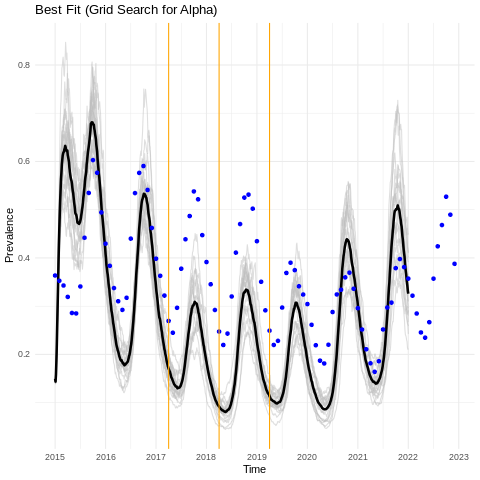

In [ ]:
%%R

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Grid Search for Alpha)", x = "Time", y = "Prevalence") +
  theme_minimal()

# **BAYESIAN OPTIMIZATION**

In [ ]:
%%R
# Install if not already installed
install.packages("rBayesianOptimization")
library(rBayesianOptimization)
library(tidyverse)
library(ggplot2)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘iterators’, ‘lhs’, ‘foreach’, ‘GPfit’

trying URL 'https://cran.rstudio.com/src/contrib/iterators_1.0.14.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/lhs_1.2.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/foreach_1.5.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/GPfit_1.0-9.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/rBayesianOptimization_1.2.1.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpJWLCQR/downloaded_packages’


In [ ]:
%%R
# Define the objective function for Bayesian Optimization
bayes_sim_alpha <- function(alpha) {
  n_reps <- 20
  results <- list()

  for (rep in 1:n_reps) {
    Sv <- numeric(length(time)); Iv <- numeric(length(time))
    Sh <- numeric(length(time)); Ih <- numeric(length(time))
    Rh <- numeric(length(time)); Nh <- numeric(length(time))

    Sv[1] <- Sv0; Iv[1] <- Iv0
    Sh[1] <- Sh0; Ih[1] <- Ih0
    Rh[1] <- Rh0; Nh[1] <- Sh[1] + Ih[1] + Rh[1]

    for (i in 1:N) {
      dB <- rnorm(5, mean = 0, sd = sqrt(dt))
      dB2 <- dB^2 - dt

      Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Sv[i]) * dt +
                   sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

      Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Iv[i]) * dt +
                   sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

      Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                   sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

      Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i] - f_treat(i) * Ih[i]) * dt +
                   sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

      Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i] + f_treat(i) * Ih[i]) * dt +
                   sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

      Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
    }

    df <- data.frame(
      time = rep(time, 5),
      value = c(Sv, Iv, Sh, Ih, Rh),
      variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
      replicate = rep(rep, length(time) * 5)
    )
    results[[rep]] <- df
  }

  all_data <- bind_rows(results)

  df_sim <- all_data %>%
    pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
    mutate(N_h = S_h + I_h + R_h,
           prev_h = I_h / N_h) %>%
    group_by(time) %>%
    summarise(prev_h_mean = mean(500 * prev_h), .groups = "drop")

  common <- inner_join(df_sim, df_prev, by = "time") %>% filter(time >= 1, time <= 2.25)
  error <- common$prev_h_mean - common$prevalence_under5
  score <- -sum(error^2, na.rm = TRUE)

  list(
    Score = score,
    Pred = score,
    df_sim = df_sim,
    all_data = all_data
  )
}


In [ ]:
%%R
set.seed(123)
opt_result <- BayesianOptimization(
  FUN = bayes_sim_alpha,
  bounds = list(alpha = c(1e-4, 2e-3)),
  init_points = 10,
  n_iter = 50,
  acq = "ucb",
  kappa = 2.576,
  verbose = TRUE
)


elapsed = 4.061	Round = 1	alpha = 0.0006463973	Value = -0.254399 
elapsed = 3.873	Round = 2	alpha = 0.00159778	Value = -0.09778643 
elapsed = 5.498	Round = 3	alpha = 0.0008770562	Value = -0.1750675 
elapsed = 3.918	Round = 4	alpha = 0.001777733	Value = -0.09535625 
elapsed = 3.912	Round = 5	alpha = 0.001886888	Value = -0.0896159 
elapsed = 5.351	Round = 6	alpha = 0.0001865573	Value = -0.823066 
elapsed = 3.816	Round = 7	alpha = 0.0011034	Value = -0.134702 
elapsed = 3.876	Round = 8	alpha = 0.001795596	Value = -0.08365042 
elapsed = 5.427	Round = 9	alpha = 0.001147727	Value = -0.1277541 
elapsed = 3.823	Round = 10	alpha = 0.000967568	Value = -0.1667506 
elapsed = 3.734	Round = 11	alpha = 0.001413354	Value = -0.1120257 
elapsed = 3.947	Round = 12	alpha = 0.001804404	Value = -0.09178891 
elapsed = 3.833	Round = 13	alpha = 0.001826206	Value = -0.09359045 
elapsed = 5.289	Round = 14	alpha = 0.001797388	Value = -0.08021927 
elapsed = 3.933	Round = 15	alpha = 0.001792493	Value = -0.08870085 


In [ ]:
%%R
best_alpha <- opt_result$Best_Par["alpha"]
best_sim <- bayes_sim_alpha(alpha = best_alpha)
df_best_all <- best_sim$df_sim
best_replicates <- best_sim$all_data

# ▶ Plot best fit
df_reps <- best_replicates %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h)

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Bayesian Optimization)", x = "Time", y = "Prevalence") +
  theme_minimal()

# ▶ Print results
cat("Best alpha estimate (Bayesian Optimization):", signif(best_alpha, 5), "\n")


Best alpha estimate (Bayesian Optimization): 0.0018855 


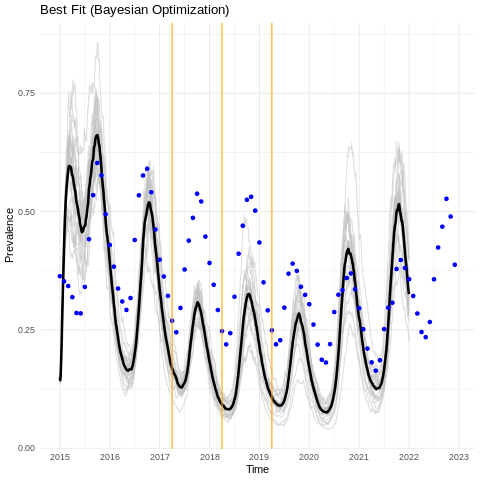

In [ ]:
%%R

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Bayesian Optimization)", x = "Time", y = "Prevalence") +
  theme_minimal()


# Both Parameters

In [ ]:
%%R

library(tidyverse)
library(ggplot2)

# Prior ranges
alpha_range <- c(1.2e-3, 1.5e-3)
beta_range  <- c(4.5e-9, 5.0e-9)

# SMC settings
n_particles <- 50
n_iter <- 25
n_reps <- 20

# Sample prior
prior_sample <- function(n) {
  data.frame(
    alpha = runif(n, alpha_range[1], alpha_range[2]),
    beta = runif(n, beta_range[1], beta_range[2])
  )
}

# Likelihood
compute_likelihood <- function(sim_prev, obs_prev) {
  common <- inner_join(sim_prev, obs_prev, by = "time") %>% filter(time >= 1, time <= 2.25)
  error <- common$prev_h_mean - common$prevalence_under5
  -sum(error^2, na.rm = TRUE)
}

# Initialization
particles <- prior_sample(n_particles)
weights <- rep(1 / n_particles, n_particles)
posterior_samples <- list()
best_likelihood <- -Inf
best_params <- NULL
df_best_all <- NULL
best_replicates <- NULL

set.seed(123)
for (iter in 1:n_iter) {
  message("SMC iteration: ", iter)
  likelihoods <- numeric(n_particles)

  for (p in 1:n_particles) {
    alpha <- particles$alpha[p]
    beta  <- particles$beta[p]
    results <- list()

    for (rep in 1:n_reps) {
      # Initialize vectors
      Sv <- numeric(length(time)); Iv <- numeric(length(time))
      Sh <- numeric(length(time)); Ih <- numeric(length(time))
      Rh <- numeric(length(time)); Nh <- numeric(length(time))

      Sv[1] <- Sv0; Iv[1] <- Iv0
      Sh[1] <- Sh0; Ih[1] <- Ih0
      Rh[1] <- Rh0; Nh[1] <- Sh[1] + Ih[1] + Rh[1]

      for (i in 1:N) {
        dB <- rnorm(5, mean = 0, sd = sqrt(dt))
        dB2 <- dB^2 - dt

        Sv[i + 1] <- Sv[i] + (f_period(i) * Lambda - alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Sv[i]) * dt +
                     sigma1 * Sv[i] * dB[1] + 0.5 * sigma1^2 * Sv[i] * dB2[1]

        Iv[i + 1] <- Iv[i] + (alpha * Sv[i] * Ih[i] - (mu + mu * vc_exp_decay(i, time, IRScampaigns)) * Iv[i]) * dt +
                     sigma2 * Iv[i] * dB[2] + 0.5 * sigma2^2 * Iv[i] * dB2[2]

        Sh[i + 1] <- Sh[i] + (lambda - beta * Sh[i] * Iv[i] - delta * Sh[i] + gamma * Rh[i]) * dt +
                     sigma3 * Sh[i] * dB[3] + 0.5 * sigma3^2 * Sh[i] * dB2[3]

        Ih[i + 1] <- Ih[i] + (beta * Sh[i] * Iv[i] - (delta + k + d) * Ih[i] - f_treat(i) * Ih[i]) * dt +
                     sigma4 * Ih[i] * dB[4] + 0.5 * sigma4^2 * Ih[i] * dB2[4]

        Rh[i + 1] <- Rh[i] + (k * Ih[i] - (delta + gamma) * Rh[i] + f_treat(i) * Ih[i]) * dt +
                     sigma5 * Rh[i] * dB[5] + 0.5 * sigma5^2 * Rh[i] * dB2[5]

        Nh[i + 1] <- Sh[i + 1] + Ih[i + 1] + Rh[i + 1]
      }

      df <- data.frame(
        time = rep(time, 5),
        value = c(Sv, Iv, Sh, Ih, Rh),
        variable = factor(rep(c("S_v", "I_v", "S_h", "I_h", "R_h"), each = length(time))),
        replicate = rep(rep, length(time) * 5)
      )
      results[[rep]] <- df
    }

    all_data <- bind_rows(results)

    df_sim <- all_data %>%
      pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
      mutate(N_h = S_h + I_h + R_h,
             prev_h = I_h / N_h) %>%
      group_by(time) %>%
      summarise(prev_h_mean = mean(500 * prev_h), .groups = "drop")

    likelihoods[p] <- compute_likelihood(df_sim, df_prev)

    if (!is.na(likelihoods[p]) && likelihoods[p] > best_likelihood) {
      best_likelihood <- likelihoods[p]
      best_params <- c(alpha = alpha, beta = beta)
      df_best_all <- df_sim
      best_replicates <- all_data
    }
  }

  weights <- exp(likelihoods - max(likelihoods, na.rm = TRUE))
  weights <- weights / sum(weights)
  resample_idx <- sample(1:n_particles, n_particles, replace = TRUE, prob = weights)
  particles <- particles[resample_idx, , drop = FALSE]
  posterior_samples[[iter]] <- particles
}

# ▶ Combine posterior samples
posterior_df <- bind_rows(posterior_samples)

# ▶ Plot best-fit line
df_reps <- best_replicates %>%
  pivot_wider(id_cols = c("time", "replicate"), names_from = variable, values_from = value) %>%
  mutate(N_h = S_h + I_h + R_h,
         prev_h = 500 * I_h / N_h)

ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Estimating Alpha & Beta)", x = "Time", y = "Prevalence") +
  theme_minimal()

# ▶ Joint posterior density plot
ggplot(posterior_df, aes(x = alpha, y = beta)) +
  stat_density2d(aes(fill = ..level..), geom = "polygon", contour = TRUE, alpha = 0.7) +
  geom_point(aes(x = best_params["alpha"], y = best_params["beta"]), color = "red", size = 3) +
  labs(title = "Posterior Distribution of Alpha & Beta", x = expression(alpha), y = expression(beta)) +
  theme_minimal()

# ▶ Print results
cat("Best alpha estimate:", signif(best_params["alpha"], 5), "\n")
cat("Best beta estimate :", signif(best_params["beta"], 5), "\n")
cat("95% credible interval for alpha:\n")
print(quantile(posterior_df$alpha, probs = c(0.025, 0.5, 0.975)))
cat("95% credible interval for beta:\n")
print(quantile(posterior_df$beta, probs = c(0.025, 0.5, 0.975)))


Best alpha estimate: 0.0014809 
Best beta estimate : 4.908e-09 
95% credible interval for alpha:
       2.5%         50%       97.5% 
0.001219860 0.001390410 0.001480936 
95% credible interval for beta:
        2.5%          50%        97.5% 
4.506508e-09 4.907996e-09 4.956420e-09 


SMC iteration: 1
SMC iteration: 2
SMC iteration: 3
SMC iteration: 4
SMC iteration: 5
SMC iteration: 6
SMC iteration: 7
SMC iteration: 8
SMC iteration: 9
SMC iteration: 10
SMC iteration: 11
SMC iteration: 12
SMC iteration: 13
SMC iteration: 14
SMC iteration: 15
SMC iteration: 16
SMC iteration: 17
SMC iteration: 18
SMC iteration: 19
SMC iteration: 20
SMC iteration: 21
SMC iteration: 22
SMC iteration: 23
SMC iteration: 24
SMC iteration: 25


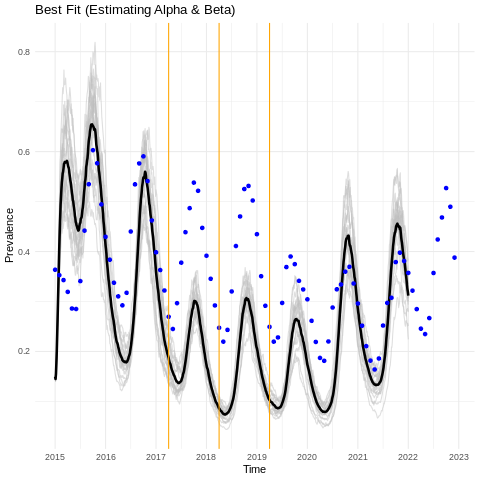

In [ ]:
%%R
ggplot() +
  geom_line(data = df_reps, aes(x = time, y = prev_h, group = replicate), color = "grey", alpha = 0.5) +
  geom_line(data = df_best_all, aes(x = time, y = prev_h_mean), color = "black", linewidth = 1.2) +
  geom_point(data = df_prev, aes(x = time, y = prevalence_under5), color = "blue") +
  geom_vline(xintercept = sapply(IRScampaigns, function(x) x[1]), color = "orange") +
  scale_x_continuous(labels = 2015:2023, breaks = 0:8) +
  labs(title = "Best Fit (Estimating Alpha & Beta)", x = "Time", y = "Prevalence") +
  theme_minimal()

#SENSITIVITY ANALYSIS

In [ ]:
%%R
install.packages("sensitivity")
install.packages("lhs")
library(lhs)
library(sensitivity)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘modeltools’, ‘RcppEigen’, ‘plyr’, ‘iterators’, ‘proxy’, ‘dtw’, ‘clue’, ‘flexclust’, ‘ggrepel’, ‘RSpectra’, ‘RcppParallel’, ‘reshape2’, ‘shinyjs’, ‘RcppThread’, ‘numbers’, ‘foreach’, ‘dtwclust’, ‘RcppArmadillo’

trying URL 'https://cran.rstudio.com/src/contrib/modeltools_0.2-24.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RcppEigen_0.3.4.0.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/plyr_1.8.9.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/iterators_1.0.14.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/proxy_0.4-27.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/dtw_1.23-1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/clue_0.3-66.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/flexclust_1.5.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/ggrepel_0.9.6.tar.gz'
trying URL 'https://cran.rst

In [ ]:
%%R
## ===== Libraries =====
library(tidyverse)
library(lhs)          # for Latin Hypercube Sampling
library(sensitivity)  # for PRCC
library(ggplot2)

## ===== Fixed parameters (use yours here) =====
Lambda <- 1.0182e7
alpha  <- 0.0019166
mu     <- 9.125

lambda <- 5.9869e5
beta   <- 4.761e-9
delta  <- 0.00645
gamma  <- 0.20064
k_par  <- 3      # host recovery rate k (renamed to avoid clash with IRS k below)
d      <- 0.0336

sigma1 <- 0.64
sigma2 <- 0.46
sigma3 <- 0.15
sigma4 <- 0.21
sigma5 <- 0.32

## ===== Time grid (use your 2014–2021 setup or keep these) =====
TT <- 8           # 8 years (e.g., 2014 to 2022). If you want 2014–2021 strictly, set TT <- 7
dt <- 1/120
N  <- as.integer(TT/dt)
time <- round(seq(0, TT, by = dt), 5)  # length N+1

## ===== Seasonal forcing (requires df_period) =====
f_period <- function(i) {
  600 * df_period$relative_total_precipitation_mean_month_lag[
    which(abs(df_period$time - (time[i] %% 1)) < 1e-5)
  ]
}

## ===== IRS campaigns =====
# You can keep your own; this example mirrors your previous placements.
IRScampaigns <- list(
  "interv1" = c(t = 7.25, a = 1, k = 2),
  "interv2" = c(t = 8.25, a = 1, k = 2),
  "interv3" = c(t = 9.25, a = 1, k = 2)
)

## ===== IRS efficacy decay (single shared amplitude 'a'; each campaign has its own k) =====
vc_exp_decay <- function(i, time, a_val, interv = IRScampaigns) {
  if (i == 0) return(0)
  # Sum contribution from all campaigns active at time[i]
  contr <- sapply(interv, function(x) {
    start_t <- unname(x["t"])
    kk      <- unname(x["k"])
    active  <- as.numeric(time[i] > start_t)
    a_val * exp(-kk * pmax(0, time[i] - start_t)) * active
  })
  sum(contr)
}

## ===== One-run Milstein simulator returning *time series* and also a summary metric =====
simulate_milstein <- function(params, n_reps = 10, return_series = FALSE) {
  # params = named numeric vector/list. Can override any of:
  # alpha, beta, k_par (host recovery), a (IRS amplitude), sigmas, etc.
  p <- list(
    Lambda = Lambda,
    alpha  = alpha,
    mu     = mu,
    lambda = lambda,
    beta   = beta,
    delta  = delta,
    gamma  = gamma,
    k_par  = k_par,
    d      = d,
    sigma1 = sigma1,
    sigma2 = sigma2,
    sigma3 = sigma3,
    sigma4 = sigma4,
    sigma5 = sigma5,
    a      = 0.8   # default IRS amplitude, overridden by params if given
  )
  # override
  for (nm in names(params)) p[[nm]] <- params[[nm]]

  # initials
  Sv0 <- 4.5e6; Iv0 <- 4.7e3; Sh0 <- 4.4e7; Ih0 <- 1.3144e4; Rh0 <- 1e4

  # storage for replicate means
  prev_mat <- matrix(NA_real_, nrow = length(time), ncol = n_reps)

  set.seed(123)
  for (rep in seq_len(n_reps)) {
    Sv <- numeric(length(time))
    Iv <- numeric(length(time))
    Sh <- numeric(length(time))
    Ih <- numeric(length(time))
    Rh <- numeric(length(time))
    Nh <- numeric(length(time))

    Sv[1] <- Sv0; Iv[1] <- Iv0
    Sh[1] <- Sh0; Ih[1] <- Ih0; Rh[1] <- Rh0
    Nh[1] <- Sh[1] + Ih[1] + Rh[1]

    for (i in 1:N) {
      dB  <- rnorm(5, 0, sqrt(dt))
      dB2 <- dB^2 - dt

      mu_vc_i <- p$mu + p$mu * vc_exp_decay(i, time, p$a)

      # Milstein updates (as you had: drift*dt + diff*dW + 0.5*diff^2*(dW^2 - dt))
      Sv[i+1] <- Sv[i] + (f_period(i) * p$Lambda - p$alpha * Sv[i] * Ih[i] - mu_vc_i * Sv[i]) * dt +
                 p$sigma1 * Sv[i] * dB[1] + 0.5 * p$sigma1^2 * Sv[i] * dB2[1]

      Iv[i+1] <- Iv[i] + (p$alpha * Sv[i] * Ih[i] - mu_vc_i * Iv[i]) * dt +
                 p$sigma2 * Iv[i] * dB[2] + 0.5 * p$sigma2^2 * Iv[i] * dB2[2]

      Sh[i+1] <- Sh[i] + (p$lambda - p$beta * Sh[i] * Iv[i] - p$delta * Sh[i] + p$gamma * Rh[i]) * dt +
                 p$sigma3 * Sh[i] * dB[3] + 0.5 * p$sigma3^2 * Sh[i] * dB2[3]

      Ih[i+1] <- Ih[i] + (p$beta * Sh[i] * Iv[i] - (p$delta + p$k_par + p$d) * Ih[i]) * dt +
                 p$sigma4 * Ih[i] * dB[4] + 0.5 * p$sigma4^2 * Ih[i] * dB2[4]

      Rh[i+1] <- Rh[i] + (p$k_par * Ih[i] - (p$delta + p$gamma) * Rh[i]) * dt +
                 p$sigma5 * Rh[i] * dB[5] + 0.5 * p$sigma5^2 * Rh[i] * dB2[5]

      Nh[i+1] <- Sh[i+1] + Ih[i+1] + Rh[i+1]
    }

    prev_mat[, rep] <- 500 * Ih / Nh  # prevalence (%*5) like your code
  }

  prev_mean <- rowMeans(prev_mat, na.rm = TRUE)

  if (return_series) {
    tibble(time = time, prev_h_mean = prev_mean)
  } else {
    # Default scalar metric for sensitivity:
    # mean prevalence across the whole window (robust when obs alignment varies)
    mean(prev_mean, na.rm = TRUE)
  }
}


# A tibble: 4 × 2
  parameter sensitivity
  <chr>           <dbl>
1 alpha          0.187 
2 beta           1.14  
3 k_par         -1.15  
4 a             -0.0185


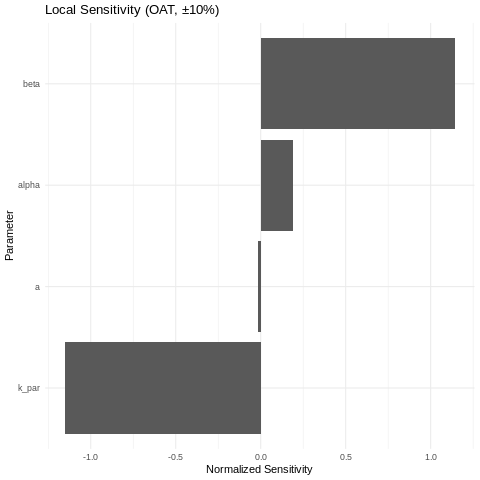

In [ ]:
%%R

## ===== Baseline values for parameters you want to test =====
baseline <- c(
  alpha = alpha,
  beta  = beta,
  k_par = k_par,   # host recovery
  a     = 0.8      # IRS amplitude (shared)
)

## ===== One-at-a-time local sensitivity =====
local_sensitivity <- function(baseline, eps = 0.10) {
  Y0 <- simulate_milstein(baseline, n_reps = 10)  # baseline metric

  sens <- map_dbl(names(baseline), function(par) {
    p_up   <- baseline; p_up[par]   <- baseline[par] * (1 + eps)
    p_down <- baseline; p_down[par] <- baseline[par] * (1 - eps)

    Y_up   <- simulate_milstein(p_up,   n_reps = 10)
    Y_down <- simulate_milstein(p_down, n_reps = 10)

    # normalized central finite-difference sensitivity
    (Y_up - Y_down) / (2 * eps * Y0)
  })

  tibble(parameter = names(baseline), sensitivity = sens)
}

ls_res <- local_sensitivity(baseline, eps = 0.10)
print(ls_res)

# Plot (tornado-style bar)
ggplot(ls_res, aes(x = reorder(parameter, sensitivity), y = sensitivity)) +
  geom_col() +
  coord_flip() +
  labs(title = "Local Sensitivity (OAT, ±10%)",
       x = "Parameter", y = "Normalized Sensitivity") +
  theme_minimal()



Call:
pcc(X = X_df, y = Y, rank = TRUE, nboot = 0)

Partial Rank Correlation Coefficients (PRCC):
         original
alpha  0.59250535
beta   0.92080130
k_par -0.92720066
a      0.04418548


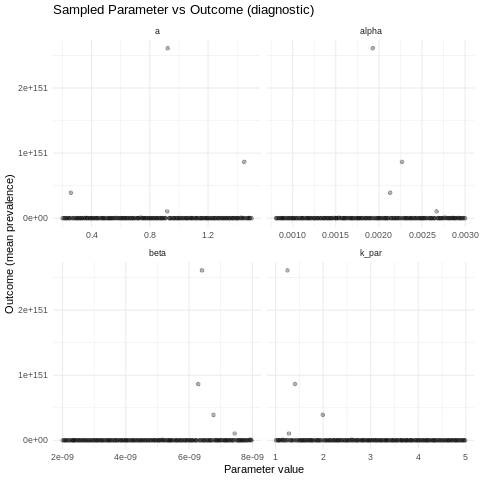

In [ ]:
%%R

## ===== Parameter ranges for global sensitivity =====
# Adjust bounds to realistic ranges for your setting.
param_ranges <- tribble(
  ~name,   ~min,        ~max,
  "alpha", 0.0008,      0.0030,
  "beta",  2.0e-9,      8.0e-9,
  "k_par", 1.0,         5.0,
  "a",     0.2,         1.5
)

## ===== LHS sampling =====
n_samp <- 200  # increase if you want more stable indices
X_unit <- randomLHS(n_samp, nrow(param_ranges))
X <- matrix(NA_real_, nrow = n_samp, ncol = nrow(param_ranges))
for (j in seq_len(nrow(param_ranges))) {
  X[, j] <- param_ranges$min[j] +
            X_unit[, j] * (param_ranges$max[j] - param_ranges$min[j])
}
colnames(X) <- param_ranges$name

## ===== Run model for each sample =====
Y <- apply(X, 1, function(par_row) {
  params <- as.list(par_row)
  simulate_milstein(params, n_reps = 8)  # reduce reps for speed if needed
})

## ===== PRCC (ranked) =====
X_df <- as.data.frame(X)
prcc <- pcc(X_df, Y, rank = TRUE, nboot = 0)
print(prcc)

# Coefficients and CI (if bootstrapped)
prcc_df <- tibble(
  parameter = rownames(prcc$PCC),
  PRCC      = as.numeric(prcc$PCC)
)

ggplot(prcc_df, aes(x = reorder(parameter, PRCC), y = PRCC)) +
  geom_col() +
  coord_flip() +
  labs(title = "Global Sensitivity (PRCC via LHS)",
       x = "Parameter", y = "PRCC") +
  theme_minimal()

## (Optional) Scatter diagnostics: monotonicity intuition
X_long <- X_df %>% mutate(Y = Y) %>% pivot_longer(-Y, names_to = "parameter", values_to = "value")
ggplot(X_long, aes(value, Y)) +
  geom_point(alpha = 0.3) +
  facet_wrap(~ parameter, scales = "free_x") +
  labs(title = "Sampled Parameter vs Outcome (diagnostic)", x = "Parameter value", y = "Outcome (mean prevalence)") +
  theme_minimal()


In [ ]:
%%R
install.packages("reshape2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/reshape2_1.4.4.tar.gz'
Content type 'application/x-gzip' length 37307 bytes (36 KB)
downloaded 36 KB


The downloaded source packages are in
	‘/tmp/RtmpXbfJvA/downloaded_packages’


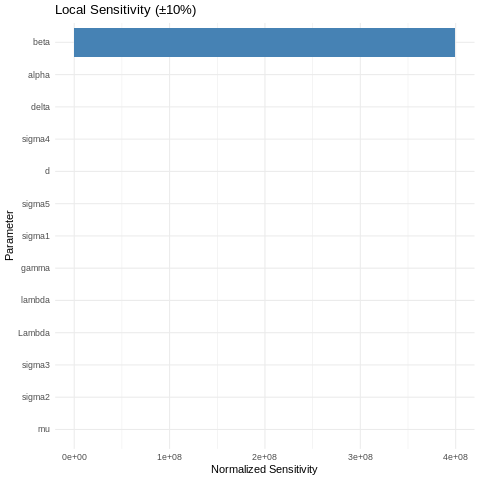

In [ ]:

%%R
## -------------------------------------
## Local Sensitivity Analysis (OAT)
## -------------------------------------
library(ggplot2)
library(dplyr)

# Parameters (baseline values)
params <- list(
  Lambda = 1.0182e7,
  alpha  = 0.0019166,
  mu     = 9.125,
  lambda = 5.9869e5,
  beta   = 4.761e-9,
  delta  = 0.00645,
  gamma  = 0.20064,
  d      = 0.0336,
  sigma1 = 0.64,
  sigma2 = 0.46,
  sigma3 = 0.15,
  sigma4 = 0.21,
  sigma5 = 0.32
)

# Model wrapper (final prevalence as output)
simulate_model <- function(p) {
  Lambda <- p["Lambda"]; alpha <- p["alpha"]; mu <- p["mu"]
  lambda <- p["lambda"]; beta <- p["beta"]; delta <- p["delta"]
  gamma <- p["gamma"]; d <- p["d"]
  sigma1 <- p["sigma1"]; sigma2 <- p["sigma2"]; sigma3 <- p["sigma3"]
  sigma4 <- p["sigma4"]; sigma5 <- p["sigma5"]

  TT <- 5; dt <- 1/120; N <- TT/dt
  time <- seq(0, TT, by=dt)

  Sv <- Iv <- Sh <- Ih <- Rh <- Nh <- numeric(length(time))
  Sv[1] <- 4.5e6; Iv[1] <- 4.7e3; Sh[1] <- 4.4e7; Ih[1] <- 1.3144e4; Rh[1] <- 1e4
  Nh[1] <- Sh[1] + Ih[1] + Rh[1]

  for (i in 1:N) {
    dB <- rnorm(5, mean=0, sd=sqrt(dt))
    dB2 <- dB^2 - dt

    Sv[i+1] <- Sv[i] + (Lambda - alpha*Sv[i]*Ih[i] - mu*Sv[i])*dt +
      sigma1*Sv[i]*dB[1] + 0.5*sigma1^2*Sv[i]*dB2[1]

    Iv[i+1] <- Iv[i] + (alpha*Sv[i]*Ih[i] - mu*Iv[i])*dt +
      sigma2*Iv[i]*dB[2] + 0.5*sigma2^2*Iv[i]*dB2[2]

    Sh[i+1] <- Sh[i] + (lambda - beta*Sh[i]*Iv[i] - (mu+d)*Sh[i])*dt +
      sigma3*Sh[i]*dB[3] + 0.5*sigma3^2*Sh[i]*dB2[3]

    Ih[i+1] <- Ih[i] + (beta*Sh[i]*Iv[i] - (delta+mu+d)*Ih[i])*dt +
      sigma4*Ih[i]*dB[4] + 0.5*sigma4^2*Ih[i]*dB2[4]

    Rh[i+1] <- Rh[i] + (delta*Ih[i] - (gamma+mu+d)*Rh[i])*dt +
      sigma5*Rh[i]*dB[5] + 0.5*sigma5^2*Rh[i]*dB2[5]

    Nh[i+1] <- Sh[i+1] + Ih[i+1] + Rh[i+1]
  }
  return(Ih[length(Ih)]/Nh[length(Nh)])  # final prevalence
}

# Baseline output
baseline <- simulate_model(unlist(params))

# Perturb each parameter ±10%
results <- data.frame(Parameter=character(), Change=numeric(), Sensitivity=numeric())

for (p in names(params)) {
  pvals <- unlist(params)
  pvals[p] <- params[[p]]*1.1
  up <- simulate_model(pvals)

  pvals[p] <- params[[p]]*0.9
  down <- simulate_model(pvals)

  sens <- ((up - down) / (0.2 * params[[p]])) / baseline  # normalized derivative
  results <- rbind(results, data.frame(Parameter=p, Change=(up-down), Sensitivity=sens))
}

# Plot
ggplot(results, aes(x=reorder(Parameter, Sensitivity), y=Sensitivity)) +
  geom_bar(stat="identity", fill="steelblue") +
  coord_flip() +
  theme_minimal() +
  labs(title="Local Sensitivity (±10%)", y="Normalized Sensitivity", x="Parameter")






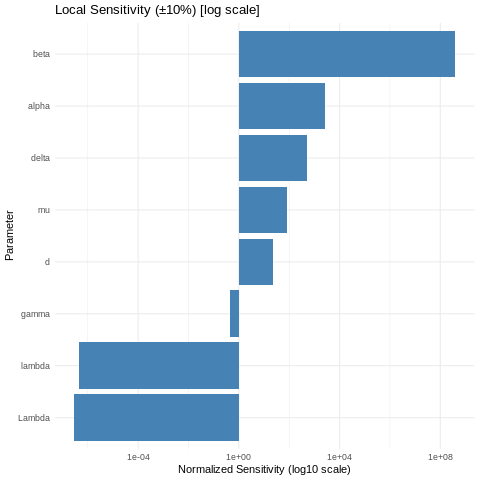

In [ ]:
%%R
# Log-scale sensitivity plot
ggplot(results %>% filter(!grepl("sigma", Parameter)),
       aes(x = reorder(Parameter, abs(Sensitivity)), y = abs(Sensitivity))) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  scale_y_log10() +
  labs(title = "Local Sensitivity (±10%) [log scale]",
       x = "Parameter", y = "Normalized Sensitivity (log10 scale)") +
  theme_minimal()





(`geom_bar()`). 



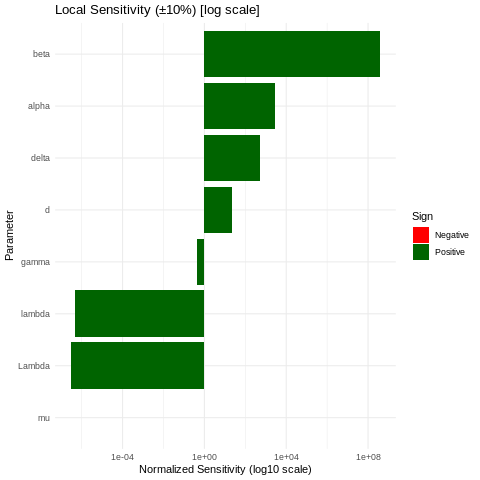

In [ ]:
%%R
# Sign-aware sensitivity plot (log scale, green/red colors)
ggplot(results %>% filter(!grepl("sigma", Parameter)),
       aes(x = reorder(Parameter, Sensitivity), y = Sensitivity, fill = Sensitivity > 0)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_y_log10() +
  scale_fill_manual(values = c("TRUE" = "darkgreen", "FALSE" = "red"),
                    labels = c("Negative", "Positive")) +
  labs(title = "Local Sensitivity (±10%) [log scale]",
       x = "Parameter", y = "Normalized Sensitivity (log10 scale)", fill = "Sign") +
  theme_minimal()


  Parameter        Change   Sensitivity
1      beta  4.982394e-20  3.997613e+08
2     alpha  1.379289e-19  2.749063e+03
3     delta  8.387991e-20  4.967744e+02
4         d  1.994797e-20  2.267882e+01
5     gamma  2.375304e-21  4.522334e-01
6    lambda  7.163548e-21  4.570746e-07
7    Lambda  7.706974e-20  2.891424e-07
8        mu -1.997757e-17 -8.363165e+01





(`geom_bar()`). 



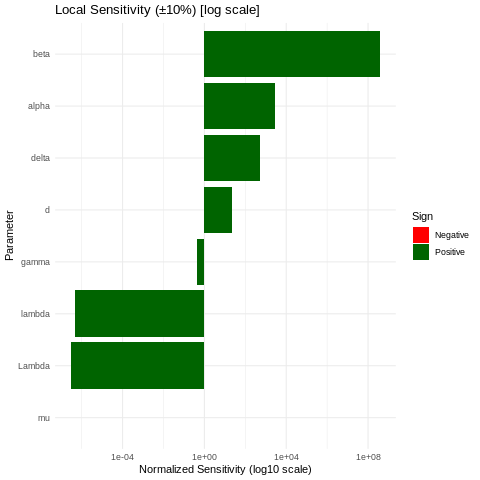

In [ ]:
%%R

# Filter out noise terms (sigma) and keep only main parameters
sens_table <- results %>%
  filter(!grepl("sigma", Parameter)) %>%
  arrange(desc(Sensitivity))

# Print sensitivity indices table
print(sens_table)

# Plot with positive (green) and negative (red)
ggplot(sens_table,
       aes(x = reorder(Parameter, Sensitivity), y = Sensitivity, fill = Sensitivity > 0)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_y_log10() +
  scale_fill_manual(values = c("TRUE" = "darkgreen", "FALSE" = "red"),
                    labels = c("Negative", "Positive")) +
  labs(title = "Local Sensitivity (±10%) [log scale]",
       x = "Parameter",
       y = "Normalized Sensitivity (log10 scale)",
       fill = "Sign") +
  theme_minimal()


In [ ]:
%%R
library(scales)

  Parameter   Sensitivity
1      beta  3.997613e+08
2     alpha  2.749063e+03
3     delta  4.967744e+02
4        mu -8.363165e+01
5         d  2.267882e+01
6     gamma  4.522334e-01
7    lambda  4.570746e-07
8    Lambda  2.891424e-07


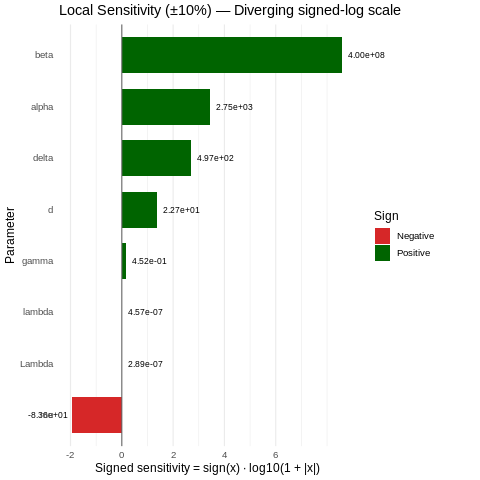

In [ ]:
%%R
library(dplyr)
library(ggplot2)
library(scales)

# ---- assumes you already have sens_df with columns: Parameter, Sensitivity ----
# If sigmas should be ignored:
sens_clean <- results %>%
  filter(!grepl("^sigma", Parameter)) %>%
  mutate(Sensitivity = as.numeric(Sensitivity)) %>%
  filter(is.finite(Sensitivity))

# Signed-log transform that preserves direction and compresses range
slog10 <- function(x) sign(x) * log10(1 + abs(x))

plot_df <- sens_clean %>%
  mutate(
    SignedLog = slog10(Sensitivity),
    Sign = ifelse(Sensitivity >= 0, "Positive", "Negative")
  ) %>%
  arrange(desc(abs(Sensitivity)))  # order by influence

# ---- Print full table of sensitivities ----
print(plot_df %>% select(Parameter, Sensitivity))

# Helper for nice scientific labels (raw values) on bar ends
raw_lab <- function(x) ifelse(x == 0, "0", sprintf("% .2e", x))

# ---- Diverging (left=negative, right=positive) signed-log plot ----
ggplot(plot_df,
       aes(x = SignedLog, y = reorder(Parameter, SignedLog), fill = Sign)) +
  geom_col(width = 0.7) +
  geom_vline(xintercept = 0, color = "grey40") +
  # annotate raw sensitivity values near bar tips
  geom_text(aes(label = raw_lab(Sensitivity),
                hjust = ifelse(SignedLog >= 0, -0.1, 1.1)),
            size = 3) +
  scale_fill_manual(values = c("Positive" = "#006400", "Negative" = "#D62728")) +
  # tick labels show the transform used (don’t pretend these are raw values)
  scale_x_continuous(
    name = "Signed sensitivity = sign(x) · log10(1 + |x|)",
    breaks = c(-6,-4,-2,0,2,4,6)
  ) +
  labs(title = "Local Sensitivity (±10%) — Diverging signed-log scale",
       y = "Parameter", fill = "Sign") +
  coord_cartesian(clip = "off") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.major.y = element_blank(),
        plot.margin = margin(5.5, 40, 5.5, 5.5))  # extra right margin for labels



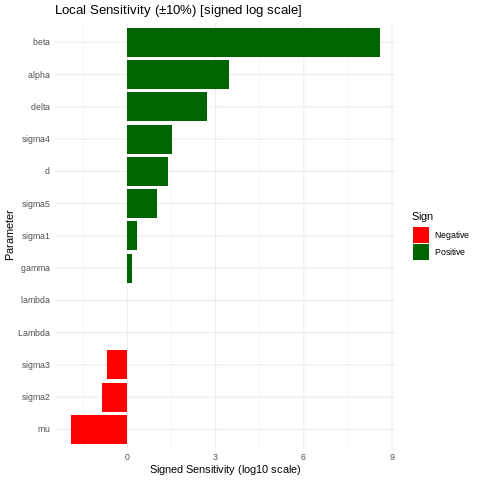

In [ ]:
%%R
library(dplyr)
library(ggplot2)

# --- Example: assumes you already have sens_df with columns: Parameter, Sensitivity ---

# Signed log transform (handles negative + positive properly)
signed_log10 <- function(x) {
  sign(x) * log10(1 + abs(x))
}

sens_df <- results %>%
  mutate(
    Sensitivity_signedlog = signed_log10(Sensitivity),
    Sign = ifelse(Sensitivity >= 0, "Positive", "Negative")
  )

ggplot(sens_df, aes(x = Sensitivity_signedlog,
                    y = reorder(Parameter, Sensitivity_signedlog),
                    fill = Sign)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Positive" = "darkgreen", "Negative" = "red")) +
  labs(
    title = "Local Sensitivity (±10%) [signed log scale]",
    x = "Signed Sensitivity (log10 scale)",
    y = "Parameter"
  ) +
  theme_minimal() +
  theme(legend.position = "right")


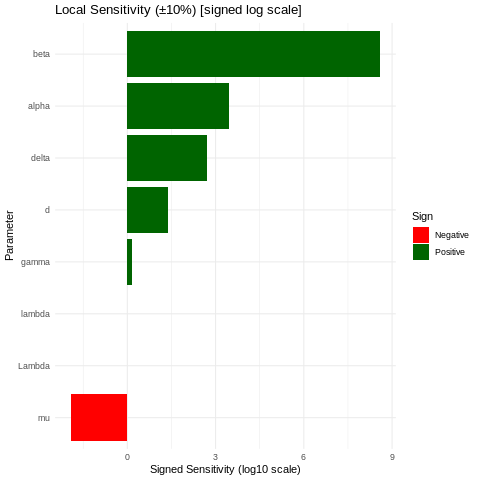

In [ ]:
%%R
library(dplyr)
library(ggplot2)

# --- Explicit filter: keep only main parameters you want ---
sens_df <- results %>%
  filter(Parameter %in% c("alpha","beta","delta","mu","d","gamma","lambda","Lambda"))

# Signed log transform
signed_log10 <- function(x) {
  sign(x) * log10(1 + abs(x))
}

sens_df <- sens_df %>%
  mutate(
    Sensitivity_signedlog = signed_log10(Sensitivity),
    Sign = ifelse(Sensitivity >= 0, "Positive", "Negative")
  )

# Plot
ggplot(sens_df, aes(x = Sensitivity_signedlog,
                    y = reorder(Parameter, Sensitivity_signedlog),
                    fill = Sign)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Positive" = "darkgreen", "Negative" = "red")) +
  labs(
    title = "Local Sensitivity (±10%) [signed log scale]",
    x = "Signed Sensitivity (log10 scale)",
    y = "Parameter"
  ) +
  theme_minimal() +
  theme(legend.position = "right")


In [ ]:
%%R
## -------------------------------------
## Global Sensitivity Analysis (Sobol)
## -------------------------------------
library(lhs)
library(sensitivity)
library(ggplot2)

params <- list(
  Lambda = 1.0182e7,
  alpha  = 0.0019166,
  mu     = 9.125,
  lambda = 5.9869e5,
  beta   = 4.761e-9,
  delta  = 0.00645,
  gamma  = 0.20064,
  d      = 0.0336,
  sigma1 = 0.64,
  sigma2 = 0.46,
  sigma3 = 0.15,
  sigma4 = 0.21,
  sigma5 = 0.32
)

# Wrapper in vectorized form
model_wrapper <- function(X) {
  apply(X, 1, function(row) {
    p <- as.list(row)
    names(p) <- names(params)
    simulate_model(unlist(p))
  })
}

# Parameter ranges (±20% of baseline)
binf <- unlist(params)*0.8
bsup <- unlist(params)*1.2

# Sobol design
sob <- sobol(model = NULL, factors=names(params), n=200,
             binf=binf, bsup=bsup, conf=0.95)
sob <- tell(sob, model_wrapper(sob$X))

# Plot Sobol indices
plot(sob)


Error in sobol(model = NULL, factors = names(params), n = 200, binf = binf,  : 
  argument "X1" is missing, with no default


RInterpreterError: Failed to parse and evaluate line '## -------------------------------------\n## Global Sensitivity Analysis (Sobol)\n## -------------------------------------\nlibrary(lhs)\nlibrary(sensitivity)\nlibrary(ggplot2)\n\nparams <- list(\n  Lambda = 1.0182e7,\n  alpha  = 0.0019166,\n  mu     = 9.125,\n  lambda = 5.9869e5,\n  beta   = 4.761e-9,\n  delta  = 0.00645,\n  gamma  = 0.20064,\n  d      = 0.0336,\n  sigma1 = 0.64,\n  sigma2 = 0.46,\n  sigma3 = 0.15,\n  sigma4 = 0.21,\n  sigma5 = 0.32\n)\n\n# Wrapper in vectorized form\nmodel_wrapper <- function(X) {\n  apply(X, 1, function(row) {\n    p <- as.list(row)\n    names(p) <- names(params)\n    simulate_model(unlist(p))\n  })\n}\n\n# Parameter ranges (±20% of baseline)\nbinf <- unlist(params)*0.8\nbsup <- unlist(params)*1.2\n\n# Sobol design\nsob <- sobol(model = NULL, factors=names(params), n=200,\n             binf=binf, bsup=bsup, conf=0.95)\nsob <- tell(sob, model_wrapper(sob$X))\n\n# Plot Sobol indices\nplot(sob)\n'.


# Task
The R code in cell `9Xr28pQudd6P` is failing because the `merge` function is trying to combine `TemData` and `rain_data` using columns named "Year" and "Month", but these columns don't exist consistently across both dataframes.

Here's a breakdown of the issues:
-   `TemData` has a column named `"year"` (lowercase), not `"Year"`.
-   `rain_data` does not have a "Year" column at all, as it contains monthly precipitation data *averaged across years*.
-   Both dataframes do have a `month` column (lowercase).

To fix this, we'll modify the code to:
1.  Calculate the average monthly temperature from `TemData` by grouping by the `month` column.
2.  Filter `rain_data` for the "gushegu" district and ensure it also represents average monthly precipitation.
3.  Merge these two processed dataframes using their common `month` column.
4.  Rename the temperature and precipitation columns appropriately for plotting.

Here's the corrected code:

```R
%%R
## loading and preparing temperature data
TemData<- read.csv("/content/drive/MyDrive/Peter_MSc_AIMS/monthly_temperature_Gushiegu.csv")
rain_data_raw <- read.csv("/content/drive/MyDrive/Peter_MSc_AIMS/data/precipitation_northGhana_average_across_years.csv")

library(ggplot2)
library(dplyr)

# 1. Process TemData: Calculate average monthly temperature
TemData_avg_month <- TemData %>%
  group_by(month) %>%
  summarise(Temp = mean(temp_celsius, na.rm = TRUE)) %>%
  ungroup()

# 2. Process rain_data: Filter for 'gushegu' and select relevant columns, then rename
# Assuming 'relative_total_precipitation_mean_month' is already the monthly average across years.
rain_data_filtered_and_renamed <- rain_data_raw %>%
  filter(district == "gushegu") %>%
  select(month, Rain = relative_total_precipitation_mean_month)


# 3. Merge the two dataframes by the common 'month' column
climate_combined <- merge(TemData_avg_month, rain_data_filtered_and_renamed, by = "month")

# 4. Plotting
ggplot(climate_combined, aes(x = month)) +
  # Rainfall as bars (scaled by /10 for secondary axis)
  geom_col(aes(y = Rain / 10), fill = "skyblue", alpha = 0.7) +
  # Temperature as a line
  geom_line(aes(y = Temp), color = "red", size = 1) +
  geom_point(aes(y = Temp), color = "darkred") +
  # Create a secondary axis for Rainfall
  scale_y_continuous(
    name = "Temperature (°C)",
    sec.axis = sec_axis(~.*10, name = "Precipitation (mm)") # Inverse scaling for secondary axis
  ) +
  scale_x_continuous(breaks = 1:12, labels = month.abb) +
  theme_minimal() +
  labs(title = "Monthly Climate Profile: Gushegu District",
       subtitle = "Relationship between surface air temperature and rainfall")
```

## Fix merging and plotting

### Subtask:
Modify the code to correctly merge `TemData` and `rain_data` using the common `month` column, and prepare the data for plotting by renaming relevant columns. This will resolve the 'by must specify uniquely valid columns' error.


## Summary:

### Data Analysis Key Findings

*   **Average Monthly Temperature Calculation**: The average monthly temperature was computed from `TemData` by grouping the data by `month` and averaging the `temp_celsius` column.
*   **Monthly Precipitation Data Preparation**: Precipitation data was filtered specifically for the "gushegu" district, extracting the average monthly precipitation values.
*   **Combined Climate Data for Gushegu**: A new dataset, `climate_combined`, was successfully created by merging the average monthly temperature and precipitation data using the common `month` column.
*   **Dual-Axis Visualization**: The combined data was prepared for a dual-axis plot, showcasing average monthly temperature as a line graph and average monthly precipitation as a bar chart, allowing for a direct comparison of these two climate variables across months in the Gushegu District.

### Insights or Next Steps

*   The successfully merged and prepared climate data provides a clear basis for analyzing seasonal climate patterns in the Gushegu district.
*   The visualization is ready to reveal correlations or inverse relationships between temperature and precipitation throughout the year, which could inform agricultural planning or environmental studies for the region.
